# LTE Downlink Throughput — Notebook 02
## Statistical Anomaly Detection, Expected-Throughput P75, Scoring, and RCA-Handoff Tables

This notebook starts from the clean pre-anomaly feature table created by Notebook 01. It does **not** rebuild the raw cleaning stage and it does **not** train ML models yet.

Input:

```text
Throughput_Anomaly_Detection_Outputs/01_preprocessing_cleaning/lte_dl_feature_table_clean_pre_anomaly.parquet
```

Outputs remain under the same folder structure used by the original notebook.

# Output folders produced

All outputs are written under:

```text
Throughput_Anomaly_Detection_Outputs/
```

The notebook separates the files into three folders:

| Folder | Purpose |
|---|---|
| `01_preprocessing_cleaning/` | Raw profile, cleaning reports, canonical mapping, cleaned base table, event/activity tables, and LTE-DL modeling table. |
| `02_anomaly_detection/` | Expected-throughput references, anomaly flags, anomaly handoff table, anomaly summaries, score QC tables, and schema files. |
| `03_plots/` | All visual EDA and anomaly-QC plots. |

Main anomaly-detection outputs:

| File | Purpose |
|---|---|
| `lte_dl_modeling_table.parquet` | LTE-DL rows with canonical KPI aliases, analysis context, expected-throughput values, and statistical anomaly scores. |
| `expected_throughput_group_radio_p75.csv` | Radio-condition P75 expected-throughput reference. |
| `expected_throughput_group_rb_conditioned_p75.csv` | RB-conditioned P75 expected-throughput reference. |
| `lte_throughput_anomalies_baseline.csv` | Only rows flagged as throughput anomalies. This is the main handoff file for RCA. |
| `throughput_anomaly_episode_summary.csv` | Consecutive anomaly samples grouped into anomaly episodes. |
| `anomaly_method_summary.csv` | Flag percentages with clear denominator columns. |
| `anomaly_flag_overlap_summary.csv` | Independent trigger-family overlap and score behavior. |
| `anomaly_score_distribution_qc.csv` | Score-distribution checkpoints to detect over-compression or over-severity. |

No final RCA cause is assigned in this notebook. RCA fields are placeholders/evidence fields for the next pipeline module.


This version keeps the same folder split, but the anomaly percentages are now calculated over all valid LTE-DL rows, not only active download activity rows.

# Latest threshold calibration update

This version uses calibrated real-drive-test LTE thresholds:

- Low throughput fixed threshold remains **10 Mbps**. In the current exported LTE-DL modeling table this flags about **17.2%** of samples, so it behaves as a practical lower-tail screening threshold, not an extreme-failure threshold.
- RSRP bins are now **Poor < -120 dBm**, **Fair [-120, -100)**, **Good [-100, -90)**, and **Excellent >= -90 dBm**.
- RSRQ bins are **Poor < -20 dB**, **Fair [-20, -15)**, **Good [-15, -10)**, and **Excellent >= -10 dB**.
- SINR bins are **Poor < 0 dB**, **Fair [0, 10)**, **Good [10, 15)**, and **Excellent >= 15 dB**.

The poor-radio flags now use the Poor-bin boundary, while Fair radio remains contextual evidence rather than an automatic poor-radio trigger.


In [1]:
# =========================
# 1. Imports and settings
# =========================

from pathlib import Path
import os
import re
import json
import math
import warnings
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 260)

# Use plain matplotlib only.
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# -------------------------
# Project paths
# -------------------------
DATA_DIR = Path("Raw_Data")
DRIVE_TEST_PATH = DATA_DIR / "Network_Drive_Test.pkl"
OUTPUT_ROOT = Path("Throughput_Anomaly_Detection_Outputs")
PREPROCESSING_DIR = OUTPUT_ROOT / "01_preprocessing_cleaning"
ANOMALY_DIR = OUTPUT_ROOT / "02_anomaly_detection"
PLOTS_DIR = OUTPUT_ROOT / "03_plots"
# OUTPUT_DIR remains as the root for backward compatibility inside helper functions.
OUTPUT_DIR = OUTPUT_ROOT
for _dir in [OUTPUT_ROOT, PREPROCESSING_DIR, ANOMALY_DIR, PLOTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Cleaning configuration
# -------------------------
MISSING_THRESHOLD_PCT = 70.0
DROP_FULLY_MISSING_PROTECTED_COLUMNS = True
RANDOM_SEED = 42
PROFILE_SAMPLE_ROWS = 100_000
EARTH_RADIUS_KM = 6371.0088

# -------------------------
# Throughput configuration
# -------------------------
# Most common drive-test exports store the selected LTE throughput KPI in Mbps.
# If your exported target is Kbps, set THROUGHPUT_TO_MBPS = 1 / 1000.
THROUGHPUT_TO_MBPS = 1.0

LOW_TP_FIXED_MBPS = 10.0
MIN_EXPECTED_TP_MBPS_FOR_UNDERPERFORMANCE = 25.0
UNDERPERFORMANCE_RATIO_THRESHOLD = 0.35
UNDERPERFORMANCE_GAP_MBPS = 15.0

# Robust lower-tail z-score setting.
# A classic modified-z threshold of -3.5 can become too strict after log1p() compression
# and may produce 0 rows. -3.0 keeps this as an extreme lower-tail detector.
ROBUST_Z_LOWER_THRESHOLD = -3.0

# Group P75 expected-throughput settings.
MIN_GROUP_SIZE_FOR_P75 = 30
P75_QUANTILE = 0.75

# Rolling/sudden-drop settings.
ROLLING_WINDOW_SAMPLES = 11
ROLLING_DROP_RATIO_THRESHOLD = 0.50
SUDDEN_DROP_PREV_MIN_MBPS = 10.0
SUDDEN_DROP_RATIO_THRESHOLD = 0.50
SUDDEN_DROP_GAP_MBPS = 5.0

# Sustained-window and bad-session settings.
# Sudden-drop detection looks for contrast versus a healthy local baseline.
# The following thresholds catch the different case where the whole local window/session is bad.
MIN_ROLLING_SAMPLES = 5
VERY_LOW_TP_MBPS = 5.0
ROLLING_BAD_WINDOW_MEDIAN_MBPS = LOW_TP_FIXED_MBPS
ROLLING_BAD_WINDOW_P25_MBPS = VERY_LOW_TP_MBPS

SESSION_MIN_ROWS_FOR_BAD_SESSION = 20
BAD_SESSION_MEDIAN_MBPS = LOW_TP_FIXED_MBPS
BAD_SESSION_P25_MBPS = VERY_LOW_TP_MBPS
BAD_SESSION_LOW_TP_RATIO_THRESHOLD = 0.40
SESSION_P10_MAX_THRESHOLD_MBPS = 20.0

# -------------------------
# Download activity-window settings
# -------------------------
# LTE-DL session rows can include script/activity context such as HTTP/HTTPS download windows.
# Earlier versions used active download windows as the main analysis mask. The latest V1 uses
# all valid LTE-DL rows because the observed throughput distributions across active/warmup/outside
# activity windows were very close. Activity windows are now kept as context only.
APPLY_DOWNLOAD_ACTIVITY_WINDOW_FILTER = True
DOWNLOAD_ACTIVITY_NAME_PATTERN = r"HTTP|HTTPS|Download"
DOWNLOAD_ACTIVITY_WARMUP_SECONDS = 5
DOWNLOAD_ACTIVITY_COOLDOWN_SECONDS = 2

# Visual context settings.
MAX_TOP_CONTEXT_WINDOWS = 8
MAX_CONTEXT_WINDOWS_BY_TYPE = 8
ANOMALY_CONTEXT_SAMPLES_BEFORE = 60
ANOMALY_CONTEXT_SAMPLES_AFTER = 60


# -------------------------
# LTE radio-quality bin thresholds
# -------------------------
# These thresholds are intentionally calibrated for this real drive-test export.
# They are slightly more forgiving than some textbook/paper thresholds because field
# measurements, mobility, server/application behavior, and route conditions can make
# practical throughput lower than ideal lab expectations.
#
# RSRP bins:
#   Excellent: >= -90 dBm
#   Good:      [-100, -90) dBm
#   Fair:      [-120, -100) dBm
#   Poor:      < -120 dBm
RSRP_EXCELLENT_MIN_DBM = -90.0
RSRP_GOOD_MIN_DBM = -100.0
RSRP_FAIR_MIN_DBM = -120.0

# RSRQ bins:
#   Excellent: >= -10 dB
#   Good:      [-15, -10) dB
#   Fair:      [-20, -15) dB
#   Poor:      < -20 dB
RSRQ_EXCELLENT_MIN_DB = -10.0
RSRQ_GOOD_MIN_DB = -15.0
RSRQ_FAIR_MIN_DB = -20.0

# SINR bins:
#   Excellent: >= 15 dB
#   Good:      [10, 15) dB
#   Fair:      [0, 10) dB
#   Poor:      < 0 dB
SINR_EXCELLENT_MIN_DB = 15.0
SINR_GOOD_MIN_DB = 10.0
SINR_FAIR_MIN_DB = 0.0


# -------------------------
# Final visual-QC and false-positive-control settings
# -------------------------
# Visualization clipping only affects plots, never the data used by anomaly detection.
ROUTE_MAP_COLOR_CLIP_Q = 0.95
HISTOGRAM_COLOR_CLIP_Q = 0.99

# RB reliability checks. RB fields are only used as strong evidence when coverage and
# cardinality show that the export contains enough valid RB data.
MIN_RELIABLE_RB_NON_NULL_PCT = 70.0
MIN_RELIABLE_RB_UNIQUE_VALUES = 10
LOW_RB_QUANTILE = 0.25
MEDIUM_RB_QUANTILE = 0.50
HIGH_RB_QUANTILE = 0.75

# Demand/RB evidence controls.
# If RB data is reliable, strict expected-throughput and CA-underperformance flags
# require medium-or-high RB usage. Otherwise low observed throughput can be caused by
# low offered traffic or a scheduler/resource-allocation state, so it should be lower
# confidence instead of a strong capacity anomaly.
REQUIRE_RB_DEMAND_FOR_STRICT_P75 = True
REQUIRE_RB_DEMAND_FOR_CA_UNDERPERFORMANCE = True

# Score calibration after removing aggressive flag stacking.
# These floors prevent visually obvious severe samples from receiving unrealistically low
# scores, while caps prevent low-RB/low-demand rows from looking like confirmed capacity failures.
MIN_SCORE_ANY_TRIGGER = 15.0
MIN_SCORE_FIXED_LOW_TP = 25.0
MIN_SCORE_SUSTAINED_LOW_WINDOW = 35.0
MIN_SCORE_RADIO_LIMITED = 35.0
MIN_SCORE_LOCAL_DROP = 50.0
MIN_SCORE_P75_UNDERPERF = 55.0
MIN_SCORE_SEVERE_P75_UNDERPERF = 75.0
LOW_RB_DEMAND_SCORE_CAP = 45.0

# Score saturation control. Scores are softly capped below 100 unless a truly catastrophic
# case is present. This prevents too many rows from saturating at 100.
SCORE_SOFT_CAP_NON_CATASTROPHIC = 95.0
CATASTROPHIC_ACTUAL_TP_MBPS = 1.0
CATASTROPHIC_EXPECTED_TP_MBPS = 50.0

# RB-efficiency anomaly settings. Throughput per RB becomes useful after RB availability
# was proven reliable. It checks whether throughput is inefficient even when resources exist.
RB_EFFICIENCY_REFERENCE_QUANTILE = 0.10
RB_EFFICIENCY_MIN_ACTUAL_TP_FOR_CONTEXT_MBPS = 0.0


# Continuous score calibration. The final score is no longer just a sum of flags or only
# a set of floors. It combines: strongest-trigger base, continuous anomaly magnitude,
# independent trigger-family bonus, and capped evidence/context bonus.
MULTI_TRIGGER_BONUS_PER_LOG_STEP = 5.0
MULTI_TRIGGER_BONUS_CAP = 12.0
EVIDENCE_BONUS_CAP = 10.0
MAGNITUDE_GAP_DENOMINATOR_MBPS = 80.0
MAGNITUDE_DROP_DENOMINATOR_MBPS = 40.0
MAGNITUDE_LOW_TP_REFERENCE_MBPS = 20.0

# RB-conditioned P75 expected-throughput controls.
USE_RB_CONDITIONED_P75 = True
RB_P75_LABEL = "rb_conditioned"

# P75 reliability controls. Specific group references are more trustworthy than global fallback.
MAX_RELIABLE_P75_FALLBACK_LEVEL = 4
MIN_RELIABLE_P75_GROUP_N = MIN_GROUP_SIZE_FOR_P75

# Bootstrap confidence interval settings for group P75 references.
# These CIs are used as an additional confidence guard for strict P75 underperformance.
P75_CI_BOOTSTRAP_N = 80
P75_CI_ALPHA = 0.05

# Tighter CA-underperformance controls.
CA_UNDERPERF_MIN_EXPECTED_MBPS = 30.0
CA_UNDERPERF_MAX_ACTUAL_MBPS = 15.0
CA_UNDERPERF_RATIO_THRESHOLD = 0.35

# Episode grouping converts consecutive row-level anomalies into reviewable periods.
MAX_SECONDS_GAP_SAME_ANOMALY_EPISODE = 3.0

# Event-window settings used only to prepare anomaly evidence, not final RCA.
# Measurement reports are separated from actual HO execution/failure so mobility context does
# not become too broad. Legacy aliases are created later for compatibility.
EVENT_WINDOWS_SECONDS = {
    "any_event": 30,
    "measurement_report_event": 5,
    "handover_execution": 5,
    "handover_failure": 10,
    "rach_attempt": 10,
    "rach_failure": 10,
    "ca_activation_change": 10,
    "failure_other": 10,
}

# Candidate-vs-handoff split. The candidate table keeps broad statistical findings;
# the baseline handoff table is a stricter subset for practical RCA review.
RCA_HANDOFF_MIN_SCORE = 35.0

print("Notebook configured.")
print("Raw drive-test path:", DRIVE_TEST_PATH)
print("Output root:", OUTPUT_ROOT.resolve())
print("Preprocessing/cleaning folder:", PREPROCESSING_DIR.resolve())
print("Anomaly-detection folder:", ANOMALY_DIR.resolve())
print("Plots folder:", PLOTS_DIR.resolve())
print("Missing threshold:", MISSING_THRESHOLD_PCT, "%")

PRE_ANOMALY_FEATURE_TABLE_PATH = PREPROCESSING_DIR / "lte_dl_feature_table_clean_pre_anomaly.parquet"
PRE_ANOMALY_FEATURE_TABLE_FALLBACK_CSV = PREPROCESSING_DIR / "lte_dl_feature_table_clean_pre_anomaly.csv.gz"


Notebook configured.
Raw drive-test path: Raw_Data\Network_Drive_Test.pkl
Output root: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs
Preprocessing/cleaning folder: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning
Anomaly-detection folder: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs\02_anomaly_detection
Plots folder: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs\03_plots
Missing threshold: 70.0 %


In [2]:
# =========================
# 2. General utility functions
# =========================

def human_bytes(num_bytes: float) -> str:
    """Convert bytes to a readable memory-size string."""
    if pd.isna(num_bytes):
        return "N/A"
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num_bytes)
    for unit in units:
        if size < 1024:
            return f"{size:,.2f} {unit}"
        size /= 1024
    return f"{size:,.2f} PB"



def infer_output_dir(filename: str, category: Optional[str] = None) -> Path:
    """
    Route output artifacts into the requested folder.

    category can be:
    - "preprocessing" / "cleaning"
    - "anomaly"
    - "plots"

    When category is omitted, the filename is classified using stable prefixes.
    """
    if category is not None:
        cat = str(category).lower()
        if cat in {"preprocessing", "cleaning", "preprocess", "clean"}:
            return PREPROCESSING_DIR
        if cat in {"anomaly", "anomalies", "detection"}:
            return ANOMALY_DIR
        if cat in {"plot", "plots", "figure", "figures"}:
            return PLOTS_DIR

    name = str(filename).lower()
    preprocessing_prefixes = (
        "raw_", "column_family_", "missing_", "kept_", "removed_",
        "cleaning_", "cleaned_", "drive_clean_", "activity_", "events_",
        "event_", "canonical_", "detected_", "lte_dl_modeling_table",
        "download_activity_", "throughput_by_download_context", "throughput_by_ca_condition",
        "throughput_by_rb_demand", "rb_usage_quality", "threshold_calibration",
    )
    if name.startswith(preprocessing_prefixes):
        return PREPROCESSING_DIR
    return ANOMALY_DIR


def save_table(df: pd.DataFrame, filename: str, index: bool = False, category: Optional[str] = None) -> Path:
    """Save a table as UTF-8 CSV inside the correct output subfolder."""
    folder = infer_output_dir(filename, category=category)
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / filename
    df.to_csv(path, index=index, encoding="utf-8-sig")
    print(f"Saved CSV: {path}  shape={df.shape}")
    return path


def save_parquet_or_csv(df: pd.DataFrame, filename_no_ext: str, index: bool = False, category: Optional[str] = None) -> Path:
    """
    Save a DataFrame as Parquet when pyarrow/fastparquet is available.
    If Parquet support is missing, save a compressed CSV fallback.
    """
    folder = infer_output_dir(filename_no_ext, category=category)
    folder.mkdir(parents=True, exist_ok=True)
    parquet_path = folder / f"{filename_no_ext}.parquet"
    csv_path = folder / f"{filename_no_ext}.csv.gz"
    try:
        df.to_parquet(parquet_path, index=index)
        print(f"Saved Parquet: {parquet_path}  shape={df.shape}")
        return parquet_path
    except Exception as exc:
        print("Parquet export failed. Falling back to compressed CSV.")
        print("Reason:", exc)
        df.to_csv(csv_path, index=index, compression="gzip", encoding="utf-8-sig")
        print(f"Saved compressed CSV: {csv_path}  shape={df.shape}")
        return csv_path


def sample_df(df: pd.DataFrame, n: int = 100_000, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Return a safe sample. If df is smaller than n, return a copy of the full df."""
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=seed).copy()


def safe_value_counts(s: pd.Series, top_n: int = 10) -> Dict[str, int]:
    """Return top value counts as a dict without failing on mixed dtypes."""
    non_null = s.dropna()
    if non_null.empty:
        return {}
    return non_null.astype(str).value_counts().head(top_n).to_dict()


def get_column_family(col: str) -> str:
    """Infer a practical telecom family from a column name."""
    text = str(col)
    if " - " in text:
        return text.split(" - ")[0].strip()
    if "." in text:
        return text.split(".")[0].strip()
    return text.split()[0].strip() if text.split() else "Unknown"


def first_existing(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    """Return the first existing column from a candidate list."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


def to_numeric_series(df: pd.DataFrame, col: Optional[str]) -> pd.Series:
    """Return a numeric Series for col; returns all-NaN if col is missing."""
    if col is None or col not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype="float64")
    return pd.to_numeric(df[col], errors="coerce")


def overview(df: pd.DataFrame, name: str) -> None:
    """Display a compact overview of a dataframe."""
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("Rows:", f"{len(df):,}")
    print("Columns:", f"{df.shape[1]:,}")
    print("Memory:", human_bytes(df.memory_usage(deep=True).sum()))
    display(pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(3),
    }).head(250))

In [3]:
# =========================
# 2B. Visualization helper functions
# =========================


def save_current_plot(filename: str) -> None:
    """Save the current matplotlib figure into the notebook plot-output folder."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved plot: {path}")


def clip_for_plot(s: pd.Series, lower: Optional[float] = None, upper_q: Optional[float] = 0.995) -> pd.Series:
    """Return a numeric series clipped only for visualization, never for modeling."""
    out = pd.to_numeric(s, errors="coerce")
    if lower is not None:
        out = out.clip(lower=lower)
    if upper_q is not None and out.notna().any():
        upper = out.quantile(upper_q)
        out = out.clip(upper=upper)
    return out


def plot_distribution_with_lines(
    df: pd.DataFrame,
    col: str,
    title: str,
    xlabel: str,
    thresholds: Optional[Dict[str, float]] = None,
    bins: int = 80,
    filename: Optional[str] = None,
    clip_upper_q: Optional[float] = 0.995,
) -> None:
    """Plot a histogram with optional vertical reference thresholds."""
    if col not in df.columns:
        print(f"Skipped {title}: column not found: {col}")
        return
    s = clip_for_plot(df[col], lower=0 if "throughput" in col.lower() or "score" in col.lower() else None, upper_q=clip_upper_q).dropna()
    if s.empty:
        print(f"Skipped {title}: no numeric values in {col}")
        return
    plt.figure(figsize=(12, 5))
    plt.hist(s, bins=bins)
    if thresholds:
        for label, value in thresholds.items():
            if pd.notna(value):
                plt.axvline(float(value), linestyle="--", label=f"{label}: {float(value):.2f}")
        plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Rows")
    if filename:
        save_current_plot(filename)
    plt.show()


def plot_box_by_category(
    df: pd.DataFrame,
    category_col: str,
    value_col: str,
    title: str,
    ylabel: str,
    filename: Optional[str] = None,
    category_order: Optional[List[Any]] = None,
    clip_upper_q: Optional[float] = 0.995,
) -> None:
    """Plot a boxplot for a numeric value split by a categorical column."""
    if category_col not in df.columns or value_col not in df.columns:
        print(f"Skipped {title}: missing {category_col} or {value_col}")
        return
    tmp = df[[category_col, value_col]].copy()
    tmp[value_col] = clip_for_plot(tmp[value_col], lower=0, upper_q=clip_upper_q)
    tmp = tmp.dropna(subset=[category_col, value_col])
    if tmp.empty:
        print(f"Skipped {title}: no data after dropping missing values")
        return
    if category_order is None:
        category_order = list(tmp[category_col].astype(str).value_counts().index)
    data = [tmp.loc[tmp[category_col].astype(str) == str(cat), value_col].values for cat in category_order]
    labels = [str(cat) for cat, arr in zip(category_order, data) if len(arr) > 0]
    data = [arr for arr in data if len(arr) > 0]
    if not data:
        print(f"Skipped {title}: no non-empty groups")
        return
    plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel(category_col)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    if filename:
        save_current_plot(filename)
    plt.show()


def plot_scatter_sample(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
    filename: Optional[str] = None,
    max_points: int = 20_000,
    y_clip_upper_q: Optional[float] = 0.995,
) -> None:
    """Scatter plot on a random sample to keep the notebook responsive."""
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Skipped {title}: missing {x_col} or {y_col}")
        return
    tmp = df[[x_col, y_col]].copy()
    tmp[y_col] = clip_for_plot(tmp[y_col], lower=0, upper_q=y_clip_upper_q)
    tmp = tmp.dropna()
    if tmp.empty:
        print(f"Skipped {title}: no data")
        return
    tmp = sample_df(tmp, max_points)
    plt.figure(figsize=(10, 5))
    plt.scatter(tmp[x_col], tmp[y_col], s=6, alpha=0.35)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if filename:
        save_current_plot(filename)
    plt.show()



def plot_route_metric(
    df: pd.DataFrame,
    metric_col: str,
    title: str,
    filename: Optional[str] = None,
    max_points: int = 30_000,
    clip_upper_q: Optional[float] = ROUTE_MAP_COLOR_CLIP_Q,
    colorbar_label: Optional[str] = None,
) -> None:
    """Route scatter colored by a metric, with optional display-only clipping.

    The metric values are never changed in the dataframe. Clipping is applied only to the
    plotted color values so that extreme throughput outliers do not make the whole route
    appear dark. This is especially useful for drive-test throughput maps where the most
    important visual detail is often in the 0-80 Mbps range, while a few samples exceed
    200 Mbps.
    """
    required = {"latitude", "longitude", metric_col}
    if not required.issubset(df.columns):
        print(f"Skipped {title}: missing one of {required}")
        return
    tmp = df.dropna(subset=["latitude", "longitude", metric_col]).copy()
    if tmp.empty:
        print(f"Skipped {title}: no valid GPS/metric rows")
        return
    tmp = sample_df(tmp, max_points)

    color_values = pd.to_numeric(tmp[metric_col], errors="coerce")
    cb_label = colorbar_label or metric_col
    if clip_upper_q is not None and color_values.notna().any():
        upper = color_values.quantile(clip_upper_q)
        color_values = color_values.clip(upper=upper)
        cb_label = f"{cb_label} (display clipped at P{int(clip_upper_q * 100)}={upper:.2f})"

    plt.figure(figsize=(8, 8))
    sc = plt.scatter(tmp["longitude"], tmp["latitude"], c=color_values, s=7, alpha=0.75)
    plt.colorbar(sc, label=cb_label)
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    if filename:
        save_current_plot(filename)
    plt.show()


def plot_route_anomaly_overlay(
    df: pd.DataFrame,
    filename: Optional[str] = None,
    max_points: int = 40_000,
) -> None:
    """Show the full route as background and overlay anomaly samples.

    This makes spatial anomaly interpretation easier than coloring every point with the
    raw score. The background route shows coverage of the drive path, while overlaid samples
    show where the detector found problematic LTE-DL behavior.
    """
    required = {"latitude", "longitude", "is_throughput_anomaly"}
    if not required.issubset(df.columns):
        print(f"Skipped anomaly overlay map: missing one of {required}")
        return
    tmp = df.dropna(subset=["latitude", "longitude"]).copy()
    if tmp.empty:
        print("Skipped anomaly overlay map: no valid GPS rows")
        return
    tmp = sample_df(tmp, max_points)
    normal = tmp[~tmp["is_throughput_anomaly"].fillna(False).astype(bool)]
    anom = tmp[tmp["is_throughput_anomaly"].fillna(False).astype(bool)]

    plt.figure(figsize=(8, 8))
    if not normal.empty:
        plt.scatter(normal["longitude"], normal["latitude"], s=5, alpha=0.20, label="Not flagged")
    if not anom.empty:
        score = pd.to_numeric(anom.get("anomaly_score_0_100", pd.Series(1, index=anom.index)), errors="coerce").fillna(1)
        plt.scatter(anom["longitude"], anom["latitude"], c=score, s=10, alpha=0.85, label="Flagged anomaly")
        plt.colorbar(label="Anomaly score (0-100)")
    plt.title("Route with Throughput Anomaly Overlay")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    if filename:
        save_current_plot(filename)
    plt.show()


def plot_flag_percentage_bars(summary_df: pd.DataFrame, filename: Optional[str] = None) -> None:
    """Plot anomaly method/case percentages from anomaly_method_summary.csv."""
    if summary_df is None or summary_df.empty or "method_or_case" not in summary_df.columns:
        print("Skipped method-percentage plot: summary table is empty")
        return
    tmp = summary_df.sort_values("flagged_pct", ascending=True)
    plt.figure(figsize=(12, max(5, 0.35 * len(tmp))))
    plt.barh(tmp["method_or_case"], tmp["flagged_pct"])
    plt.xlabel("Flagged rows (%)")
    plt.title("Anomaly Method / Case Flagging Rate")
    if filename:
        save_current_plot(filename)
    plt.show()


def plot_actual_vs_expected(df: pd.DataFrame, filename: Optional[str] = None, max_points: int = 25_000) -> None:
    """Actual-vs-expected scatter with anomaly samples highlighted."""
    needed = {"actual_lte_dl_throughput", "expected_tp_p75", "is_throughput_anomaly"}
    if not needed.issubset(df.columns):
        print(f"Skipped actual-vs-expected plot: missing {needed - set(df.columns)}")
        return
    tmp = df.dropna(subset=["actual_lte_dl_throughput", "expected_tp_p75"]).copy()
    if tmp.empty:
        print("Skipped actual-vs-expected plot: no valid rows")
        return
    tmp = sample_df(tmp, max_points)
    normal = tmp[~tmp["is_throughput_anomaly"].fillna(False).astype(bool)]
    anom = tmp[tmp["is_throughput_anomaly"].fillna(False).astype(bool)]
    plt.figure(figsize=(8, 8))
    if not normal.empty:
        plt.scatter(normal["expected_tp_p75"], normal["actual_lte_dl_throughput"], s=5, alpha=0.25, label="Not flagged")
    if not anom.empty:
        plt.scatter(anom["expected_tp_p75"], anom["actual_lte_dl_throughput"], s=7, alpha=0.55, label="Flagged anomaly")
    max_axis = np.nanpercentile(tmp[["expected_tp_p75", "actual_lte_dl_throughput"]].values, 99)
    plt.plot([0, max_axis], [0, max_axis], linestyle="--", label="Actual = expected")
    plt.xlabel("Expected throughput P75 (Mbps)")
    plt.ylabel("Actual LTE DL throughput (Mbps)")
    plt.title("Actual vs Group-P75 Expected Throughput")
    plt.legend()
    if filename:
        save_current_plot(filename)
    plt.show()



def plot_anomaly_context(
    df: pd.DataFrame,
    anomaly_df: Optional[pd.DataFrame] = None,
    rank: int = 0,
    samples_before: int = 40,
    samples_after: int = 40,
    filename_prefix: Optional[str] = None,
    title_prefix: str = "Top anomaly context window",
) -> None:
    """Plot surrounding session samples around a selected anomaly.

    The rolling/anomaly context is sample-based because the current drive-test export is
    mostly consecutive. To make the sample axis easier to interpret, the x-axis tick labels
    also show the real elapsed seconds from the selected anomaly when timestamps exist.

    The selected anomaly itself is shown with a vertical dashed line. The plot helps answer:
    - Is this an isolated drop?
    - Is it part of a sustained bad window?
    - Is expected P75 consistently above actual, or only locally?
    - Did radio KPIs degrade around the same time?
    """
    if anomaly_df is None:
        if "is_throughput_anomaly" not in df.columns:
            print("Skipped anomaly context: no anomaly flag available")
            return
        anomaly_df = df[df["is_throughput_anomaly"].fillna(False).astype(bool)].copy()

    if anomaly_df.empty:
        print("Skipped anomaly context: no anomalies available")
        return

    if "anomaly_score_0_100" in anomaly_df.columns:
        anomaly_df = anomaly_df.sort_values("anomaly_score_0_100", ascending=False)

    if rank >= len(anomaly_df):
        print(f"Skipped anomaly context: rank {rank} out of range")
        return

    row = anomaly_df.iloc[rank]
    sid = row.get("id", None)

    if "id" in df.columns and pd.notna(sid):
        session = df[df["id"] == sid].copy()
    else:
        session = df.copy()

    if "timestamp" in session.columns:
        session = session.sort_values("timestamp")

    # Find the center row using source_index when available, otherwise nearest timestamp.
    center_pos = None
    if "source_index" in row.index and "source_index" in session.columns:
        matches = np.where(session["source_index"].values == row["source_index"])[0]
        if len(matches):
            center_pos = int(matches[0])

    if center_pos is None and "timestamp" in row.index and "timestamp" in session.columns:
        session_ts_utc = pd.to_datetime(session["timestamp"], utc=True, errors="coerce")
        row_ts_utc = pd.to_datetime(row["timestamp"], utc=True, errors="coerce")
        diffs = (session_ts_utc - row_ts_utc).abs()
        center_pos = int(diffs.argmin()) if len(diffs) else None

    if center_pos is None:
        print("Skipped anomaly context: could not locate selected anomaly in session")
        return

    start = max(0, center_pos - samples_before)
    end = min(len(session), center_pos + samples_after + 1)
    ctx = session.iloc[start:end].copy().reset_index(drop=True)
    ctx["context_sample_number"] = np.arange(len(ctx))
    center_x = center_pos - start

    selected_timestamp_text = ""
    if "timestamp" in ctx.columns:
        ts = pd.to_datetime(ctx["timestamp"], utc=True, errors="coerce")
        center_ts = ts.iloc[center_x]
        ctx["seconds_from_selected_anomaly"] = (ts - center_ts).dt.total_seconds()
        if pd.notna(center_ts):
            selected_timestamp_text = f" | selected time: {center_ts}"

    def _apply_time_ticks() -> None:
        """Use tick labels that show both sample index and seconds from selected anomaly."""
        if "seconds_from_selected_anomaly" not in ctx.columns:
            plt.xlabel("Sample number inside context window")
            return
        max_ticks = min(11, len(ctx))
        ticks = np.linspace(0, len(ctx) - 1, max_ticks).round().astype(int)
        ticks = np.unique(np.r_[ticks, center_x])
        tick_labels = []
        for t in ticks:
            sec = ctx.loc[int(t), "seconds_from_selected_anomaly"]
            if pd.notna(sec):
                tick_labels.append(f"{int(t)}\n{sec:+.0f}s")
            else:
                tick_labels.append(str(int(t)))
        plt.xticks(ticks, tick_labels)
        plt.xlabel("Context sample number\n(second line = seconds from selected anomaly)")

    # Print a compact textual summary before the plots.
    summary_cols = [
        "timestamp", "id", "anomaly_type", "anomaly_type_flags", "anomaly_score_0_100",
        "actual_lte_dl_throughput", "expected_tp_p75", "expected_tp_rb_conditioned_p75", "throughput_ratio_p75", "throughput_ratio_rb_p75",
        "rb_usage_value", "rb_usage_bucket", "rb_demand_confidence", "throughput_per_rb",
        "lte_rsrp", "lte_rsrq", "lte_sinr", "carrier_count",
        "download_context_label", "download_analysis_window_flag",
    ]
    available_summary_cols = [c for c in summary_cols if c in row.index]
    if available_summary_cols:
        print("Selected anomaly summary:")
        display(pd.DataFrame([row[available_summary_cols].to_dict()]))

    plt.figure(figsize=(14, 5))
    plt.plot(ctx["context_sample_number"], ctx["actual_lte_dl_throughput"], marker="o", markersize=3, label="Actual TP")
    if "expected_tp_p75" in ctx.columns:
        plt.plot(ctx["context_sample_number"], ctx["expected_tp_p75"], linestyle="--", label="Radio P75")
    if "expected_tp_rb_conditioned_p75" in ctx.columns:
        plt.plot(ctx["context_sample_number"], ctx["expected_tp_rb_conditioned_p75"], linestyle="-.", label="RB-conditioned P75")
    if "rolling_median_tp" in ctx.columns:
        plt.plot(ctx["context_sample_number"], ctx["rolling_median_tp"], linestyle=":", label="Rolling median")
    if "download_analysis_window_flag" in ctx.columns:
        # Lightly mark samples that are outside the parsed active download window.
        # This is context only; it is not the main anomaly-analysis mask in the latest version.
        inactive = ~ctx["download_analysis_window_flag"].fillna(True).astype(bool)
        if inactive.any():
            y_marker = max(0, np.nanmin(ctx["actual_lte_dl_throughput"]) if ctx["actual_lte_dl_throughput"].notna().any() else 0)
            plt.scatter(ctx.loc[inactive, "context_sample_number"], np.repeat(y_marker, inactive.sum()), marker="x", s=25, label="Outside parsed active download window")
    plt.axvline(center_x, linestyle="--", label="Selected anomaly")
    plt.title(f"{title_prefix} #{rank + 1}: throughput behavior{selected_timestamp_text}")
    _apply_time_ticks()
    plt.ylabel("Throughput (Mbps)")
    plt.legend()
    if filename_prefix:
        save_current_plot(f"{filename_prefix}_rank_{rank + 1}_throughput_context.png")
    plt.show()

    # Separate radio-context plot so throughput and radio scales are not mixed.
    radio_cols = [c for c in ["lte_rsrp", "lte_rsrq", "lte_sinr"] if c in ctx.columns]
    if radio_cols:
        plt.figure(figsize=(14, 5))
        for col in radio_cols:
            plt.plot(ctx["context_sample_number"], ctx[col], marker="o", markersize=3, label=col)
        plt.axvline(center_x, linestyle="--", label="Selected anomaly")
        plt.title(f"{title_prefix} #{rank + 1}: radio evidence{selected_timestamp_text}")
        _apply_time_ticks()
        plt.ylabel("Radio KPI value")
        plt.legend()
        if filename_prefix:
            save_current_plot(f"{filename_prefix}_rank_{rank + 1}_radio_context.png")
        plt.show()


def plot_context_examples_by_type(
    df: pd.DataFrame,
    anomaly_df: pd.DataFrame,
    max_types: int = 8,
    samples_before: int = 60,
    samples_after: int = 60,
    filename_prefix: str = "19_type_example_context",
) -> None:
    """Plot one high-score context example for several anomaly types.

    Top-score-only examples often show extreme edge cases. This helper adds diversity by
    selecting one representative high-score sample from each major anomaly type.
    """
    if anomaly_df is None or anomaly_df.empty or "anomaly_type" not in anomaly_df.columns:
        print("Skipped type examples: anomaly table is empty or missing anomaly_type")
        return

    types = anomaly_df["anomaly_type"].value_counts().head(max_types).index.tolist()
    for i, anomaly_type in enumerate(types, start=1):
        subset = anomaly_df[anomaly_df["anomaly_type"] == anomaly_type].copy()
        if subset.empty:
            continue
        subset = subset.sort_values("anomaly_score_0_100", ascending=False).head(1)
        print(f"\nRepresentative anomaly type example: {anomaly_type}")
        plot_anomaly_context(
            df,
            anomaly_df=subset,
            rank=0,
            samples_before=samples_before,
            samples_after=samples_after,
            filename_prefix=f"{filename_prefix}_{i}_{str(anomaly_type).replace('/', '_').replace(' ', '_')}",
            title_prefix=f"Representative {anomaly_type}",
        )


# Load clean pre-anomaly table

Notebook 02 intentionally loads the clean feature table produced by Notebook 01. This prevents accidental ML/statistical leakage from post-scoring columns.

In [4]:
# =========================
# Load Notebook 01 output
# =========================

def load_pre_anomaly_feature_table() -> pd.DataFrame:
    if PRE_ANOMALY_FEATURE_TABLE_PATH.exists():
        print("Loading clean pre-anomaly parquet:", PRE_ANOMALY_FEATURE_TABLE_PATH)
        try:
            return pd.read_parquet(PRE_ANOMALY_FEATURE_TABLE_PATH)
        except Exception as exc:
            print("Parquet read failed; trying compressed CSV fallback if available.")
            print("Reason:", exc)
    if PRE_ANOMALY_FEATURE_TABLE_FALLBACK_CSV.exists():
        print("Loading clean pre-anomaly compressed CSV:", PRE_ANOMALY_FEATURE_TABLE_FALLBACK_CSV)
        return pd.read_csv(PRE_ANOMALY_FEATURE_TABLE_FALLBACK_CSV)
    raise FileNotFoundError(
        "Clean pre-anomaly feature table was not found. Run Notebook 01 first, or place "
        f"the file at {PRE_ANOMALY_FEATURE_TABLE_PATH}."
    )

lte_dl = load_pre_anomaly_feature_table()
print("Loaded clean pre-anomaly LTE-DL table shape:", lte_dl.shape)

# Guard against accidental leakage from an old post-scoring table.
leakage_prefixes = (
    "expected_tp", "throughput_gap_p75", "throughput_ratio_p75", "log_residual_p75",
    "score_", "anomaly_score", "anomaly_type", "anomaly_severity", "is_throughput_anomaly",
    "underperform_", "low_tp_", "rolling_", "prev_tp", "tp_drop_", "tp_ratio_to_prev",
    "bad_session",
)
leakage_cols_at_load = [c for c in lte_dl.columns if any(str(c).startswith(p) for p in leakage_prefixes)]
if leakage_cols_at_load:
    print("Warning: post-anomaly columns found in loaded table and will be overwritten/recomputed as needed:")
    print(leakage_cols_at_load[:50])

preview_cols = [c for c in ["source_index", "id", "timestamp", "actual_lte_dl_throughput", "lte_rsrp", "lte_sinr", "rb_usage_bucket", "carrier_count", "download_context_label"] if c in lte_dl.columns]
display(lte_dl[preview_cols].head(20))

Loading clean pre-anomaly parquet: Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\lte_dl_feature_table_clean_pre_anomaly.parquet
Loaded clean pre-anomaly LTE-DL table shape: (32238, 337)


,source_index,id,timestamp,actual_lte_dl_throughput,lte_rsrp,lte_sinr,rb_usage_bucket,carrier_count,download_context_label
0,32048,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:40+02:00,0.000144,-101.905240,10.830000,low_rb_usage,1.0,outside_download_activity
1,32049,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:41+02:00,0.002336,-105.852940,7.888544,low_rb_usage,1.0,outside_download_activity
2,32050,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:42+02:00,0.031944,-104.577126,8.440907,low_rb_usage,1.0,outside_download_activity
3,32051,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:43+02:00,0.043088,-100.460590,9.509525,low_rb_usage,1.0,outside_download_activity
4,32052,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:44+02:00,0.001464,-107.604164,5.791666,low_rb_usage,1.0,outside_download_activity
5,32053,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:45+02:00,0.008488,-110.119080,4.092308,low_rb_usage,2.0,outside_download_activity
6,32054,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:46+02:00,0.018432,-111.684784,1.961682,low_rb_usage,2.0,outside_download_activity
7,32055,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:47+02:00,0.008776,-111.661766,2.067532,low_rb_usage,1.0,outside_download_activity
8,32056,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:48+02:00,0.008024,-111.179110,2.957142,low_rb_usage,1.0,outside_download_activity
9,32057,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,2025-08-26 23:37:49+02:00,0.019640,-110.680310,3.066666,low_rb_usage,1.0,outside_download_activity


# Statistical anomaly methods

V1 uses multiple statistical views instead of one generic anomaly label:

1. **Fixed threshold:** simple low-throughput rule.
2. **Global percentile:** bottom tail of LTE-DL throughput.
3. **Session percentile:** low compared with the same drive-test session.
4. **Robust log z-score:** robust outlier score using median and MAD on log throughput.
5. **Log-IQR lower-tail score:** another robust lower-tail score.
6. **Rolling median drop:** low compared with local session context.
7. **Sudden drop:** large drop compared with previous sample.
8. **Group P75 expected throughput:** actual throughput much lower than a realistic achievable P75 under similar radio/CA/band conditions.

These methods are intentionally explainable and do not require machine learning.

In [5]:
# =========================
# 12. Simple and robust statistical anomaly scores
# =========================


def minmax_clip_score(value: pd.Series, denominator: float) -> pd.Series:
    """Convert a positive gap into a clipped 0..1 score."""
    if denominator is None or denominator == 0 or pd.isna(denominator):
        return pd.Series(0.0, index=value.index)
    return (value / denominator).clip(lower=0, upper=1)


def robust_mad_zscore(x: pd.Series) -> pd.Series:
    """Robust modified z-score using median absolute deviation.

    The median and MAD are calculated from the non-null values. This allows us to pass a
    series where non-eligible values may be set to NaN.
    """
    x = pd.to_numeric(x, errors="coerce")
    med = x.median(skipna=True)
    mad = (x - med).abs().median(skipna=True)
    if pd.isna(mad) or mad == 0:
        std = x.std(skipna=True)
        if pd.isna(std) or std == 0:
            return pd.Series(0.0, index=x.index)
        return (x - med) / std
    return 0.6745 * (x - med) / mad


def rolling_stat_by_session(df: pd.DataFrame, target: str, window: int, stat: str) -> pd.Series:
    """Return a centered sample-based rolling statistic calculated inside each session.

    The rolling window is intentionally sample-based in this notebook because the current
    drive-test output is consecutive enough for 11 samples to behave like roughly 11 seconds.
    The context plots still show real timestamp deltas so reviewers can verify this visually.

    Non-eligible values can be stored as NaN in the target column. Pandas rolling
    statistics ignore NaN values but still require enough valid samples through min_periods.
    """
    min_periods = max(MIN_ROLLING_SAMPLES, window // 3)

    def _apply(s: pd.Series) -> pd.Series:
        roll = s.rolling(window=window, min_periods=min_periods, center=True)
        if stat == "median":
            return roll.median()
        if stat == "p25":
            return roll.quantile(0.25)
        if stat == "count":
            return roll.count()
        raise ValueError(f"Unsupported rolling stat: {stat}")

    if "id" in df.columns:
        return df.groupby("id", group_keys=False)[target].apply(_apply).reindex(df.index)
    return _apply(df[target])


tp = lte_dl["actual_lte_dl_throughput"].astype(float)
lte_dl["log_actual_lte_dl_throughput"] = np.log1p(tp)

# Main analysis population: all valid LTE-DL rows.
# The download activity window remains in the table as context only. This change is based on
# the observed fact that active/warmup/outside activity rows had very similar throughput medians.
analysis_mask = tp.notna() & (tp >= 0)

# Safety fallback: if something unexpected removes all rows, analyze the LTE-DL table as-is.
if not analysis_mask.any():
    print("Warning: anomaly analysis mask is empty. Falling back to all LTE-DL rows.")
    analysis_mask = pd.Series(True, index=lte_dl.index)

lte_dl["anomaly_analysis_window_flag"] = analysis_mask
analysis_n = int(analysis_mask.sum())
all_n = len(lte_dl)
print(f"Anomaly analysis rows: {analysis_n:,} / {all_n:,} LTE-DL rows ({analysis_n / max(all_n, 1) * 100:.2f}%).")
print("Download activity context is retained only as metadata; RB usage is the main demand/resource-confidence signal.")

tp_active = tp.where(analysis_mask)
log_tp_active = np.log1p(tp_active)

# 1) Fixed threshold.
lte_dl["low_tp_fixed_flag"] = analysis_mask & (tp < LOW_TP_FIXED_MBPS)
lte_dl["score_fixed_low_tp"] = ((LOW_TP_FIXED_MBPS - tp) / LOW_TP_FIXED_MBPS).clip(lower=0, upper=1)
lte_dl["score_fixed_low_tp"] = lte_dl["score_fixed_low_tp"].where(lte_dl["low_tp_fixed_flag"], 0.0)

fixed_threshold_pct_analysis = float(lte_dl["low_tp_fixed_flag"].sum() / max(analysis_n, 1) * 100)
fixed_threshold_pct_all = float(lte_dl["low_tp_fixed_flag"].sum() / max(all_n, 1) * 100)
print(
    f"LOW_TP_FIXED_MBPS={LOW_TP_FIXED_MBPS:g} Mbps flags "
    f"{fixed_threshold_pct_analysis:.2f}% of analyzed LTE-DL rows "
    f"({fixed_threshold_pct_all:.2f}% of all LTE-DL rows)."
)

# 2) Global percentile lower-tail threshold calculated on analyzable rows only.
global_p10 = tp_active.quantile(0.10)
global_p25 = tp_active.quantile(0.25)
lte_dl["global_p10_tp_threshold"] = global_p10
lte_dl["global_p25_tp_threshold"] = global_p25
lte_dl["low_tp_global_p10_flag"] = analysis_mask & (tp <= global_p10)
lte_dl["score_global_p10_low_tp"] = ((global_p10 - tp) / max(global_p10, 1e-9)).clip(lower=0, upper=1)
lte_dl["score_global_p10_low_tp"] = lte_dl["score_global_p10_low_tp"].where(lte_dl["low_tp_global_p10_flag"], 0.0)

# 3) Session percentile threshold based only on valid LTE-DL samples.
if "id" in lte_dl.columns:
    tmp_session = lte_dl[["id"]].copy()
    tmp_session["_tp_active"] = tp_active

    session_group = tmp_session.groupby("id")["_tp_active"]
    session_q10 = session_group.transform(lambda x: x.dropna().quantile(0.10) if x.notna().any() else np.nan)
    session_q25 = session_group.transform(lambda x: x.dropna().quantile(0.25) if x.notna().any() else np.nan)
    session_rows = session_group.transform("count")
    session_mean = session_group.transform("mean")
    session_median = session_group.transform("median")
    session_low_tp_ratio = session_group.transform(
        lambda x: float((x.dropna() < LOW_TP_FIXED_MBPS).mean()) if x.notna().any() else np.nan
    )
else:
    session_q10 = pd.Series(global_p10, index=lte_dl.index)
    session_q25 = pd.Series(global_p25, index=lte_dl.index)
    session_rows = pd.Series(analysis_n, index=lte_dl.index)
    session_mean = pd.Series(tp_active.mean(), index=lte_dl.index)
    session_median = pd.Series(tp_active.median(), index=lte_dl.index)
    session_low_tp_ratio = pd.Series(float((tp_active.dropna() < LOW_TP_FIXED_MBPS).mean()), index=lte_dl.index)

# Fill sessions without valid LTE-DL samples from global LTE-DL values so outputs remain numeric.
session_q10 = session_q10.fillna(global_p10)
session_q25 = session_q25.fillna(global_p25)
session_mean = session_mean.fillna(tp_active.mean())
session_median = session_median.fillna(tp_active.median())
session_low_tp_ratio = session_low_tp_ratio.fillna(float((tp_active.dropna() < LOW_TP_FIXED_MBPS).mean()))

lte_dl["session_rows"] = session_rows.fillna(0).astype(int)
lte_dl["session_mean_tp"] = session_mean
lte_dl["session_median_tp"] = session_median
lte_dl["session_p10_tp_threshold"] = session_q10
lte_dl["session_p25_tp"] = session_q25
lte_dl["session_low_tp_ratio"] = session_low_tp_ratio

lte_dl["low_tp_session_p10_flag"] = (
    analysis_mask &
    (tp <= session_q10) &
    (session_q10 <= SESSION_P10_MAX_THRESHOLD_MBPS)
)
lte_dl["score_session_p10_low_tp"] = ((session_q10 - tp) / session_q10.replace(0, np.nan)).clip(lower=0, upper=1).fillna(0)
lte_dl["score_session_p10_low_tp"] = lte_dl["score_session_p10_low_tp"].where(lte_dl["low_tp_session_p10_flag"], 0.0)

# 4) Robust log z-score lower-tail method.
lte_dl["log_tp_modified_z"] = robust_mad_zscore(log_tp_active)
lte_dl["low_tp_robust_z_flag"] = analysis_mask & (lte_dl["log_tp_modified_z"] <= ROBUST_Z_LOWER_THRESHOLD)
lte_dl["score_robust_z_low_tp"] = (lte_dl["log_tp_modified_z"] / ROBUST_Z_LOWER_THRESHOLD).clip(lower=0, upper=1)
lte_dl["score_robust_z_low_tp"] = lte_dl["score_robust_z_low_tp"].where(lte_dl["low_tp_robust_z_flag"], 0.0).fillna(0.0)
print(
    f"Robust log modified-z min={lte_dl['log_tp_modified_z'].min(skipna=True):.3f}; "
    f"threshold={ROBUST_Z_LOWER_THRESHOLD:.1f}; "
    f"flagged={int(lte_dl['low_tp_robust_z_flag'].sum())} rows."
)

# 5) IQR lower-tail on log throughput using valid LTE-DL samples.
q1 = log_tp_active.quantile(0.25)
q3 = log_tp_active.quantile(0.75)
iqr = q3 - q1
log_iqr_lower_fence = q1 - 1.5 * iqr
lte_dl["log_iqr_lower_fence"] = log_iqr_lower_fence
lte_dl["low_tp_iqr_flag"] = analysis_mask & (np.log1p(tp) < log_iqr_lower_fence)
lte_dl["score_iqr_low_tp"] = ((log_iqr_lower_fence - np.log1p(tp)) / max(abs(log_iqr_lower_fence), 1e-9)).clip(lower=0, upper=1)
lte_dl["score_iqr_low_tp"] = lte_dl["score_iqr_low_tp"].where(lte_dl["low_tp_iqr_flag"], 0.0)

# 6) Rolling context inside each session.
# All valid LTE-DL rows are used as valid rolling values. The rolling window remains sample-based,
# while the context plots show real timestamp deltas to verify the sample spacing.
lte_dl["_tp_for_active_rolling"] = tp.where(analysis_mask)
lte_dl["rolling_median_tp"] = rolling_stat_by_session(lte_dl, "_tp_for_active_rolling", ROLLING_WINDOW_SAMPLES, "median")
lte_dl["rolling_p25_tp"] = rolling_stat_by_session(lte_dl, "_tp_for_active_rolling", ROLLING_WINDOW_SAMPLES, "p25")
lte_dl["rolling_count"] = rolling_stat_by_session(lte_dl, "_tp_for_active_rolling", ROLLING_WINDOW_SAMPLES, "count")

lte_dl["rolling_tp_gap"] = lte_dl["rolling_median_tp"] - tp
lte_dl["rolling_tp_ratio"] = tp / lte_dl["rolling_median_tp"].replace(0, np.nan)

# Contrast anomaly: current sample suddenly falls from a locally healthy baseline.
lte_dl["rolling_drop_flag"] = (
    analysis_mask &
    (lte_dl["rolling_count"] >= MIN_ROLLING_SAMPLES) &
    (lte_dl["rolling_median_tp"] >= LOW_TP_FIXED_MBPS) &
    (lte_dl["rolling_tp_ratio"] <= ROLLING_DROP_RATIO_THRESHOLD) &
    (lte_dl["rolling_tp_gap"] >= SUDDEN_DROP_GAP_MBPS)
)
lte_dl["score_rolling_drop"] = (1 - lte_dl["rolling_tp_ratio"]).clip(lower=0, upper=1).fillna(0)
lte_dl["score_rolling_drop"] = lte_dl["score_rolling_drop"].where(lte_dl["rolling_drop_flag"], 0.0)

# Sustained-window context: the whole local LTE-DL window is poor, not just one sample.
lte_dl["rolling_bad_window_flag"] = (
    analysis_mask &
    (lte_dl["rolling_count"] >= MIN_ROLLING_SAMPLES) &
    (
        (lte_dl["rolling_median_tp"] < ROLLING_BAD_WINDOW_MEDIAN_MBPS) |
        (lte_dl["rolling_p25_tp"] < ROLLING_BAD_WINDOW_P25_MBPS)
    )
)

lte_dl["rolling_sustained_degradation_flag"] = lte_dl["rolling_bad_window_flag"] & (
    lte_dl["low_tp_fixed_flag"] |
    lte_dl["low_tp_global_p10_flag"] |
    lte_dl["low_tp_session_p10_flag"] |
    lte_dl["low_tp_iqr_flag"] |
    (tp <= lte_dl["rolling_p25_tp"])
)
lte_dl["score_rolling_bad_window"] = np.maximum(
    ((ROLLING_BAD_WINDOW_MEDIAN_MBPS - lte_dl["rolling_median_tp"]) / ROLLING_BAD_WINDOW_MEDIAN_MBPS).clip(lower=0, upper=1).fillna(0),
    ((ROLLING_BAD_WINDOW_P25_MBPS - lte_dl["rolling_p25_tp"]) / ROLLING_BAD_WINDOW_P25_MBPS).clip(lower=0, upper=1).fillna(0),
)
lte_dl["score_rolling_bad_window"] = lte_dl["score_rolling_bad_window"].where(lte_dl["rolling_sustained_degradation_flag"], 0.0)

# 7) Bad-session context and sample-level bad-session anomaly.
lte_dl["bad_session_flag"] = (
    (lte_dl["session_rows"] >= SESSION_MIN_ROWS_FOR_BAD_SESSION) &
    (
        (lte_dl["session_median_tp"] < BAD_SESSION_MEDIAN_MBPS) |
        (lte_dl["session_p25_tp"] < BAD_SESSION_P25_MBPS) |
        (lte_dl["session_low_tp_ratio"] >= BAD_SESSION_LOW_TP_RATIO_THRESHOLD)
    )
)
lte_dl["bad_session_sample_flag"] = analysis_mask & lte_dl["bad_session_flag"] & (
    lte_dl["low_tp_fixed_flag"] |
    lte_dl["low_tp_global_p10_flag"] |
    lte_dl["low_tp_session_p10_flag"] |
    lte_dl["low_tp_iqr_flag"] |
    lte_dl["low_tp_robust_z_flag"]
)
lte_dl["score_bad_session"] = np.maximum.reduce([
    ((BAD_SESSION_MEDIAN_MBPS - lte_dl["session_median_tp"]) / BAD_SESSION_MEDIAN_MBPS).clip(lower=0, upper=1).fillna(0).values,
    ((BAD_SESSION_P25_MBPS - lte_dl["session_p25_tp"]) / BAD_SESSION_P25_MBPS).clip(lower=0, upper=1).fillna(0).values,
    (lte_dl["session_low_tp_ratio"] / BAD_SESSION_LOW_TP_RATIO_THRESHOLD).clip(lower=0, upper=1).fillna(0).values,
])
lte_dl["score_bad_session"] = pd.Series(lte_dl["score_bad_session"], index=lte_dl.index).where(lte_dl["bad_session_sample_flag"], 0.0)

# 8) Sudden drop compared with previous valid LTE-DL sample in the same session.
lte_dl["prev_tp"] = np.nan
if "id" in lte_dl.columns:
    for _, idx in lte_dl[analysis_mask].groupby("id", sort=False).groups.items():
        idx = list(idx)
        lte_dl.loc[idx, "prev_tp"] = lte_dl.loc[idx, "actual_lte_dl_throughput"].shift(1)
else:
    analysis_idx = lte_dl.index[analysis_mask]
    lte_dl.loc[analysis_idx, "prev_tp"] = lte_dl.loc[analysis_idx, "actual_lte_dl_throughput"].shift(1)

lte_dl["tp_drop_from_prev"] = lte_dl["prev_tp"] - tp
lte_dl["tp_ratio_to_prev"] = tp / lte_dl["prev_tp"].replace(0, np.nan)
lte_dl["sudden_drop_flag"] = (
    analysis_mask &
    (lte_dl["prev_tp"] >= SUDDEN_DROP_PREV_MIN_MBPS) &
    (lte_dl["tp_ratio_to_prev"] <= SUDDEN_DROP_RATIO_THRESHOLD) &
    (lte_dl["tp_drop_from_prev"] >= SUDDEN_DROP_GAP_MBPS)
)
lte_dl["score_sudden_drop"] = (1 - lte_dl["tp_ratio_to_prev"]).clip(lower=0, upper=1).fillna(0)
lte_dl["score_sudden_drop"] = lte_dl["score_sudden_drop"].where(lte_dl["sudden_drop_flag"], 0.0)

print("Global LTE-DL-row P10 throughput threshold:", round(float(global_p10), 3), "Mbps")
print("Global LTE-DL-row P25 throughput threshold:", round(float(global_p25), 3), "Mbps")
print("Rolling bad-window context rows:", int(lte_dl["rolling_bad_window_flag"].sum()))
print("Rolling sustained-degradation sample rows:", int(lte_dl["rolling_sustained_degradation_flag"].sum()))
print("Bad-session context rows:", int(lte_dl["bad_session_flag"].sum()))
print("Bad-session low-sample rows:", int(lte_dl["bad_session_sample_flag"].sum()))


Anomaly analysis rows: 32,238 / 32,238 LTE-DL rows (100.00%).
Download activity context is retained only as metadata; RB usage is the main demand/resource-confidence signal.
LOW_TP_FIXED_MBPS=10 Mbps flags 17.21% of analyzed LTE-DL rows (17.21% of all LTE-DL rows).
Robust log modified-z min=-3.405; threshold=-3.0; flagged=1145 rows.
Global LTE-DL-row P10 throughput threshold: 4.99 Mbps
Global LTE-DL-row P25 throughput threshold: 15.431 Mbps
Rolling bad-window context rows: 4512
Rolling sustained-degradation sample rows: 3565
Bad-session context rows: 3760
Bad-session low-sample rows: 2034


In [6]:
# =========================
# 13. Group-based P75 expected throughput with fallback hierarchy
# =========================

# Discretize conditions. These bins match the calibrated real-drive-test thresholds.
lte_dl["sinr_bin_for_expected"] = pd.cut(
    lte_dl["lte_sinr"],
    bins=[-50, SINR_FAIR_MIN_DB, SINR_GOOD_MIN_DB, SINR_EXCELLENT_MIN_DB, 80],
    labels=["Poor", "Fair", "Good", "Excellent"],
    include_lowest=True,
    right=False,
)
lte_dl["rsrp_bin_for_expected"] = pd.cut(
    lte_dl["lte_rsrp"],
    bins=[-160, RSRP_FAIR_MIN_DBM, RSRP_GOOD_MIN_DBM, RSRP_EXCELLENT_MIN_DBM, 0],
    labels=["Poor", "Fair", "Good", "Excellent"],
    include_lowest=True,
    right=False,
)
lte_dl["rsrq_bin_for_expected"] = pd.cut(
    lte_dl["lte_rsrq"],
    bins=[-40, RSRQ_FAIR_MIN_DB, RSRQ_GOOD_MIN_DB, RSRQ_EXCELLENT_MIN_DB, 0],
    labels=["Poor", "Fair", "Good", "Excellent"],
    include_lowest=True,
    right=False,
)

# Keep carrier count numeric but compact. Very high values are clipped into one bucket.
lte_dl["carrier_count_for_expected"] = lte_dl["carrier_count"].round().clip(lower=1, upper=4)
lte_dl["serving_band_for_expected"] = lte_dl["serving_band"].astype("Int64").astype(str).replace("<NA>", np.nan)
lte_dl["serving_earfcn_for_expected"] = lte_dl["serving_earfcn"].astype("Int64").astype(str).replace("<NA>", np.nan) if "serving_earfcn" in lte_dl.columns else np.nan

# Radio-only P75 excludes RB on purpose. It answers:
# "Given radio/CA/band/frequency context, what throughput was realistically achievable?"
EXPECTED_HIERARCHY_RADIO = [
    (1, ["sinr_bin_for_expected", "rsrp_bin_for_expected", "carrier_count_for_expected", "serving_band_for_expected", "serving_earfcn_for_expected"]),
    (2, ["sinr_bin_for_expected", "rsrp_bin_for_expected", "carrier_count_for_expected", "serving_band_for_expected"]),
    (3, ["sinr_bin_for_expected", "rsrp_bin_for_expected", "carrier_count_for_expected"]),
    (4, ["sinr_bin_for_expected", "carrier_count_for_expected"]),
    (5, ["carrier_count_for_expected"]),
]

# RB-conditioned P75 includes RB demand bucket. It answers:
# "Given radio/CA/band/frequency context AND allocated RB resources, was throughput still unusually low?"
EXPECTED_HIERARCHY_RB = [
    (1, ["sinr_bin_for_expected", "rsrp_bin_for_expected", "carrier_count_for_expected", "serving_band_for_expected", "serving_earfcn_for_expected", "rb_usage_bucket"]),
    (2, ["sinr_bin_for_expected", "rsrp_bin_for_expected", "carrier_count_for_expected", "serving_band_for_expected", "rb_usage_bucket"]),
    (3, ["sinr_bin_for_expected", "rsrp_bin_for_expected", "carrier_count_for_expected", "rb_usage_bucket"]),
    (4, ["sinr_bin_for_expected", "carrier_count_for_expected", "rb_usage_bucket"]),
    (5, ["carrier_count_for_expected", "rb_usage_bucket"]),
]


def bootstrap_quantile_ci(
    values: pd.Series,
    q: float = P75_QUANTILE,
    n_boot: int = P75_CI_BOOTSTRAP_N,
    alpha: float = P75_CI_ALPHA,
    seed: int = RANDOM_SEED,
) -> Tuple[float, float]:
    """Bootstrap confidence interval for a quantile.

    The interval is used as a stricter guard for P75 underperformance. If a group is
    too small or invalid, NaN bounds are returned and the point P75 remains as context.
    """
    arr = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    if len(arr) < MIN_GROUP_SIZE_FOR_P75:
        return np.nan, np.nan
    rng = np.random.default_rng(seed + len(arr))
    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        boots[i] = np.quantile(rng.choice(arr, size=len(arr), replace=True), q)
    return float(np.quantile(boots, alpha / 2)), float(np.quantile(boots, 1 - alpha / 2))


def build_expected_p75_with_fallback(
    df: pd.DataFrame,
    target_col: str,
    hierarchy: List[Tuple[int, List[str]]],
    min_group_size: int = MIN_GROUP_SIZE_FOR_P75,
    quantile: float = P75_QUANTILE,
    reference_mask: Optional[pd.Series] = None,
    reference_name: str = "radio",
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Assign group-P75 expected throughput using increasingly broad fallback groups.

    P75 is calculated from reference rows only. The P75 value is then merged back to
    all LTE-DL rows for context. The function records fallback level and group count
    because sparse/broad P75 references can inflate anomaly counts.
    """
    out = df.copy()
    out["expected_tp_p75"] = np.nan
    out["expected_tp_source_level"] = np.nan
    out["expected_tp_group_n"] = np.nan
    out["expected_tp_group_cols"] = ""
    out["expected_tp_p75_ci_low"] = np.nan
    out["expected_tp_p75_ci_high"] = np.nan
    out["expected_tp_p75_ci_width"] = np.nan

    if reference_mask is None:
        reference_mask = pd.Series(True, index=out.index)
    else:
        reference_mask = reference_mask.reindex(out.index).fillna(False).astype(bool)

    ref = out.loc[reference_mask].copy()
    reference_scope = "all_valid_lte_dl_rows"
    if ref.empty:
        print(f"Warning: P75 reference mask is empty for {reference_name}. Falling back to all rows.")
        ref = out.copy()
        reference_scope = "all_rows_fallback"

    reference_tables = []

    for level, cols in hierarchy:
        available_cols = [c for c in cols if c in out.columns]
        if not available_cols:
            continue

        ref_group_base = ref.dropna(subset=available_cols + [target_col])
        grouped = (
            ref_group_base
            .groupby(available_cols, dropna=False)[target_col]
            .agg(
                expected_tp_p75=lambda s: s.quantile(quantile),
                expected_tp_median="median",
                expected_tp_mean="mean",
                expected_tp_group_n="count",
                expected_tp_p75_ci_low=lambda s: bootstrap_quantile_ci(s, q=quantile)[0],
                expected_tp_p75_ci_high=lambda s: bootstrap_quantile_ci(s, q=quantile)[1],
            )
            .reset_index()
        )
        grouped["expected_tp_p75_ci_width"] = grouped["expected_tp_p75_ci_high"] - grouped["expected_tp_p75_ci_low"]

        grouped = grouped[grouped["expected_tp_group_n"] >= min_group_size].copy()
        grouped["fallback_level"] = level
        grouped["group_cols"] = ",".join(available_cols)
        grouped["reference_scope"] = reference_scope
        grouped["reference_name"] = reference_name
        reference_tables.append(grouped)

        if grouped.empty:
            continue

        pending_idx = out[out["expected_tp_p75"].isna()].index
        pending_keys = out.loc[pending_idx, available_cols].reset_index()
        merged = pending_keys.merge(
            grouped[available_cols + ["expected_tp_p75", "expected_tp_group_n", "expected_tp_p75_ci_low", "expected_tp_p75_ci_high", "expected_tp_p75_ci_width"]],
            on=available_cols,
            how="left",
        ).set_index("index")

        valid = merged["expected_tp_p75"].notna()
        assign_idx = merged.index[valid]
        out.loc[assign_idx, "expected_tp_p75"] = merged.loc[assign_idx, "expected_tp_p75"]
        out.loc[assign_idx, "expected_tp_source_level"] = level
        out.loc[assign_idx, "expected_tp_group_n"] = merged.loc[assign_idx, "expected_tp_group_n"]
        out.loc[assign_idx, "expected_tp_group_cols"] = ",".join(available_cols)
        out.loc[assign_idx, "expected_tp_p75_ci_low"] = merged.loc[assign_idx, "expected_tp_p75_ci_low"]
        out.loc[assign_idx, "expected_tp_p75_ci_high"] = merged.loc[assign_idx, "expected_tp_p75_ci_high"]
        out.loc[assign_idx, "expected_tp_p75_ci_width"] = merged.loc[assign_idx, "expected_tp_p75_ci_width"]

    # Final global P75 fallback. Useful as context, not trusted for strict anomalies.
    global_p75 = ref[target_col].quantile(quantile)
    global_n = ref[target_col].notna().sum()
    global_ci_low, global_ci_high = bootstrap_quantile_ci(ref[target_col], q=quantile)
    global_ci_width = global_ci_high - global_ci_low if pd.notna(global_ci_low) and pd.notna(global_ci_high) else np.nan
    missing_expected = out["expected_tp_p75"].isna()
    out.loc[missing_expected, "expected_tp_p75"] = global_p75
    out.loc[missing_expected, "expected_tp_source_level"] = 6
    out.loc[missing_expected, "expected_tp_group_n"] = global_n
    out.loc[missing_expected, "expected_tp_group_cols"] = "GLOBAL"
    out.loc[missing_expected, "expected_tp_p75_ci_low"] = global_ci_low
    out.loc[missing_expected, "expected_tp_p75_ci_high"] = global_ci_high
    out.loc[missing_expected, "expected_tp_p75_ci_width"] = global_ci_width

    global_ref = pd.DataFrame([{
        "expected_tp_p75": global_p75,
        "expected_tp_median": ref[target_col].median(),
        "expected_tp_mean": ref[target_col].mean(),
        "expected_tp_group_n": global_n,
        "expected_tp_p75_ci_low": global_ci_low,
        "expected_tp_p75_ci_high": global_ci_high,
        "expected_tp_p75_ci_width": global_ci_width,
        "fallback_level": 6,
        "group_cols": "GLOBAL",
        "reference_scope": reference_scope,
        "reference_name": reference_name,
    }])
    reference_tables.append(global_ref)

    expected_reference = pd.concat(reference_tables, ignore_index=True, sort=False) if reference_tables else global_ref
    return out, expected_reference


# P75 references are built from all valid LTE-DL rows. Download activity context is metadata only.
p75_reference_mask = lte_dl["actual_lte_dl_throughput"].notna() & (lte_dl["actual_lte_dl_throughput"] >= 0)

# -------------------------
# A) Radio-condition P75
# -------------------------
lte_dl, expected_reference_radio = build_expected_p75_with_fallback(
    lte_dl,
    target_col="actual_lte_dl_throughput",
    hierarchy=EXPECTED_HIERARCHY_RADIO,
    reference_mask=p75_reference_mask,
    reference_name="radio_condition",
)

# Keep legacy column names for compatibility. Also create explicit radio-P75 aliases.
lte_dl["expected_tp_radio_p75"] = lte_dl["expected_tp_p75"]
lte_dl["expected_tp_radio_source_level"] = lte_dl["expected_tp_source_level"]
lte_dl["expected_tp_radio_group_n"] = lte_dl["expected_tp_group_n"]
lte_dl["expected_tp_radio_group_cols"] = lte_dl["expected_tp_group_cols"]
lte_dl["expected_tp_radio_p75_ci_low"] = lte_dl["expected_tp_p75_ci_low"]
lte_dl["expected_tp_radio_p75_ci_high"] = lte_dl["expected_tp_p75_ci_high"]
lte_dl["expected_tp_radio_p75_ci_width"] = lte_dl["expected_tp_p75_ci_width"]

lte_dl["expected_tp_reliable_flag"] = (
    (lte_dl["expected_tp_radio_source_level"] <= MAX_RELIABLE_P75_FALLBACK_LEVEL) &
    (lte_dl["expected_tp_radio_group_n"] >= MIN_RELIABLE_P75_GROUP_N)
)
lte_dl["expected_tp_confidence"] = np.select(
    [
        lte_dl["expected_tp_reliable_flag"],
        (lte_dl["expected_tp_radio_source_level"] <= 5) & (lte_dl["expected_tp_radio_group_n"] >= MIN_RELIABLE_P75_GROUP_N),
    ],
    ["high", "medium"],
    default="low_global_or_sparse",
)

lte_dl["throughput_gap_p75"] = lte_dl["expected_tp_radio_p75"] - lte_dl["actual_lte_dl_throughput"]
lte_dl["throughput_ratio_p75"] = lte_dl["actual_lte_dl_throughput"] / lte_dl["expected_tp_radio_p75"].replace(0, np.nan)
lte_dl["log_residual_p75"] = np.log1p(lte_dl["actual_lte_dl_throughput"]) - np.log1p(lte_dl["expected_tp_radio_p75"])
lte_dl["score_group_p75_gap_raw"] = (1 - lte_dl["throughput_ratio_p75"]).clip(lower=0, upper=1).fillna(0)
radio_expected_for_strict = lte_dl["expected_tp_radio_p75_ci_low"].where(lte_dl["expected_tp_radio_p75_ci_low"].notna(), lte_dl["expected_tp_radio_p75"])
lte_dl["throughput_gap_p75_ci_low"] = radio_expected_for_strict - lte_dl["actual_lte_dl_throughput"]
lte_dl["throughput_ratio_p75_ci_low"] = lte_dl["actual_lte_dl_throughput"] / radio_expected_for_strict.replace(0, np.nan)

# Demand-aware strict radio-P75 gate.
rb_reliable_global = bool(lte_dl["rb_usage_evidence_reliable_flag"].fillna(False).any()) if "rb_usage_evidence_reliable_flag" in lte_dl.columns else False
if REQUIRE_RB_DEMAND_FOR_STRICT_P75 and rb_reliable_global and "rb_medium_or_high_usage_flag" in lte_dl.columns:
    rb_demand_ok_for_p75 = lte_dl["rb_medium_or_high_usage_flag"].fillna(False).astype(bool)
else:
    rb_demand_ok_for_p75 = pd.Series(True, index=lte_dl.index)

lte_dl["p75_demand_confirmed_flag"] = rb_demand_ok_for_p75

lte_dl["underperform_vs_p75_context_flag"] = (
    p75_reference_mask &
    (lte_dl["expected_tp_radio_p75"] >= MIN_EXPECTED_TP_MBPS_FOR_UNDERPERFORMANCE) &
    (lte_dl["throughput_ratio_p75"] <= UNDERPERFORMANCE_RATIO_THRESHOLD) &
    (lte_dl["throughput_gap_p75"] >= UNDERPERFORMANCE_GAP_MBPS)
)
lte_dl["p75_underperformance_demand_unknown_context_flag"] = (
    lte_dl["underperform_vs_p75_context_flag"] &
    lte_dl["expected_tp_reliable_flag"] &
    ~rb_demand_ok_for_p75
)
lte_dl["underperform_vs_p75_flag"] = (
    p75_reference_mask &
    lte_dl["expected_tp_reliable_flag"] &
    rb_demand_ok_for_p75 &
    (radio_expected_for_strict >= MIN_EXPECTED_TP_MBPS_FOR_UNDERPERFORMANCE) &
    (lte_dl["throughput_ratio_p75_ci_low"] <= UNDERPERFORMANCE_RATIO_THRESHOLD) &
    (lte_dl["throughput_gap_p75_ci_low"] >= UNDERPERFORMANCE_GAP_MBPS)
)
lte_dl["score_group_p75_gap"] = lte_dl["score_group_p75_gap_raw"].where(lte_dl["underperform_vs_p75_flag"], 0.0)

# -------------------------
# B) RB-conditioned P75
# -------------------------
rb_conditioned_available = (
    USE_RB_CONDITIONED_P75 and
    "rb_usage_bucket" in lte_dl.columns and
    rb_reliable_global
)

if rb_conditioned_available:
    tmp_rb, expected_reference_rb = build_expected_p75_with_fallback(
        lte_dl,
        target_col="actual_lte_dl_throughput",
        hierarchy=EXPECTED_HIERARCHY_RB,
        reference_mask=p75_reference_mask,
        reference_name="rb_conditioned",
    )
    lte_dl["expected_tp_rb_conditioned_p75"] = tmp_rb["expected_tp_p75"]
    lte_dl["expected_tp_rb_source_level"] = tmp_rb["expected_tp_source_level"]
    lte_dl["expected_tp_rb_group_n"] = tmp_rb["expected_tp_group_n"]
    lte_dl["expected_tp_rb_group_cols"] = tmp_rb["expected_tp_group_cols"]
    lte_dl["expected_tp_rb_p75_ci_low"] = tmp_rb["expected_tp_p75_ci_low"]
    lte_dl["expected_tp_rb_p75_ci_high"] = tmp_rb["expected_tp_p75_ci_high"]
    lte_dl["expected_tp_rb_p75_ci_width"] = tmp_rb["expected_tp_p75_ci_width"]
else:
    expected_reference_rb = pd.DataFrame(columns=expected_reference_radio.columns)
    lte_dl["expected_tp_rb_conditioned_p75"] = np.nan
    lte_dl["expected_tp_rb_source_level"] = np.nan
    lte_dl["expected_tp_rb_group_n"] = np.nan
    lte_dl["expected_tp_rb_group_cols"] = "not_available"
    lte_dl["expected_tp_rb_p75_ci_low"] = np.nan
    lte_dl["expected_tp_rb_p75_ci_high"] = np.nan
    lte_dl["expected_tp_rb_p75_ci_width"] = np.nan

lte_dl["expected_tp_rb_reliable_flag"] = (
    rb_conditioned_available &
    (lte_dl["expected_tp_rb_source_level"] <= MAX_RELIABLE_P75_FALLBACK_LEVEL) &
    (lte_dl["expected_tp_rb_group_n"] >= MIN_RELIABLE_P75_GROUP_N)
)
lte_dl["expected_tp_rb_confidence"] = np.select(
    [
        lte_dl["expected_tp_rb_reliable_flag"],
        rb_conditioned_available & (lte_dl["expected_tp_rb_source_level"] <= 5) & (lte_dl["expected_tp_rb_group_n"] >= MIN_RELIABLE_P75_GROUP_N),
    ],
    ["high", "medium"],
    default="not_available_or_sparse",
)

lte_dl["throughput_gap_rb_p75"] = lte_dl["expected_tp_rb_conditioned_p75"] - lte_dl["actual_lte_dl_throughput"]
lte_dl["throughput_ratio_rb_p75"] = lte_dl["actual_lte_dl_throughput"] / lte_dl["expected_tp_rb_conditioned_p75"].replace(0, np.nan)
lte_dl["log_residual_rb_p75"] = np.log1p(lte_dl["actual_lte_dl_throughput"]) - np.log1p(lte_dl["expected_tp_rb_conditioned_p75"])
lte_dl["score_group_rb_p75_gap_raw"] = (1 - lte_dl["throughput_ratio_rb_p75"]).clip(lower=0, upper=1).fillna(0)
rb_expected_for_strict = lte_dl["expected_tp_rb_p75_ci_low"].where(lte_dl["expected_tp_rb_p75_ci_low"].notna(), lte_dl["expected_tp_rb_conditioned_p75"])
lte_dl["throughput_gap_rb_p75_ci_low"] = rb_expected_for_strict - lte_dl["actual_lte_dl_throughput"]
lte_dl["throughput_ratio_rb_p75_ci_low"] = lte_dl["actual_lte_dl_throughput"] / rb_expected_for_strict.replace(0, np.nan)

lte_dl["underperform_vs_rb_p75_context_flag"] = (
    p75_reference_mask &
    rb_conditioned_available &
    (lte_dl["expected_tp_rb_conditioned_p75"] >= MIN_EXPECTED_TP_MBPS_FOR_UNDERPERFORMANCE) &
    (lte_dl["throughput_ratio_rb_p75"] <= UNDERPERFORMANCE_RATIO_THRESHOLD) &
    (lte_dl["throughput_gap_rb_p75"] >= UNDERPERFORMANCE_GAP_MBPS)
)
lte_dl["underperform_vs_rb_p75_flag"] = (
    p75_reference_mask &
    rb_conditioned_available &
    lte_dl["expected_tp_rb_reliable_flag"] &
    rb_demand_ok_for_p75 &
    (rb_expected_for_strict >= MIN_EXPECTED_TP_MBPS_FOR_UNDERPERFORMANCE) &
    (lte_dl["throughput_ratio_rb_p75_ci_low"] <= UNDERPERFORMANCE_RATIO_THRESHOLD) &
    (lte_dl["throughput_gap_rb_p75_ci_low"] >= UNDERPERFORMANCE_GAP_MBPS)
)
lte_dl["score_group_rb_p75_gap"] = lte_dl["score_group_rb_p75_gap_raw"].where(lte_dl["underperform_vs_rb_p75_flag"], 0.0)

# Save references. The legacy file name is kept for compatibility and points to radio-P75.
save_table(expected_reference_radio, "expected_throughput_group_p75.csv")
save_table(expected_reference_radio, "expected_throughput_group_radio_p75.csv")
save_table(expected_reference_rb, "expected_throughput_group_rb_conditioned_p75.csv")
print("Radio P75 reference levels:")
display(expected_reference_radio["fallback_level"].value_counts().sort_index().to_frame("groups"))
if not expected_reference_rb.empty:
    print("RB-conditioned P75 reference levels:")
    display(expected_reference_rb["fallback_level"].value_counts().sort_index().to_frame("groups"))

p75_reliability_summary = (
    lte_dl.groupby(["expected_tp_radio_source_level", "expected_tp_confidence"], dropna=False)
    .agg(
        rows=("actual_lte_dl_throughput", "count"),
        median_expected_p75=("expected_tp_radio_p75", "median"),
        median_actual_tp=("actual_lte_dl_throughput", "median"),
        underperform_context_pct=("underperform_vs_p75_context_flag", "mean"),
        strict_underperform_pct=("underperform_vs_p75_flag", "mean"),
    )
    .reset_index()
    .sort_values(["expected_tp_radio_source_level", "expected_tp_confidence"])
)
for c in ["median_expected_p75", "median_actual_tp", "underperform_context_pct", "strict_underperform_pct"]:
    p75_reliability_summary[c] = p75_reliability_summary[c].astype(float).round(3)
p75_reliability_summary["underperform_context_pct"] *= 100
p75_reliability_summary["strict_underperform_pct"] *= 100
save_table(p75_reliability_summary, "p75_reliability_summary.csv")
display(p75_reliability_summary)

rb_p75_reliability_summary = (
    lte_dl.groupby(["expected_tp_rb_source_level", "expected_tp_rb_confidence"], dropna=False)
    .agg(
        rows=("actual_lte_dl_throughput", "count"),
        median_expected_rb_p75=("expected_tp_rb_conditioned_p75", "median"),
        median_actual_tp=("actual_lte_dl_throughput", "median"),
        underperform_context_pct=("underperform_vs_rb_p75_context_flag", "mean"),
        strict_underperform_pct=("underperform_vs_rb_p75_flag", "mean"),
    )
    .reset_index()
    .sort_values(["expected_tp_rb_source_level", "expected_tp_rb_confidence"])
)
for c in ["median_expected_rb_p75", "median_actual_tp", "underperform_context_pct", "strict_underperform_pct"]:
    rb_p75_reliability_summary[c] = rb_p75_reliability_summary[c].astype(float).round(3)
rb_p75_reliability_summary["underperform_context_pct"] *= 100
rb_p75_reliability_summary["strict_underperform_pct"] *= 100
save_table(rb_p75_reliability_summary, "rb_conditioned_p75_reliability_summary.csv")
display(rb_p75_reliability_summary)

p75_diagnostics = pd.DataFrame([
    {
        "scope": "all_lte_dl_rows_radio_p75",
        "rows": len(lte_dl),
        "mean_actual_tp": lte_dl["actual_lte_dl_throughput"].mean(),
        "median_actual_tp": lte_dl["actual_lte_dl_throughput"].median(),
        "mean_expected_p75": lte_dl["expected_tp_radio_p75"].mean(),
        "median_expected_p75": lte_dl["expected_tp_radio_p75"].median(),
        "underperform_context_pct": lte_dl["underperform_vs_p75_context_flag"].mean() * 100,
        "strict_underperform_pct": lte_dl["underperform_vs_p75_flag"].mean() * 100,
    },
    {
        "scope": "analysis_rows_all_valid_lte_dl_radio_p75",
        "rows": int(p75_reference_mask.sum()),
        "mean_actual_tp": lte_dl.loc[p75_reference_mask, "actual_lte_dl_throughput"].mean(),
        "median_actual_tp": lte_dl.loc[p75_reference_mask, "actual_lte_dl_throughput"].median(),
        "mean_expected_p75": lte_dl.loc[p75_reference_mask, "expected_tp_radio_p75"].mean(),
        "median_expected_p75": lte_dl.loc[p75_reference_mask, "expected_tp_radio_p75"].median(),
        "underperform_context_pct": lte_dl.loc[p75_reference_mask, "underperform_vs_p75_context_flag"].mean() * 100,
        "strict_underperform_pct": lte_dl.loc[p75_reference_mask, "underperform_vs_p75_flag"].mean() * 100,
    },
    {
        "scope": "all_lte_dl_rows_rb_conditioned_p75",
        "rows": len(lte_dl),
        "mean_actual_tp": lte_dl["actual_lte_dl_throughput"].mean(),
        "median_actual_tp": lte_dl["actual_lte_dl_throughput"].median(),
        "mean_expected_p75": lte_dl["expected_tp_rb_conditioned_p75"].mean(),
        "median_expected_p75": lte_dl["expected_tp_rb_conditioned_p75"].median(),
        "underperform_context_pct": lte_dl["underperform_vs_rb_p75_context_flag"].mean() * 100,
        "strict_underperform_pct": lte_dl["underperform_vs_rb_p75_flag"].mean() * 100,
    },
])
for col in ["mean_actual_tp", "median_actual_tp", "mean_expected_p75", "median_expected_p75", "underperform_context_pct", "strict_underperform_pct"]:
    p75_diagnostics[col] = p75_diagnostics[col].astype(float).round(3)
save_table(p75_diagnostics, "p75_expected_throughput_diagnostics.csv")
display(p75_diagnostics)


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\expected_throughput_group_p75.csv  shape=(256, 16)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\expected_throughput_group_radio_p75.csv  shape=(256, 16)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\expected_throughput_group_rb_conditioned_p75.csv  shape=(544, 17)
Radio P75 reference levels:


,groups
fallback_level,
1,131
2,77
3,32
4,12
5,3
6,1


RB-conditioned P75 reference levels:


,groups
fallback_level,
1,264
2,154
3,79
4,36
5,10
6,1


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\p75_reliability_summary.csv  shape=(4, 7)


,expected_tp_radio_source_level,expected_tp_confidence,rows,median_expected_p75,median_actual_tp,underperform_context_pct,strict_underperform_pct
0,1.0,high,31254,62.203,39.391,20.0,4.0
1,2.0,high,439,25.100,13.359,18.0,0.0
2,3.0,high,469,40.812,26.868,16.4,2.3
3,4.0,high,76,13.227,10.149,2.6,0.0


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\rb_conditioned_p75_reliability_summary.csv  shape=(6, 7)


,expected_tp_rb_source_level,expected_tp_rb_confidence,rows,median_expected_rb_p75,median_actual_tp,underperform_context_pct,strict_underperform_pct
0,1.0,high,29096,55.064,40.307,10.3,4.2
1,2.0,high,1337,36.236,23.125,13.9,2.5
2,3.0,high,1426,37.395,30.162,9.8,1.8
3,4.0,high,324,34.146,23.310,20.7,4.3
4,5.0,medium,54,76.617,22.527,75.9,0.0
5,6.0,not_available_or_sparse,1,74.473,10.444,100.0,0.0


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\p75_expected_throughput_diagnostics.csv  shape=(3, 8)


,scope,rows,mean_actual_tp,median_actual_tp,mean_expected_p75,median_expected_p75,underperform_context_pct,strict_underperform_pct
0,all_lte_dl_rows_radio_p75,32238,50.86,38.801,71.068,62.150,19.924,3.884
1,analysis_rows_all_valid_lte_dl_radio_p75,32238,50.86,38.801,71.068,62.150,19.924,3.884
2,all_lte_dl_rows_rb_conditioned_p75,32238,50.86,38.801,65.151,53.399,10.649,4.001


In [7]:
# =========================
# 14. Combine anomaly cases, severity, and scores
# =========================

# The broader bad_session_flag is context only. A sample inside a bad session is not automatically
# a sample-level anomaly unless a direct sample-level detector also fires.
lte_dl["bad_session_sample_flag"] = lte_dl["bad_session_sample_flag"] | (
    lte_dl["bad_session_flag"] & (lte_dl["underperform_vs_p75_flag"] | lte_dl.get("underperform_vs_rb_p75_flag", False))
)

# -------------------------
# A) Independent trigger families
# -------------------------
# Several flags are correlated. For example, fixed low throughput, P10, IQR, and robust-z
# all describe the same broad idea: "throughput is low". They should not stack as four
# independent pieces of evidence. We first create family-level triggers, then score the
# number of independent families.
lte_dl["low_tp_family_flag"] = (
    lte_dl["low_tp_fixed_flag"] |
    lte_dl["low_tp_global_p10_flag"] |
    lte_dl["low_tp_session_p10_flag"] |
    lte_dl["low_tp_robust_z_flag"] |
    lte_dl["low_tp_iqr_flag"]
)
lte_dl["temporal_drop_family_flag"] = lte_dl["rolling_drop_flag"] | lte_dl["sudden_drop_flag"]
lte_dl["sustained_window_family_flag"] = lte_dl["rolling_sustained_degradation_flag"]
lte_dl["expected_tp_family_flag"] = lte_dl["underperform_vs_p75_flag"] | lte_dl.get("underperform_vs_rb_p75_flag", False)


# RB-efficiency method.
# RB usage tells us that resources were allocated. Throughput per RB tells us whether
# the allocated resources were converted efficiently into throughput. This is a strong
# candidate anomaly when RB demand is medium/high but throughput-per-RB is extremely low.
rb_values_for_eff = pd.to_numeric(lte_dl.get("rb_usage_value", pd.Series(np.nan, index=lte_dl.index)), errors="coerce")
lte_dl["throughput_per_rb"] = lte_dl["actual_lte_dl_throughput"] / rb_values_for_eff.replace(0, np.nan)
rb_eff_reference_mask = (
    lte_dl.get("rb_usage_evidence_reliable_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    lte_dl.get("rb_medium_or_high_usage_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    lte_dl["throughput_per_rb"].notna()
)
rb_eff_p10 = lte_dl.loc[rb_eff_reference_mask, "throughput_per_rb"].quantile(RB_EFFICIENCY_REFERENCE_QUANTILE) if rb_eff_reference_mask.any() else np.nan
lte_dl["rb_efficiency_p10_threshold"] = rb_eff_p10
lte_dl["low_rb_efficiency_high_rb_flag"] = (
    rb_eff_reference_mask &
    pd.notna(rb_eff_p10) &
    (lte_dl["throughput_per_rb"] <= rb_eff_p10) &
    (lte_dl["actual_lte_dl_throughput"] <= max(LOW_TP_FIXED_MBPS, VERY_LOW_TP_MBPS))
)
lte_dl["rb_efficiency_family_flag"] = lte_dl["low_rb_efficiency_high_rb_flag"]
lte_dl["score_rb_efficiency"] = ((rb_eff_p10 - lte_dl["throughput_per_rb"]) / max(float(rb_eff_p10) if pd.notna(rb_eff_p10) else 1e-9, 1e-9)).clip(lower=0, upper=1).fillna(0)
lte_dl["score_rb_efficiency"] = lte_dl["score_rb_efficiency"].where(lte_dl["low_rb_efficiency_high_rb_flag"], 0.0)

# Low throughput with low RB is still useful, but it means demand/resource uncertainty,
# not confirmed unexpected underperformance. It remains a case/context label and is score-capped later.
lte_dl["low_tp_low_rb_flag"] = (
    lte_dl["low_tp_family_flag"] &
    lte_dl.get("rb_usage_evidence_reliable_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    lte_dl.get("rb_low_usage_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool)
)

# RSRQ is useful evidence but noisy in the current plots. RSRQ alone should not dominate
# the radio-limited flag; it contributes strongly when SINR is also poor.
radio_bad_evidence = (
    lte_dl["poor_rsrp_flag"] |
    lte_dl["poor_sinr_flag"] |
    lte_dl["high_bler_flag"] |
    (lte_dl["poor_rsrq_flag"] & lte_dl["poor_sinr_flag"])
)

# Low throughput caused by clearly bad radio is still an anomaly, but it is radio-limited,
# not unexpected underperformance.
lte_dl["radio_limited_degradation_flag"] = (
    (lte_dl["low_tp_family_flag"] | lte_dl["temporal_drop_family_flag"] | lte_dl["sustained_window_family_flag"] | lte_dl["expected_tp_family_flag"]) &
    radio_bad_evidence
)
lte_dl["radio_limited_family_flag"] = lte_dl["radio_limited_degradation_flag"]

radio_ok_for_unexpected = ~radio_bad_evidence
lte_dl["unexpected_underperformance_flag"] = lte_dl["expected_tp_family_flag"] & radio_ok_for_unexpected

lte_dl["ca_active_flag"] = (
    (lte_dl["carrier_count"] >= 2) |
    lte_dl[["scell1_rsrp", "scell1_sinr", "scell1_cqi", "scell1_rb_count"]].notna().any(axis=1)
)

radio_ok_for_ca = ~(
    lte_dl["poor_rsrp_flag"] |
    lte_dl["poor_sinr_flag"] |
    lte_dl["high_bler_flag"]
)
if REQUIRE_RB_DEMAND_FOR_CA_UNDERPERFORMANCE and bool(lte_dl.get("rb_usage_evidence_reliable_flag", pd.Series(False, index=lte_dl.index)).fillna(False).any()):
    rb_demand_ok_for_ca = lte_dl.get("rb_medium_or_high_usage_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool)
else:
    rb_demand_ok_for_ca = pd.Series(True, index=lte_dl.index)

# CA underperformance is strict: CA is active, radio is not obviously poor, RB demand exists,
# and either radio-P75 or RB-conditioned P75 says throughput is far lower than expected.
lte_dl["ca_underperformance_flag"] = (
    lte_dl["anomaly_analysis_window_flag"].fillna(True).astype(bool) &
    lte_dl["ca_active_flag"] &
    radio_ok_for_ca &
    rb_demand_ok_for_ca &
    (
        (
            lte_dl["expected_tp_reliable_flag"] &
            (lte_dl["expected_tp_radio_p75"] >= CA_UNDERPERF_MIN_EXPECTED_MBPS) &
            (lte_dl["actual_lte_dl_throughput"] <= CA_UNDERPERF_MAX_ACTUAL_MBPS) &
            (lte_dl["throughput_ratio_p75"] <= CA_UNDERPERF_RATIO_THRESHOLD)
        ) |
        (
            lte_dl.get("expected_tp_rb_reliable_flag", False) &
            (lte_dl.get("expected_tp_rb_conditioned_p75", np.nan) >= CA_UNDERPERF_MIN_EXPECTED_MBPS) &
            (lte_dl["actual_lte_dl_throughput"] <= CA_UNDERPERF_MAX_ACTUAL_MBPS) &
            (lte_dl.get("throughput_ratio_rb_p75", np.nan) <= CA_UNDERPERF_RATIO_THRESHOLD)
        )
    )
)
lte_dl["ca_underperformance_family_flag"] = lte_dl["ca_underperformance_flag"]

# Event evidence is contextual only. It does not create an anomaly by itself.
lte_dl["event_related_degradation_flag"] = (
    (lte_dl["low_tp_family_flag"] | lte_dl["temporal_drop_family_flag"] | lte_dl["sustained_window_family_flag"] | lte_dl["expected_tp_family_flag"]) &
    (
        lte_dl.get("near_handover_mobility_flag", False) |
        lte_dl.get("near_rach_failure_flag", False) |
        lte_dl.get("rach_failure_direct_flag", False)
    )
)

trigger_family_cols = [
    "low_tp_family_flag",
    "temporal_drop_family_flag",
    "sustained_window_family_flag",
    "expected_tp_family_flag",
    "rb_efficiency_family_flag",
    "radio_limited_family_flag",
    "ca_underperformance_family_flag",
]
trigger_detail_cols = [
    "low_tp_fixed_flag",
    "low_tp_global_p10_flag",
    "low_tp_session_p10_flag",
    "low_tp_robust_z_flag",
    "low_tp_iqr_flag",
    "rolling_drop_flag",
    "rolling_sustained_degradation_flag",
    "sudden_drop_flag",
    "underperform_vs_p75_flag",
    "underperform_vs_rb_p75_flag",
    "low_rb_efficiency_high_rb_flag",
    "ca_underperformance_flag",
]
context_flag_cols = [
    "radio_limited_degradation_flag",
    "unexpected_underperformance_flag",
    "event_related_degradation_flag",
    "bad_session_flag",
    "bad_session_sample_flag",
    "underperform_vs_p75_context_flag",
    "underperform_vs_rb_p75_context_flag",
    "p75_underperformance_demand_unknown_context_flag",
    "low_tp_low_rb_flag",
    "rb_low_usage_flag",
]
for col in trigger_family_cols + trigger_detail_cols + context_flag_cols:
    if col not in lte_dl.columns:
        lte_dl[col] = False

lte_dl["independent_trigger_count"] = lte_dl[trigger_family_cols].fillna(False).astype(bool).sum(axis=1)
lte_dl["is_throughput_anomaly"] = lte_dl["independent_trigger_count"] > 0
lte_dl["anomaly_method_count"] = lte_dl["independent_trigger_count"]
lte_dl["context_flag_count"] = lte_dl[context_flag_cols].fillna(False).astype(bool).sum(axis=1)
lte_dl["trigger_family_flags"] = lte_dl[trigger_family_cols].fillna(False).astype(bool).apply(
    lambda row: ";".join([col.replace("_flag", "") for col, active in row.items() if active]) if row.any() else "none",
    axis=1,
)

# -------------------------
# B) Continuous evidence-based score
# -------------------------
score_cols = [
    "score_fixed_low_tp",
    "score_global_p10_low_tp",
    "score_session_p10_low_tp",
    "score_robust_z_low_tp",
    "score_iqr_low_tp",
    "score_rolling_drop",
    "score_rolling_bad_window",
    "score_bad_session",
    "score_sudden_drop",
    "score_group_p75_gap",
    "score_group_rb_p75_gap",
    "score_rb_efficiency",
]
for col in score_cols:
    if col not in lte_dl.columns:
        lte_dl[col] = 0.0

# Strongest trigger base. These are interpretable minimum anchors, not the full score.
severe_radio_p75_condition = (
    lte_dl["underperform_vs_p75_flag"].fillna(False).astype(bool) &
    (lte_dl["actual_lte_dl_throughput"] <= VERY_LOW_TP_MBPS) &
    (lte_dl["expected_tp_radio_p75"] >= 40) &
    (lte_dl["throughput_ratio_p75"] <= 0.20)
)
severe_rb_p75_condition = (
    lte_dl.get("underperform_vs_rb_p75_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    (lte_dl["actual_lte_dl_throughput"] <= VERY_LOW_TP_MBPS) &
    (lte_dl.get("expected_tp_rb_conditioned_p75", np.nan) >= 40) &
    (lte_dl.get("throughput_ratio_rb_p75", np.nan) <= 0.20)
)
severe_p75_condition = severe_radio_p75_condition | severe_rb_p75_condition
reliable_p75_condition = lte_dl["expected_tp_family_flag"].fillna(False).astype(bool)
rb_efficiency_condition = lte_dl.get("rb_efficiency_family_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool)
local_drop_condition = lte_dl["temporal_drop_family_flag"].fillna(False).astype(bool)
sustained_condition = lte_dl["sustained_window_family_flag"].fillna(False).astype(bool)
radio_limited_condition = lte_dl["radio_limited_family_flag"].fillna(False).astype(bool)
low_tp_condition = lte_dl["low_tp_family_flag"].fillna(False).astype(bool)

base_score_candidates = pd.concat([
    pd.Series(np.where(severe_p75_condition, MIN_SCORE_SEVERE_P75_UNDERPERF, 0), index=lte_dl.index),
    pd.Series(np.where(reliable_p75_condition, MIN_SCORE_P75_UNDERPERF, 0), index=lte_dl.index),
    pd.Series(np.where(rb_efficiency_condition, MIN_SCORE_P75_UNDERPERF, 0), index=lte_dl.index),
    pd.Series(np.where(local_drop_condition, MIN_SCORE_LOCAL_DROP, 0), index=lte_dl.index),
    pd.Series(np.where(sustained_condition, MIN_SCORE_SUSTAINED_LOW_WINDOW, 0), index=lte_dl.index),
    pd.Series(np.where(radio_limited_condition, MIN_SCORE_RADIO_LIMITED, 0), index=lte_dl.index),
    pd.Series(np.where(low_tp_condition, MIN_SCORE_FIXED_LOW_TP, 0), index=lte_dl.index),
    pd.Series(np.where(lte_dl["is_throughput_anomaly"], MIN_SCORE_ANY_TRIGGER, 0), index=lte_dl.index),
], axis=1)
lte_dl["score_base_from_strongest_trigger"] = base_score_candidates.max(axis=1)

# Continuous anomaly magnitude. This avoids artificial score piles caused by floors alone.
best_ratio = pd.concat([
    lte_dl["throughput_ratio_p75"],
    lte_dl.get("throughput_ratio_rb_p75", pd.Series(np.nan, index=lte_dl.index)),
], axis=1).min(axis=1)
best_gap = pd.concat([
    lte_dl["throughput_gap_p75"],
    lte_dl.get("throughput_gap_rb_p75", pd.Series(np.nan, index=lte_dl.index)),
], axis=1).max(axis=1)

lte_dl["score_magnitude_ratio_severity"] = ((0.60 - best_ratio) / 0.60).clip(lower=0, upper=1).fillna(0)
lte_dl["score_magnitude_gap_severity"] = (best_gap / MAGNITUDE_GAP_DENOMINATOR_MBPS).clip(lower=0, upper=1).fillna(0)
lte_dl["score_magnitude_low_tp_severity"] = ((MAGNITUDE_LOW_TP_REFERENCE_MBPS - lte_dl["actual_lte_dl_throughput"]) / MAGNITUDE_LOW_TP_REFERENCE_MBPS).clip(lower=0, upper=1).fillna(0)
rolling_gap_for_score = pd.concat([
    lte_dl.get("rolling_tp_gap", pd.Series(0, index=lte_dl.index)),
    lte_dl.get("tp_drop_from_prev", pd.Series(0, index=lte_dl.index)),
], axis=1).max(axis=1)
lte_dl["score_magnitude_drop_severity"] = (rolling_gap_for_score / MAGNITUDE_DROP_DENOMINATOR_MBPS).clip(lower=0, upper=1).fillna(0)

lte_dl["score_continuous_magnitude"] = 100 * (
    0.35 * lte_dl["score_magnitude_ratio_severity"] +
    0.25 * lte_dl["score_magnitude_gap_severity"] +
    0.25 * lte_dl["score_magnitude_low_tp_severity"] +
    0.15 * lte_dl["score_magnitude_drop_severity"]
)

# RB-efficiency severity is used as an additional continuous evidence dimension.
lte_dl["score_magnitude_rb_efficiency"] = lte_dl.get("score_rb_efficiency", pd.Series(0, index=lte_dl.index)).fillna(0)
lte_dl["score_continuous_magnitude"] = np.maximum(
    lte_dl["score_continuous_magnitude"],
    75 * lte_dl["score_magnitude_rb_efficiency"],
)

# Independent-trigger bonus. Count trigger families, not raw correlated flags.
lte_dl["score_independent_trigger_bonus"] = (
    MULTI_TRIGGER_BONUS_PER_LOG_STEP * np.log1p(np.maximum(lte_dl["independent_trigger_count"] - 1, 0))
).clip(lower=0, upper=MULTI_TRIGGER_BONUS_CAP)

# Capped evidence bonus. Context supports confidence but does not create anomalies by itself.
poor_radio_context_flag = radio_bad_evidence
near_event_context_flag = lte_dl["event_related_degradation_flag"].fillna(False).astype(bool)
lte_dl["score_evidence_bonus"] = (
    5 * lte_dl.get("rb_high_usage_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool).astype(int) +
    4 * lte_dl["ca_active_flag"].fillna(False).astype(bool).astype(int) +
    3 * near_event_context_flag.astype(int) +
    3 * poor_radio_context_flag.fillna(False).astype(bool).astype(int)
).clip(lower=0, upper=EVIDENCE_BONUS_CAP)

score_before_cap = np.maximum(lte_dl["score_base_from_strongest_trigger"], lte_dl["score_continuous_magnitude"])
score_before_cap = score_before_cap + lte_dl["score_independent_trigger_bonus"] + lte_dl["score_evidence_bonus"]
lte_dl["score_raw_before_caps"] = score_before_cap

# If RB evidence is reliable and RB usage is low, cap the score unless radio or sudden temporal evidence is clearly present.
low_rb_cap_mask = (
    lte_dl.get("rb_usage_evidence_reliable_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    lte_dl.get("rb_low_usage_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    ~lte_dl["radio_limited_family_flag"].fillna(False).astype(bool) &
    ~lte_dl["temporal_drop_family_flag"].fillna(False).astype(bool)
)
lte_dl["score_low_rb_cap_applied_flag"] = low_rb_cap_mask
score_after_cap = score_before_cap.where(~low_rb_cap_mask, np.minimum(score_before_cap, LOW_RB_DEMAND_SCORE_CAP))
lte_dl["score_after_low_rb_cap"] = score_after_cap

# Avoid excessive score saturation. Only catastrophic, high-confidence cases can reach 100.
best_expected_for_score = pd.concat([
    lte_dl.get("expected_tp_radio_p75", pd.Series(np.nan, index=lte_dl.index)),
    lte_dl.get("expected_tp_rb_conditioned_p75", pd.Series(np.nan, index=lte_dl.index)),
], axis=1).max(axis=1)
lte_dl["catastrophic_score_allowed_flag"] = (
    (lte_dl["actual_lte_dl_throughput"] <= CATASTROPHIC_ACTUAL_TP_MBPS) &
    (best_expected_for_score >= CATASTROPHIC_EXPECTED_TP_MBPS) &
    lte_dl.get("rb_medium_or_high_usage_flag", pd.Series(False, index=lte_dl.index)).fillna(False).astype(bool) &
    (lte_dl["independent_trigger_count"] >= 2)
)
score_after_cap = score_after_cap.where(
    lte_dl["catastrophic_score_allowed_flag"],
    np.minimum(score_after_cap, SCORE_SOFT_CAP_NON_CATASTROPHIC),
)

lte_dl["anomaly_score_0_100"] = score_after_cap.clip(lower=0, upper=100)
lte_dl["anomaly_score_0_100"] = lte_dl["anomaly_score_0_100"].where(lte_dl["is_throughput_anomaly"], 0.0).round(1)

score_component_cols = [
    "score_base_from_strongest_trigger",
    "score_continuous_magnitude",
    "score_independent_trigger_bonus",
    "score_evidence_bonus",
    "score_low_rb_cap_applied_flag",
    "score_magnitude_ratio_severity",
    "score_magnitude_gap_severity",
    "score_magnitude_low_tp_severity",
    "score_magnitude_drop_severity",
    "score_magnitude_rb_efficiency",
    "score_raw_before_caps",
    "score_after_low_rb_cap",
    "catastrophic_score_allowed_flag",
]

# -------------------------
# C) Case labels and severity
# -------------------------
CASE_FLAG_MAP = {
    "unexpected_underperformance": "unexpected_underperformance_flag",
    "radio_limited_degradation": "radio_limited_degradation_flag",
    "ca_underperformance": "ca_underperformance_flag",
    "rb_efficiency_underperformance": "low_rb_efficiency_high_rb_flag",
    "rb_conditioned_underperformance": "underperform_vs_rb_p75_flag",
    "resource_limited_or_demand_uncertain_low_throughput": "low_tp_low_rb_flag",
    "radio_p75_underperformance": "underperform_vs_p75_flag",
    "sudden_drop": "sudden_drop_flag",
    "rolling_local_drop": "rolling_drop_flag",
    "sustained_low_throughput_window": "rolling_sustained_degradation_flag",
    "fixed_low_throughput": "low_tp_fixed_flag",
    "global_percentile_low_throughput": "low_tp_global_p10_flag",
    "session_percentile_low_throughput": "low_tp_session_p10_flag",
    "iqr_extreme_low_throughput": "low_tp_iqr_flag",
    "robust_z_extreme_low_throughput": "low_tp_robust_z_flag",
}

case_df = pd.DataFrame(index=lte_dl.index)
for label, col in CASE_FLAG_MAP.items():
    case_df[label] = lte_dl[col].fillna(False).astype(bool) if col in lte_dl.columns else False

lte_dl["anomaly_type_flags"] = case_df.apply(
    lambda row: ";".join([label for label, active in row.items() if active]) if row.any() else "not_flagged",
    axis=1,
)

# Specific-first priority. Generic unexpected-underperformance should not hide
# CA, RB-conditioned, RB-efficiency, or radio-P75-specific cases.
priority_labels = [
    "ca_underperformance",
    "rb_efficiency_underperformance",
    "rb_conditioned_underperformance",
    "radio_p75_underperformance",
    "unexpected_underperformance",
    "radio_limited_degradation",
    "sudden_drop",
    "rolling_local_drop",
    "sustained_low_throughput_window",
    "resource_limited_or_demand_uncertain_low_throughput",
    "fixed_low_throughput",
    "global_percentile_low_throughput",
    "session_percentile_low_throughput",
    "iqr_extreme_low_throughput",
    "robust_z_extreme_low_throughput",
]
conditions = [case_df[label].values for label in priority_labels]
lte_dl["anomaly_type"] = np.select(conditions, priority_labels, default="not_flagged")
lte_dl.loc[~lte_dl["is_throughput_anomaly"], "anomaly_type"] = "not_flagged"
lte_dl.loc[~lte_dl["is_throughput_anomaly"], "anomaly_type_flags"] = "not_flagged"

# Severity combines score thresholds with technical severity criteria.
SEVERITY_ORDER = {"Normal": 0, "Low": 1, "Medium": 2, "High": 3, "Critical": 4}
REVERSE_SEVERITY_ORDER = {v: k for k, v in SEVERITY_ORDER.items()}


def max_severity(a: str, b: str) -> str:
    return REVERSE_SEVERITY_ORDER[max(SEVERITY_ORDER.get(a, 0), SEVERITY_ORDER.get(b, 0))]


def cap_severity(severity: str, max_allowed: str) -> str:
    return REVERSE_SEVERITY_ORDER[min(SEVERITY_ORDER.get(severity, 0), SEVERITY_ORDER.get(max_allowed, 0))]


def assign_severity_v3(row: pd.Series) -> str:
    if not bool(row.get("is_throughput_anomaly", False)):
        return "Normal"

    actual = row.get("actual_lte_dl_throughput", np.nan)
    expected_radio = row.get("expected_tp_radio_p75", np.nan)
    expected_rb = row.get("expected_tp_rb_conditioned_p75", np.nan)
    expected = np.nanmax([expected_radio, expected_rb])
    ratio_radio = row.get("throughput_ratio_p75", np.nan)
    ratio_rb = row.get("throughput_ratio_rb_p75", np.nan)
    ratio = np.nanmin([ratio_radio, ratio_rb])
    reliable = bool(row.get("expected_tp_reliable_flag", False)) or bool(row.get("expected_tp_rb_reliable_flag", False))
    score = row.get("anomaly_score_0_100", 0)
    families = int(row.get("independent_trigger_count", 0))

    catastrophic = bool(row.get("catastrophic_score_allowed_flag", False))
    rb_confirmed = bool(row.get("rb_medium_or_high_usage_flag", False))
    radio_limited = bool(row.get("radio_limited_degradation_flag", False)) or bool(row.get("radio_limited_family_flag", False))
    temporal_drop = bool(row.get("temporal_drop_family_flag", False))

    severity = "Low"
    if reliable and pd.notna(actual) and pd.notna(expected) and pd.notna(ratio):
        if catastrophic and score >= 85:
            severity = "Critical"
        elif actual <= 2.0 and expected >= 50 and ratio <= 0.15 and rb_confirmed and score >= 85:
            severity = "Critical"
        elif actual <= LOW_TP_FIXED_MBPS and expected >= 25 and ratio <= 0.35:
            # Low-RB/demand-uncertain rows should not become High only because the
            # radio-P75 reference is high. Require RB confirmation or direct radio/temporal evidence.
            severity = "High" if (rb_confirmed or radio_limited or temporal_drop) else "Medium"

    if severity != "Critical":
        if score >= 85 and families >= 3 and rb_confirmed:
            severity = max_severity(severity, "High")
        if score >= 60 or families >= 4:
            severity = max_severity(severity, "High")
        elif score >= 35 or families >= 2:
            severity = max_severity(severity, "Medium")

    # Final cap for demand-uncertain low-RB rows unless there is radio or temporal evidence.
    if bool(row.get("score_low_rb_cap_applied_flag", False)) and not radio_limited and not temporal_drop:
        severity = cap_severity(severity, "Medium")

    return severity


lte_dl["anomaly_severity"] = lte_dl.apply(assign_severity_v3, axis=1)

# Candidate-vs-handoff split. The candidate flag remains broad for monitoring/QC. The
# RCA handoff flag is stricter and suppresses weak low-RB-only candidates.
lte_dl["weak_low_rb_only_candidate_flag"] = (
    lte_dl["low_tp_low_rb_flag"].fillna(False).astype(bool) &
    ~lte_dl["radio_limited_family_flag"].fillna(False).astype(bool) &
    ~lte_dl["temporal_drop_family_flag"].fillna(False).astype(bool) &
    ~lte_dl["expected_tp_family_flag"].fillna(False).astype(bool) &
    ~lte_dl["rb_efficiency_family_flag"].fillna(False).astype(bool)
)
lte_dl["rca_handoff_flag"] = (
    lte_dl["is_throughput_anomaly"].fillna(False).astype(bool) &
    (lte_dl["anomaly_score_0_100"] >= RCA_HANDOFF_MIN_SCORE) &
    (
        lte_dl["expected_tp_family_flag"].fillna(False).astype(bool) |
        lte_dl["rb_efficiency_family_flag"].fillna(False).astype(bool) |
        lte_dl["radio_limited_family_flag"].fillna(False).astype(bool) |
        lte_dl["temporal_drop_family_flag"].fillna(False).astype(bool) |
        lte_dl["sustained_window_family_flag"].fillna(False).astype(bool)
    ) &
    ~lte_dl["weak_low_rb_only_candidate_flag"].fillna(False).astype(bool)
)

# -------------------------
# D) Summary tables and QC
# -------------------------
flag_roles = {c: "trigger_detail" for c in trigger_detail_cols}
flag_roles.update({c: "trigger_family" for c in trigger_family_cols})
flag_roles.update({
    "radio_limited_degradation_flag": "case_context",
    "unexpected_underperformance_flag": "case_context",
    "event_related_degradation_flag": "context_only",
    "bad_session_flag": "context_only",
    "bad_session_sample_flag": "context_only",
    "underperform_vs_p75_context_flag": "context_only",
    "underperform_vs_rb_p75_context_flag": "context_only",
    "p75_underperformance_demand_unknown_context_flag": "context_only",
    "low_tp_low_rb_flag": "case_context",
    "low_rb_efficiency_high_rb_flag": "trigger_detail",
    "rb_efficiency_family_flag": "trigger_family",
    "rb_low_usage_flag": "context_only",
    "weak_low_rb_only_candidate_flag": "context_only",
    "is_throughput_anomaly": "candidate_gate",
    "rca_handoff_flag": "handoff_gate",
})
summary_cols = list(dict.fromkeys(trigger_family_cols + trigger_detail_cols + context_flag_cols + ["weak_low_rb_only_candidate_flag", "is_throughput_anomaly", "rca_handoff_flag"]))
analysis_denominator = int(lte_dl["anomaly_analysis_window_flag"].fillna(True).astype(bool).sum()) if "anomaly_analysis_window_flag" in lte_dl.columns else len(lte_dl)
method_summary = pd.DataFrame([
    {
        "method_or_case": col,
        "flag_role": flag_roles.get(col, "unknown"),
        "flagged_rows": int(lte_dl[col].fillna(False).astype(bool).sum()),
        "flagged_pct": round(float(lte_dl[col].fillna(False).astype(bool).sum() / max(analysis_denominator, 1) * 100), 3),
        "flagged_pct_of_all_lte_dl_rows": round(float(lte_dl[col].fillna(False).astype(bool).mean() * 100), 3),
    }
    for col in summary_cols
    if col in lte_dl.columns
])
save_table(method_summary, "anomaly_method_summary.csv")
display(method_summary)

flag_overlap_summary = (
    lte_dl.groupby(["independent_trigger_count", "context_flag_count"], dropna=False)
    .agg(
        rows=("actual_lte_dl_throughput", "count"),
        anomaly_rows=("is_throughput_anomaly", "sum"),
        mean_score=("anomaly_score_0_100", "mean"),
        median_score=("anomaly_score_0_100", "median"),
        median_tp=("actual_lte_dl_throughput", "median"),
    )
    .reset_index()
    .sort_values(["independent_trigger_count", "context_flag_count"])
)
for c in ["mean_score", "median_score", "median_tp"]:
    flag_overlap_summary[c] = flag_overlap_summary[c].astype(float).round(3)
save_table(flag_overlap_summary, "anomaly_flag_overlap_summary.csv")
display(flag_overlap_summary)

# Score distribution QC. These warnings help tune whether scores are too compressed or too severe.
flagged_scores = lte_dl.loc[lte_dl["is_throughput_anomaly"], "anomaly_score_0_100"].dropna()
score_qc_rows = []
if not flagged_scores.empty:
    score_qc_rows.append({"metric": "flagged_rows", "value": len(flagged_scores), "qc_note": "Number of anomaly rows used for score-distribution checks."})
    for q in [0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]:
        score_qc_rows.append({"metric": f"score_p{int(q*100):02d}", "value": float(flagged_scores.quantile(q)), "qc_note": "Flagged-score percentile."})
    severity_pct = lte_dl.loc[lte_dl["is_throughput_anomaly"], "anomaly_severity"].value_counts(normalize=True) * 100
    for sev, pct in severity_pct.items():
        score_qc_rows.append({"metric": f"severity_pct_{sev}", "value": float(pct), "qc_note": "Share of flagged rows by severity."})

    if float(flagged_scores.quantile(0.95)) < 60:
        score_qc_rows.append({"metric": "warning_score_compressed", "value": 1, "qc_note": "P95 flagged score is below 60; scoring may still be too compressed."})
    if float((lte_dl.loc[lte_dl["is_throughput_anomaly"], "anomaly_severity"] == "Critical").mean() * 100) > 10:
        score_qc_rows.append({"metric": "warning_critical_pct_high", "value": 1, "qc_note": "Critical percentage is above 10%; review severity/score scaling."})
    if float(flagged_scores.quantile(0.50)) < 35:
        score_qc_rows.append({"metric": "warning_median_score_low", "value": 1, "qc_note": "Median flagged score is below 35; many anomalies may be weak candidates."})
    low_rb_cap_pile_pct = float((flagged_scores == LOW_RB_DEMAND_SCORE_CAP).mean() * 100)
    soft_cap_pile_pct = float((flagged_scores == SCORE_SOFT_CAP_NON_CATASTROPHIC).mean() * 100)
    score_qc_rows.append({"metric": "pct_exact_low_rb_cap", "value": low_rb_cap_pile_pct, "qc_note": "Share of flagged scores exactly at the low-RB cap."})
    score_qc_rows.append({"metric": "pct_exact_soft_cap", "value": soft_cap_pile_pct, "qc_note": "Share of flagged scores exactly at the non-catastrophic soft cap."})
    if low_rb_cap_pile_pct > 10:
        score_qc_rows.append({"metric": "warning_low_rb_cap_pileup", "value": 1, "qc_note": "Many anomalies sit exactly at the low-RB cap; ranking may be compressed."})
    if soft_cap_pile_pct > 5:
        score_qc_rows.append({"metric": "warning_soft_cap_pileup", "value": 1, "qc_note": "Many anomalies sit exactly at the soft cap; high-end ranking may be compressed."})
score_qc = pd.DataFrame(score_qc_rows)
if not score_qc.empty:
    score_qc["value"] = pd.to_numeric(score_qc["value"], errors="coerce").round(3)
save_table(score_qc, "anomaly_score_distribution_qc.csv")
display(score_qc)

# Percentage sanity review. These are not hard pass/fail rules; they flag methods that deserve a look.
expected_pct_ranges = {
    "low_tp_fixed_flag": (10, 25, "10 Mbps should capture the lower tail, not half the route."),
    "low_tp_global_p10_flag": (9, 11, "Global P10 should be almost exactly 10% by construction."),
    "low_tp_session_p10_flag": (3, 12, "Session P10 should be lower than 10% overall after the low-session-threshold guard."),
    "low_tp_robust_z_flag": (1, 6, "Robust z is an extreme lower-tail method; 0% usually means the threshold is too strict."),
    "low_tp_iqr_flag": (1, 6, "Log-IQR should catch only extreme low-throughput outliers."),
    "rolling_drop_flag": (3, 15, "Rolling drop should capture local collapses, not every low segment."),
    "rolling_sustained_degradation_flag": (5, 18, "Sustained window degradation can be broader than extreme outlier methods."),
    "sudden_drop_flag": (3, 15, "Sudden one-sample drops are common in drive tests but should stay bounded."),
    "underperform_vs_p75_flag": (1, 10, "Reliable radio-P75 underperformance should be narrower after RB-demand gating."),
    "underperform_vs_rb_p75_flag": (1, 10, "RB-conditioned P75 underperformance should be narrow and high confidence."),
    "low_rb_efficiency_high_rb_flag": (0.5, 8, "Low throughput-per-RB under medium/high RB should be narrow and high confidence."),
    "rb_efficiency_family_flag": (0.5, 8, "RB-efficiency family should not dominate; it confirms inefficient use of allocated RBs."),
    "expected_tp_family_flag": (2, 15, "Expected-throughput family combines radio-P75 and RB-conditioned P75."),
    "unexpected_underperformance_flag": (2, 12, "Unexpected underperformance should be narrower than broad P75 context."),
    "radio_limited_degradation_flag": (3, 18, "With calibrated poor-radio thresholds, this should focus on clearly bad radio evidence."),
    "ca_underperformance_flag": (1, 8, "Tightened CA underperformance should not dominate the anomaly table."),
    "event_related_degradation_flag": (3, 18, "Event evidence is contextual and should not use near_any_event."),
    "is_throughput_anomaly": (8, 26, "Broad statistical candidate gate. The stricter RCA handoff is controlled separately."),
    "rca_handoff_flag": (8, 22, "Practical RCA handoff subset after weak low-RB-only suppression."),
}
qc_rows = []
for _, row in method_summary.iterrows():
    method = row["method_or_case"]
    pct = float(row["flagged_pct"])
    lo, hi, note = expected_pct_ranges.get(method, (0, 100, "No fixed review band configured."))
    status = "OK"
    if pct < lo:
        status = "LOW_REVIEW"
    elif pct > hi:
        status = "HIGH_REVIEW"
    qc_rows.append({
        "method_or_case": method,
        "flag_role": row.get("flag_role", "unknown"),
        "flagged_pct": pct,
        "expected_low_pct": lo,
        "expected_high_pct": hi,
        "qc_status": status,
        "interpretation": note,
    })
percentage_qc_review = pd.DataFrame(qc_rows)
save_table(percentage_qc_review, "anomaly_percentage_qc_review.csv")
display(percentage_qc_review)

leaked_default_rows = int(((lte_dl["is_throughput_anomaly"]) & (lte_dl["anomaly_type"] == "not_flagged")).sum())
if leaked_default_rows:
    print(f"WARNING: {leaked_default_rows} anomaly rows still have anomaly_type='not_flagged'. Review CASE_FLAG_MAP.")
else:
    print("Sanity check passed: every anomaly row has a non-default anomaly_type.")


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\anomaly_method_summary.csv  shape=(32, 5)


,method_or_case,flag_role,flagged_rows,flagged_pct,flagged_pct_of_all_lte_dl_rows
0,low_tp_family_flag,trigger_family,5782,17.935,17.935
1,temporal_drop_family_flag,trigger_family,3685,11.431,11.431
2,sustained_window_family_flag,trigger_family,3565,11.058,11.058
3,expected_tp_family_flag,trigger_family,1480,4.591,4.591
4,rb_efficiency_family_flag,trigger_family,518,1.607,1.607
5,radio_limited_family_flag,trigger_family,2247,6.970,6.970
6,ca_underperformance_family_flag,trigger_family,641,1.988,1.988
7,low_tp_fixed_flag,trigger_detail,5549,17.213,17.213
8,low_tp_global_p10_flag,trigger_detail,3224,10.001,10.001
9,low_tp_session_p10_flag,trigger_detail,2685,8.329,8.329


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\anomaly_flag_overlap_summary.csv  shape=(49, 7)


,independent_trigger_count,context_flag_count,rows,anomaly_rows,mean_score,median_score,median_tp
0,0,0,18676,0,0.000,0.00,65.806
1,0,1,3542,0,0.000,0.00,27.697
2,0,2,756,0,0.000,0.00,20.543
3,0,3,863,0,0.000,0.00,17.120
4,0,4,287,0,0.000,0.00,13.598
5,0,5,16,0,0.000,0.00,12.530
6,1,0,281,281,53.844,54.00,39.116
7,1,1,318,318,52.097,53.00,20.425
8,1,2,265,265,52.737,54.00,18.438
9,1,3,459,459,59.246,60.70,18.016


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\anomaly_score_distribution_qc.csv  shape=(17, 3)


,metric,value,qc_note
0,flagged_rows,8098.000,Number of anomaly rows used for score-distribution checks.
1,score_p10,45.000,Flagged-score percentile.
2,score_p25,46.500,Flagged-score percentile.
3,score_p50,62.000,Flagged-score percentile.
4,score_p75,75.300,Flagged-score percentile.
5,score_p80,79.200,Flagged-score percentile.
6,score_p90,91.700,Flagged-score percentile.
7,score_p95,95.000,Flagged-score percentile.
8,score_p99,95.000,Flagged-score percentile.
9,severity_pct_High,56.421,Share of flagged rows by severity.


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\anomaly_percentage_qc_review.csv  shape=(32, 7)


,method_or_case,flag_role,flagged_pct,expected_low_pct,expected_high_pct,qc_status,interpretation
0,low_tp_family_flag,trigger_family,17.935,0.0,100,OK,No fixed review band configured.
1,temporal_drop_family_flag,trigger_family,11.431,0.0,100,OK,No fixed review band configured.
2,sustained_window_family_flag,trigger_family,11.058,0.0,100,OK,No fixed review band configured.
3,expected_tp_family_flag,trigger_family,4.591,2.0,15,OK,Expected-throughput family combines radio-P75 and RB-conditioned P75.
4,rb_efficiency_family_flag,trigger_family,1.607,0.5,8,OK,RB-efficiency family should not dominate; it confirms inefficient use of allocated RBs.
5,radio_limited_family_flag,trigger_family,6.970,0.0,100,OK,No fixed review band configured.
6,ca_underperformance_family_flag,trigger_family,1.988,0.0,100,OK,No fixed review band configured.
7,low_tp_fixed_flag,trigger_detail,17.213,10.0,25,OK,"10 Mbps should capture the lower tail, not half the route."
8,low_tp_global_p10_flag,trigger_detail,10.001,9.0,11,OK,Global P10 should be almost exactly 10% by construction.
9,low_tp_session_p10_flag,trigger_detail,8.329,3.0,12,OK,Session P10 should be lower than 10% overall after the low-session-threshold guard.


Sanity check passed: every anomaly row has a non-default anomaly_type.


In [8]:
# =========================
# 15. Build final RCA-ready anomaly handoff table
# =========================

# Canonical handoff columns expected by the next RCA module.
handoff_cols = [
    "source_index",
    "id",
    "timestamp",
    "date",
    "hour",
    "minute",
    "id_route_test_label",
    "id_location_label",
    "id_test_type",
    "session_elapsed_seconds",
    "sample_gap_seconds",
    "anomaly_analysis_window_flag",
    "download_activity_window_raw_flag",
    "download_analysis_window_flag",
    "inactive_download_context_flag",
    "download_context_label",
    "latitude",
    "longitude",
    "speed",
    "location_accuracy",
    "altitude",
    "distance_from_prev_m",
    "serving_pci",
    "serving_earfcn",
    "serving_band",
    "serving_eci",
    "serving_enodebid",
    "serving_lci",
    "actual_lte_dl_throughput",
    "expected_tp_p75",
    "expected_tp_source_level",
    "expected_tp_group_n",
    "expected_tp_group_cols",
    "expected_tp_p75_ci_low",
    "expected_tp_p75_ci_high",
    "expected_tp_p75_ci_width",
    "expected_tp_reliable_flag",
    "expected_tp_confidence",
    "expected_tp_radio_p75",
    "expected_tp_radio_source_level",
    "expected_tp_radio_group_n",
    "expected_tp_radio_group_cols",
    "expected_tp_radio_p75_ci_low",
    "expected_tp_radio_p75_ci_high",
    "expected_tp_radio_p75_ci_width",
    "throughput_gap_p75_ci_low",
    "throughput_ratio_p75_ci_low",
    "expected_tp_rb_conditioned_p75",
    "expected_tp_rb_source_level",
    "expected_tp_rb_group_n",
    "expected_tp_rb_group_cols",
    "expected_tp_rb_p75_ci_low",
    "expected_tp_rb_p75_ci_high",
    "expected_tp_rb_p75_ci_width",
    "expected_tp_rb_reliable_flag",
    "expected_tp_rb_confidence",
    "throughput_gap_rb_p75",
    "throughput_ratio_rb_p75",
    "log_residual_rb_p75",
    "throughput_gap_rb_p75_ci_low",
    "throughput_ratio_rb_p75_ci_low",
    "underperform_vs_rb_p75_context_flag",
    "underperform_vs_rb_p75_flag",
    "independent_trigger_count",
    "trigger_family_flags",
    "score_base_from_strongest_trigger",
    "score_continuous_magnitude",
    "score_independent_trigger_bonus",
    "score_evidence_bonus",
    "throughput_gap_p75",
    "throughput_ratio_p75",
    "log_residual_p75",
    "rolling_median_tp",
    "rolling_p25_tp",
    "rolling_count",
    "rolling_tp_gap",
    "rolling_tp_ratio",
    "prev_tp",
    "tp_drop_from_prev",
    "tp_ratio_to_prev",
    "session_rows",
    "session_mean_tp",
    "session_median_tp",
    "session_p10_tp_threshold",
    "session_p25_tp",
    "session_low_tp_ratio",
    "anomaly_score_0_100",
    "anomaly_severity",
    "anomaly_type",
    "anomaly_type_flags",
    "anomaly_method_count",
    "context_flag_count",
    "weak_low_rb_only_candidate_flag",
    "rca_handoff_flag",
    "lte_rsrp",
    "lte_rsrq",
    "lte_sinr",
    "lte_rssi",
    "lte_cqi",
    "lte_mcs",
    "lte_bler",
    "lte_rank",
    "lte_rb_count",
    "lte_agg_rb_dl",
    "lte_agg_rb_dl_bin",
    "lte_bandwidth_dl",
    "lte_agg_bandwidth_dl",
    "rb_usage_evidence_reliable_flag",
    "reliable_rb_columns",
    "rb_reference_column",
    "rb_usage_value",
    "rb_usage_bucket",
    "rb_demand_confidence",
    "estimated_available_rb",
    "rb_capacity_estimation_method",
    "rb_utilization_pct",
    "rb_low_usage_threshold",
    "rb_medium_usage_threshold",
    "rb_high_usage_threshold",
    "rb_low_usage_flag",
    "rb_medium_or_high_usage_flag",
    "rb_high_usage_flag",
    "throughput_per_rb",
    "rb_efficiency_p10_threshold",
    "low_rb_efficiency_high_rb_flag",
    "rb_efficiency_family_flag",
    "low_tp_low_rb_flag",
    "p75_demand_confirmed_flag",
    "p75_underperformance_demand_unknown_context_flag",
    "score_floor_from_rules",
    "score_low_rb_cap_applied_flag",
    "catastrophic_score_allowed_flag",
    "carrier_count",
    "ca_condition_label",
    "scell1_rsrp",
    "scell1_rsrq",
    "scell1_sinr",
    "scell1_cqi",
    "scell1_mcs",
    "scell1_bler",
    "scell1_rb_count",
    "neighbor_count",
    "best_neighbor_rsrp",
    "strong_neighbor_count",
    "serving_minus_best_neighbor_rsrp",
    "poor_rsrp_flag",
    "poor_rsrq_flag",
    "poor_sinr_flag",
    "high_bler_flag",
    "low_cqi_flag",
    "low_rb_allocation_flag",
    "low_tp_fixed_flag",
    "low_tp_global_p10_flag",
    "low_tp_session_p10_flag",
    "low_tp_robust_z_flag",
    "low_tp_iqr_flag",
    "rolling_drop_flag",
    "rolling_bad_window_flag",
    "rolling_sustained_degradation_flag",
    "bad_session_flag",
    "bad_session_sample_flag",
    "sudden_drop_flag",
    "underperform_vs_p75_context_flag",
    "underperform_vs_p75_flag",
    "unexpected_underperformance_flag",
    "radio_limited_degradation_flag",
    "ca_active_flag",
    "ca_underperformance_flag",
    "event_related_degradation_flag",
    "rach_failure_direct_flag",
    "rach_result",
    "rach_reason",
    "rach_latency",
]

# Add event-window columns dynamically.
for name, window in EVENT_WINDOWS_SECONDS.items():
    handoff_cols.extend([f"{name}_count_pm{window}s", f"near_{name}_flag"])

# Add all trigger-family and score columns so reviewers can compare methods.
if "trigger_family_cols" in globals():
    handoff_cols.extend(trigger_family_cols)
handoff_cols.extend(score_cols)
if "score_component_cols" in globals():
    handoff_cols.extend(score_component_cols)

# Important: score_cols, score_component_cols, and manually listed handoff columns can
# overlap. If duplicate column names are passed to DataFrame selection, pandas returns
# duplicate-labelled columns. Later, anomaly_handoff[col] becomes a DataFrame instead
# of a Series, which breaks schema generation because DataFrame has .dtypes, not .dtype.
def unique_existing_columns(columns, source_df):
    """Keep columns that exist in source_df, remove duplicates, and preserve order."""
    seen = set()
    out = []
    for c in columns:
        if c in source_df.columns and c not in seen:
            out.append(c)
            seen.add(c)
    return out

handoff_cols = unique_existing_columns(handoff_cols, lte_dl)

# Post-scoring audit export. The leakage-safe clean modeling table is produced by Notebook 01.
modeling_export_cols = list(dict.fromkeys(handoff_cols + ["is_throughput_anomaly", "rca_handoff_flag"]))
modeling_export_cols = [c for c in modeling_export_cols if c in lte_dl.columns]
lte_dl_modeling_export = lte_dl[modeling_export_cols].copy()
save_parquet_or_csv(lte_dl_modeling_export, "lte_dl_anomaly_audit_table_post_scoring", category="anomaly")

anomalies = lte_dl[lte_dl["is_throughput_anomaly"]].copy()
# Drop old IDs if an analyst accidentally used a previous post-scoring table as input.
anomalies = anomalies.drop(columns=["anomaly_id", "anomaly_episode_id", "rca_status", "rca_decision_placeholder"], errors="ignore")
anomalies = anomalies.sort_values(["id" if "id" in anomalies.columns else "timestamp", "timestamp"]).reset_index(drop=True)
anomalies.insert(0, "anomaly_id", [f"LTE-TP-{i:06d}" for i in range(1, len(anomalies) + 1)])
anomalies["rca_status"] = "pending_rca"
anomalies["rca_decision_placeholder"] = ""

# Episode grouping: consecutive anomaly samples in the same session are grouped into one
# degradation episode. This prevents long P75 runs from being interpreted as unrelated events.
def add_anomaly_episode_ids(anomaly_df: pd.DataFrame) -> pd.DataFrame:
    if anomaly_df.empty:
        anomaly_df["anomaly_episode_id"] = []
        return anomaly_df
    out = anomaly_df.copy()
    out["timestamp_utc_episode"] = pd.to_datetime(out["timestamp"], errors="coerce", utc=True)
    out["_episode_new"] = False
    episode_ids = []
    episode_counter = 0
    group_col = "id" if "id" in out.columns else None
    groups = out.groupby(group_col, dropna=False, sort=False) if group_col else [(None, out)]
    for _, g in groups:
        prev_ts = None
        prev_source = None
        for idx, row in g.sort_values("timestamp_utc_episode").iterrows():
            ts = row.get("timestamp_utc_episode")
            source = row.get("source_index", np.nan)
            new_episode = False
            if prev_ts is None:
                new_episode = True
            else:
                gap_sec = (ts - prev_ts).total_seconds() if pd.notna(ts) and pd.notna(prev_ts) else np.inf
                source_gap = source - prev_source if pd.notna(source) and pd.notna(prev_source) else np.nan
                if (pd.notna(gap_sec) and gap_sec > MAX_SECONDS_GAP_SAME_ANOMALY_EPISODE) or (pd.notna(source_gap) and source_gap > 1):
                    new_episode = True
            if new_episode:
                episode_counter += 1
            episode_ids.append((idx, f"LTE-TP-EP-{episode_counter:06d}"))
            prev_ts = ts
            prev_source = source
    for idx, ep in episode_ids:
        out.loc[idx, "anomaly_episode_id"] = ep
    return out.drop(columns=["timestamp_utc_episode", "_episode_new"], errors="ignore")

anomalies = add_anomaly_episode_ids(anomalies)

# Save broad candidate table first. This preserves every statistical anomaly candidate.
handoff_output_cols = ["anomaly_id", "anomaly_episode_id"] + handoff_cols + ["rca_status", "rca_decision_placeholder"]
handoff_output_cols = unique_existing_columns(handoff_output_cols, anomalies)
anomaly_candidates_all = anomalies[handoff_output_cols].copy()
anomaly_candidates_all = anomaly_candidates_all.loc[:, ~anomaly_candidates_all.columns.duplicated()].copy()
save_table(anomaly_candidates_all, "lte_throughput_anomaly_candidates_all.csv")

# Main RCA-ready baseline handoff table: stricter subset for practical review.
# This still contains anomaly evidence only; no final RCA cause is assigned here.
if "rca_handoff_flag" in anomalies.columns:
    anomalies = anomalies[anomalies["rca_handoff_flag"].fillna(False).astype(bool)].copy()

handoff_output_cols = unique_existing_columns(handoff_output_cols, anomalies)
anomaly_handoff = anomalies[handoff_output_cols].copy()

# Extra guard: if duplicate column labels still exist because the source dataframe itself
# contained duplicate labels, keep the first occurrence for the handoff output.
anomaly_handoff = anomaly_handoff.loc[:, ~anomaly_handoff.columns.duplicated()].copy()

save_table(anomaly_handoff, "lte_throughput_anomalies_baseline.csv")
# Main anomaly handoff is intentionally saved as CSV for easy RCA handoff/review.

# Episode-level summary for RCA review.
if not anomaly_handoff.empty and "anomaly_episode_id" in anomaly_handoff.columns:
    severity_rank = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
    tmp_ep = anomaly_handoff.copy()
    tmp_ep["severity_rank"] = tmp_ep["anomaly_severity"].map(severity_rank).fillna(0)
    episode_summary = (
        tmp_ep.groupby("anomaly_episode_id", dropna=False)
        .agg(
            id=("id", "first"),
            route_label=("id_route_test_label", "first"),
            test_type=("id_test_type", "first"),
            start_time=("timestamp", "min"),
            end_time=("timestamp", "max"),
            rows=("anomaly_id", "count"),
            dominant_type=("anomaly_type", lambda s: s.value_counts().index[0] if len(s) else np.nan),
            max_score=("anomaly_score_0_100", "max"),
            mean_score=("anomaly_score_0_100", "mean"),
            max_severity_rank=("severity_rank", "max"),
            min_actual_tp=("actual_lte_dl_throughput", "min"),
            median_actual_tp=("actual_lte_dl_throughput", "median"),
            median_expected_tp=("expected_tp_p75", "median"),
            median_expected_radio_p75=("expected_tp_radio_p75", "median"),
            median_expected_rb_conditioned_p75=("expected_tp_rb_conditioned_p75", "median"),
            expected_radio_confidence_mode=("expected_tp_confidence", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            expected_rb_confidence_mode=("expected_tp_rb_confidence", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            min_ratio=("throughput_ratio_p75", "min"),
            min_rb_ratio=("throughput_ratio_rb_p75", "min"),
            median_rb_usage=("rb_usage_value", "median"),
            rb_usage_bucket_mode=("rb_usage_bucket", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            rb_demand_confidence_mode=("rb_demand_confidence", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            median_throughput_per_rb=("throughput_per_rb", "median"),
            primary_serving_pci=("serving_pci", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            primary_earfcn=("serving_earfcn", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            primary_band=("serving_band", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            mean_rsrp=("lte_rsrp", "mean"),
            mean_sinr=("lte_sinr", "mean"),
            serving_pci_count=("serving_pci", "nunique"),
        )
        .reset_index()
    )

    # Episode duration and event/route aggregates for RCA handoff.
    episode_summary["duration_seconds"] = (
        pd.to_datetime(episode_summary["end_time"], errors="coerce", utc=True) -
        pd.to_datetime(episode_summary["start_time"], errors="coerce", utc=True)
    ).dt.total_seconds()

    ep_group = tmp_ep.groupby("anomaly_episode_id", dropna=False)
    for name, window in EVENT_WINDOWS_SECONDS.items():
        flag_col = f"near_{name}_flag"
        count_col = f"{name}_count_pm{window}s"
        if flag_col in tmp_ep.columns:
            episode_summary[f"{name}_near_rows"] = episode_summary["anomaly_episode_id"].map(ep_group[flag_col].sum()).fillna(0).astype(int)
            episode_summary[f"{name}_near_rows_pct"] = (episode_summary[f"{name}_near_rows"] / episode_summary["rows"].replace(0, np.nan) * 100).round(3)
        if count_col in tmp_ep.columns:
            episode_summary[f"{name}_event_count_sum"] = episode_summary["anomaly_episode_id"].map(ep_group[count_col].sum()).fillna(0).astype(int)
    for legacy_flag in ["near_handover_mobility_flag", "near_rach_failure_flag", "near_ca_change_flag", "near_any_event_flag"]:
        if legacy_flag in tmp_ep.columns:
            out_col = legacy_flag.replace("near_", "").replace("_flag", "_near_rows")
            episode_summary[out_col] = episode_summary["anomaly_episode_id"].map(ep_group[legacy_flag].sum()).fillna(0).astype(int)
            episode_summary[out_col + "_pct"] = (episode_summary[out_col] / episode_summary["rows"].replace(0, np.nan) * 100).round(3)
    if "speed" in tmp_ep.columns:
        episode_summary["max_speed"] = episode_summary["anomaly_episode_id"].map(ep_group["speed"].max())
    if "distance_from_prev_m" in tmp_ep.columns:
        episode_summary["min_distance_from_prev_m"] = episode_summary["anomaly_episode_id"].map(ep_group["distance_from_prev_m"].min())
        episode_summary["max_distance_from_prev_m"] = episode_summary["anomaly_episode_id"].map(ep_group["distance_from_prev_m"].max())

    rev_severity_rank = {v: k for k, v in severity_rank.items()}
    episode_summary["max_severity"] = episode_summary["max_severity_rank"].map(rev_severity_rank)
    for c in ["duration_seconds", "max_score", "mean_score", "min_actual_tp", "median_actual_tp", "median_expected_tp", "median_expected_radio_p75", "median_expected_rb_conditioned_p75", "min_ratio", "min_rb_ratio", "median_rb_usage", "median_throughput_per_rb", "mean_rsrp", "mean_sinr", "max_speed", "min_distance_from_prev_m", "max_distance_from_prev_m"]:
        if c in episode_summary.columns:
            episode_summary[c] = episode_summary[c].astype(float).round(3)
    episode_summary = episode_summary.drop(columns=["max_severity_rank"]).sort_values(["max_score", "rows"], ascending=[False, False])
    save_table(episode_summary, "throughput_anomaly_episode_summary.csv")
else:
    episode_summary = pd.DataFrame()
    save_table(episode_summary, "throughput_anomaly_episode_summary.csv")

# Compact summaries for quick review.
summary_by_type_sev = (
    anomaly_handoff.groupby(["anomaly_type", "anomaly_severity"], dropna=False)
    .agg(
        anomalies=("anomaly_id", "count"),
        episodes=("anomaly_episode_id", "nunique") if "anomaly_episode_id" in anomaly_handoff.columns else ("anomaly_id", "count"),
        mean_score=("anomaly_score_0_100", "mean"),
        mean_actual_tp=("actual_lte_dl_throughput", "mean"),
        mean_expected_tp=("expected_tp_p75", "mean"),
        mean_expected_radio_p75=("expected_tp_radio_p75", "mean"),
        mean_expected_rb_conditioned_p75=("expected_tp_rb_conditioned_p75", "mean"),
        mean_rb_usage=("rb_usage_value", "mean"),
        mean_throughput_per_rb=("throughput_per_rb", "mean"),
        mean_gap=("throughput_gap_p75", "mean"),
    )
    .reset_index()
    .sort_values(["anomalies", "mean_score"], ascending=[False, False])
)
for c in ["mean_score", "mean_actual_tp", "mean_expected_tp", "mean_expected_radio_p75", "mean_expected_rb_conditioned_p75", "mean_rb_usage", "mean_throughput_per_rb", "mean_gap"]:
    summary_by_type_sev[c] = summary_by_type_sev[c].astype(float).round(3)
save_table(summary_by_type_sev, "anomaly_summary_by_type_severity.csv")

if "serving_pci" in anomaly_handoff.columns:
    pci_exposure = (
        lte_dl.groupby("serving_pci", dropna=False)
        .agg(
            total_lte_dl_rows_on_pci=("actual_lte_dl_throughput", "count"),
            analysis_rows_on_pci=("anomaly_analysis_window_flag", "sum"),
            median_tp_all_rows_on_pci=("actual_lte_dl_throughput", "median"),
            median_rb_usage_on_pci=("rb_usage_value", "median"),
            ca_median_carrier_count_on_pci=("carrier_count", "median"),
        )
        .reset_index()
    )
    summary_by_pci = (
        anomaly_handoff.groupby("serving_pci", dropna=False)
        .agg(
            anomalies=("anomaly_id", "count"),
            episodes=("anomaly_episode_id", "nunique") if "anomaly_episode_id" in anomaly_handoff.columns else ("anomaly_id", "count"),
            mean_score=("anomaly_score_0_100", "mean"),
            mean_actual_tp=("actual_lte_dl_throughput", "mean"),
            mean_expected_tp=("expected_tp_p75", "mean"),
            mean_expected_rb_p75=("expected_tp_rb_conditioned_p75", "mean"),
            mean_rb_usage=("rb_usage_value", "mean"),
            mean_throughput_per_rb=("throughput_per_rb", "mean"),
            mean_rsrp=("lte_rsrp", "mean"),
            mean_sinr=("lte_sinr", "mean"),
        )
        .reset_index()
        .merge(pci_exposure, on="serving_pci", how="left")
    )
    summary_by_pci["anomaly_rate_on_pci_pct"] = (summary_by_pci["anomalies"] / summary_by_pci["total_lte_dl_rows_on_pci"].replace(0, np.nan) * 100).round(3)
    summary_by_pci["episode_rate_on_pci_pct"] = (summary_by_pci["episodes"] / summary_by_pci["total_lte_dl_rows_on_pci"].replace(0, np.nan) * 100).round(3)

    def wilson_ci(successes, total, z=1.96):
        if pd.isna(successes) or pd.isna(total) or total <= 0:
            return (np.nan, np.nan)
        p = successes / total
        denom = 1 + z**2 / total
        center = (p + z**2 / (2 * total)) / denom
        half = (z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total)) / denom
        return max(0.0, center - half), min(1.0, center + half)

    pci_rate_ci = summary_by_pci.apply(lambda r: wilson_ci(r["anomalies"], r["total_lte_dl_rows_on_pci"]), axis=1)
    summary_by_pci["anomaly_rate_ci_low_pct"] = [round(lo * 100, 3) for lo, hi in pci_rate_ci]
    summary_by_pci["anomaly_rate_ci_high_pct"] = [round(hi * 100, 3) for lo, hi in pci_rate_ci]
    for c in ["mean_score", "mean_actual_tp", "mean_expected_tp", "mean_expected_rb_p75", "mean_rb_usage", "mean_throughput_per_rb", "mean_rsrp", "mean_sinr", "median_tp_all_rows_on_pci", "median_rb_usage_on_pci", "ca_median_carrier_count_on_pci"]:
        if c in summary_by_pci.columns:
            summary_by_pci[c] = summary_by_pci[c].astype(float).round(3)
    summary_by_pci = summary_by_pci.sort_values(["anomaly_rate_on_pci_pct", "anomalies"], ascending=[False, False])
    save_table(summary_by_pci, "anomaly_summary_by_serving_pci.csv")

# Session-level anomaly context. This is important because a bad session is not the same
# as every sample in that session being individually anomalous.
if "id" in lte_dl.columns:
    session_anomaly_summary = (
        lte_dl.groupby("id", dropna=False)
        .agg(
            route_label=("id_route_test_label", "first"),
            test_type=("id_test_type", "first"),
            rows=("actual_lte_dl_throughput", "count"),
            time_start=("timestamp", "min"),
            time_end=("timestamp", "max"),
            mean_tp=("actual_lte_dl_throughput", "mean"),
            median_tp=("actual_lte_dl_throughput", "median"),
            p25_tp=("actual_lte_dl_throughput", lambda s: s.quantile(0.25)),
            p10_tp=("actual_lte_dl_throughput", lambda s: s.quantile(0.10)),
            low_tp_ratio=("low_tp_fixed_flag", "mean"),
            anomaly_sample_ratio=("is_throughput_anomaly", "mean"),
            bad_session_flag=("bad_session_flag", "max"),
            median_rb_usage=("rb_usage_value", "median"),
            median_throughput_per_rb=("throughput_per_rb", "median"),
            rb_demand_confidence_mode=("rb_demand_confidence", lambda s: s.value_counts().index[0] if len(s.dropna()) else np.nan),
            mean_rsrp=("lte_rsrp", "mean"),
            mean_sinr=("lte_sinr", "mean"),
            unique_pci_count=("serving_pci", "nunique"),
        )
        .reset_index()
        .sort_values(["bad_session_flag", "low_tp_ratio", "anomaly_sample_ratio"], ascending=[False, False, False])
    )
    save_table(session_anomaly_summary, "lte_dl_session_anomaly_summary.csv")

# Schema file for integration.
# Guard against accidental duplicate columns before schema generation.
if anomaly_handoff.columns.duplicated().any():
    duplicate_cols = anomaly_handoff.columns[anomaly_handoff.columns.duplicated()].tolist()
    print("Warning: duplicate handoff columns removed before schema generation:", duplicate_cols)
    anomaly_handoff = anomaly_handoff.loc[:, ~anomaly_handoff.columns.duplicated()].copy()

schema_rows = []
for col in anomaly_handoff.columns:
    series = anomaly_handoff[col]
    # If a duplicate-column situation ever slips through, pandas returns a DataFrame.
    # Use the first duplicate safely rather than crashing.
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    schema_rows.append({
        "column": col,
        "dtype": str(series.dtype),
        "non_null": int(series.notna().sum()),
        "missing_pct": round(float(series.isna().mean() * 100), 3),
        "description": "RCA handoff / anomaly evidence column",
    })
anomaly_schema = pd.DataFrame(schema_rows)
save_table(anomaly_schema, "lte_throughput_anomaly_output_schema.csv")

print("Anomaly handoff shape:", anomaly_handoff.shape)
print("Episode summary shape:", episode_summary.shape)
display(summary_by_type_sev)
preview_cols = [c for c in ["anomaly_id", "anomaly_episode_id", "timestamp", "id", "actual_lte_dl_throughput", "expected_tp_p75", "throughput_ratio_p75", "anomaly_score_0_100", "anomaly_severity", "anomaly_type", "lte_rsrp", "lte_sinr", "serving_pci"] if c in anomaly_handoff.columns]
display(anomaly_handoff[preview_cols].head(20))


Saved Parquet: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_dl_anomaly_audit_table_post_scoring.parquet  shape=(32238, 214)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_throughput_anomaly_candidates_all.csv  shape=(8098, 217)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_throughput_anomalies_baseline.csv  shape=(6217, 217)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\throughput_anomaly_episode_summary.csv  shape=(2991, 58)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\anomaly_summary_by_type_severity.csv  shape=(17, 12)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\anomaly_summary_by_serving_pci.csv  shape=(182, 20)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_dl_session_anomaly_summary.csv  shape=(271, 19)
Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_throughput_anomaly_output_schema.csv  sh

,anomaly_type,anomaly_severity,anomalies,episodes,mean_score,mean_actual_tp,mean_expected_tp,mean_expected_radio_p75,mean_expected_rb_conditioned_p75,mean_rb_usage,mean_throughput_per_rb,mean_gap
3,radio_limited_degradation,High,1457,826,76.629,6.199,49.027,49.027,23.808,54.976,0.087,42.828
13,sudden_drop,High,830,804,78.260,8.049,72.980,72.980,35.319,62.873,0.120,64.931
14,sudden_drop,Medium,642,638,54.219,24.910,53.335,53.335,44.015,96.092,0.259,28.425
1,ca_underperformance,High,620,445,75.775,9.153,55.376,55.376,57.717,152.666,0.060,46.223
11,rolling_local_drop,High,579,474,78.537,7.480,72.025,72.025,31.887,56.756,0.118,64.544
7,rb_conditioned_underperformance,High,535,462,67.812,24.304,89.760,89.760,97.419,162.099,0.150,65.457
4,radio_limited_degradation,Medium,477,242,49.772,7.043,14.449,14.449,11.717,61.488,0.142,7.406
12,rolling_local_drop,Medium,280,266,54.386,23.658,57.225,57.225,42.464,93.111,0.267,33.567
15,sustained_low_throughput_window,High,210,111,73.870,4.188,50.383,50.383,33.464,97.552,0.043,46.195
10,rb_efficiency_underperformance,High,179,133,78.745,5.804,27.597,27.597,33.569,151.832,0.039,21.794


,anomaly_id,anomaly_episode_id,timestamp,id,actual_lte_dl_throughput,expected_tp_p75,throughput_ratio_p75,anomaly_score_0_100,anomaly_severity,anomaly_type,lte_rsrp,lte_sinr,serving_pci
2,LTE-TP-000003,LTE-TP-EP-000001,2025-08-26 23:37:42+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,0.031944,21.385519,0.001494,75.0,High,radio_limited_degradation,-104.577126,8.440907,351.0
13,LTE-TP-000014,LTE-TP-EP-000002,2025-08-26 23:38:04+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,5.816136,36.476880,0.159447,64.0,High,sudden_drop,-108.694520,10.982141,145.0
14,LTE-TP-000015,LTE-TP-EP-000002,2025-08-26 23:38:05+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,4.897872,36.476880,0.134273,72.2,High,radio_limited_degradation,-109.345000,10.644209,145.0
15,LTE-TP-000016,LTE-TP-EP-000002,2025-08-26 23:38:06+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,3.267600,22.690904,0.144005,70.3,High,radio_limited_degradation,-111.963540,7.470000,145.0
16,LTE-TP-000017,LTE-TP-EP-000003,2025-08-26 23:38:44+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,14.709280,22.690904,0.648246,56.5,Medium,radio_limited_degradation,-108.393040,9.317390,145.0
17,LTE-TP-000018,LTE-TP-EP-000004,2025-08-26 23:39:20+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,1.880664,15.098080,0.124563,77.1,High,sudden_drop,-108.264710,7.968750,288.0
18,LTE-TP-000019,LTE-TP-EP-000004,2025-08-26 23:39:21+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,7.614520,32.411430,0.234933,72.2,High,ca_underperformance,-104.050400,6.930770,145.0
19,LTE-TP-000020,LTE-TP-EP-000005,2025-08-26 23:39:25+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,19.944767,32.411430,0.615362,57.0,Medium,sudden_drop,-109.184460,4.446666,145.0
20,LTE-TP-000021,LTE-TP-EP-000006,2025-08-26 23:39:27+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,0.744216,31.148228,0.023893,88.3,High,sudden_drop,-102.289635,11.074360,288.0
21,LTE-TP-000022,LTE-TP-EP-000006,2025-08-26 23:39:28+02:00,542020041221088+20250827094025+Fiji-Nadi-LTE-DL-D!20250827093942,9.689928,49.449800,0.195955,73.9,High,rolling_local_drop,-103.635414,8.338711,288.0


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\10_anomaly_score_distribution.png


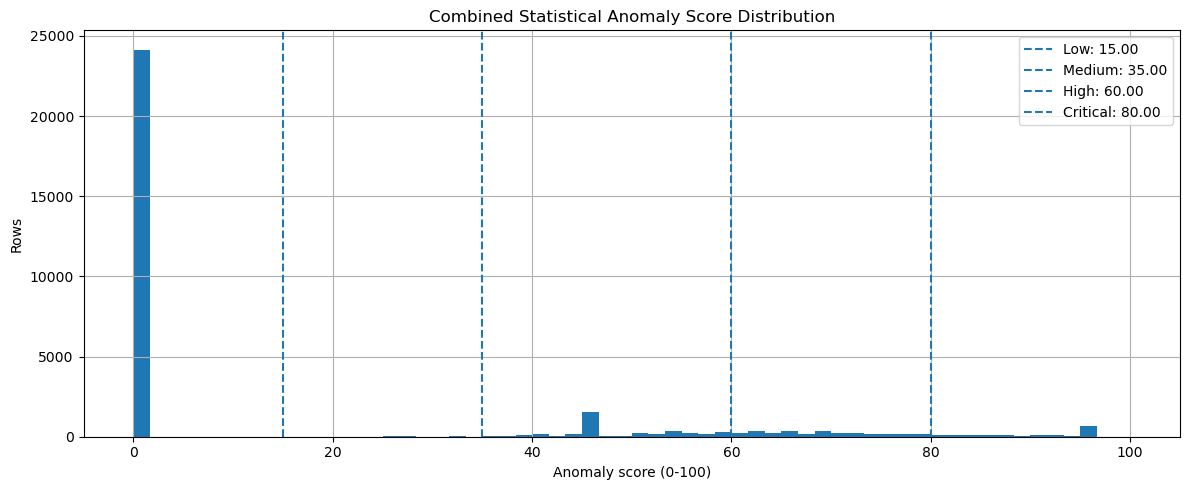

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\10b_anomaly_score_distribution_flagged_only.png


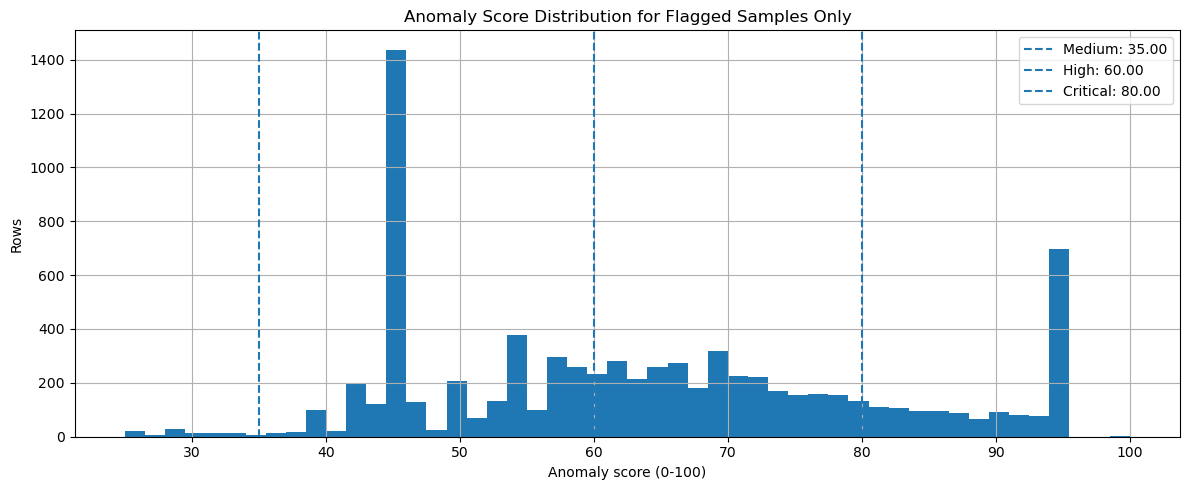

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\10c_anomaly_trigger_overlap_distribution.png


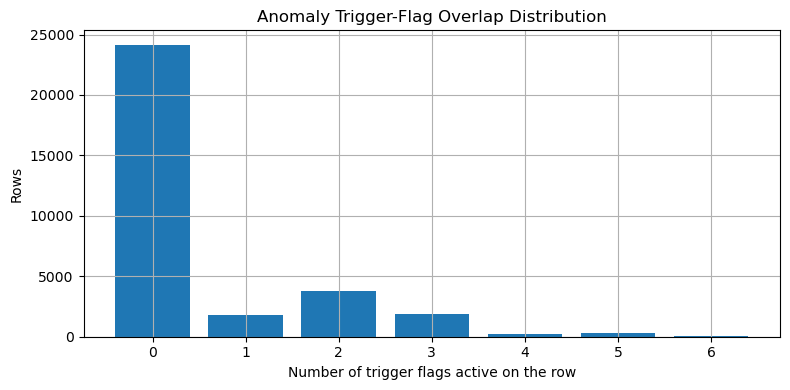

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\11_anomaly_method_percentages.png


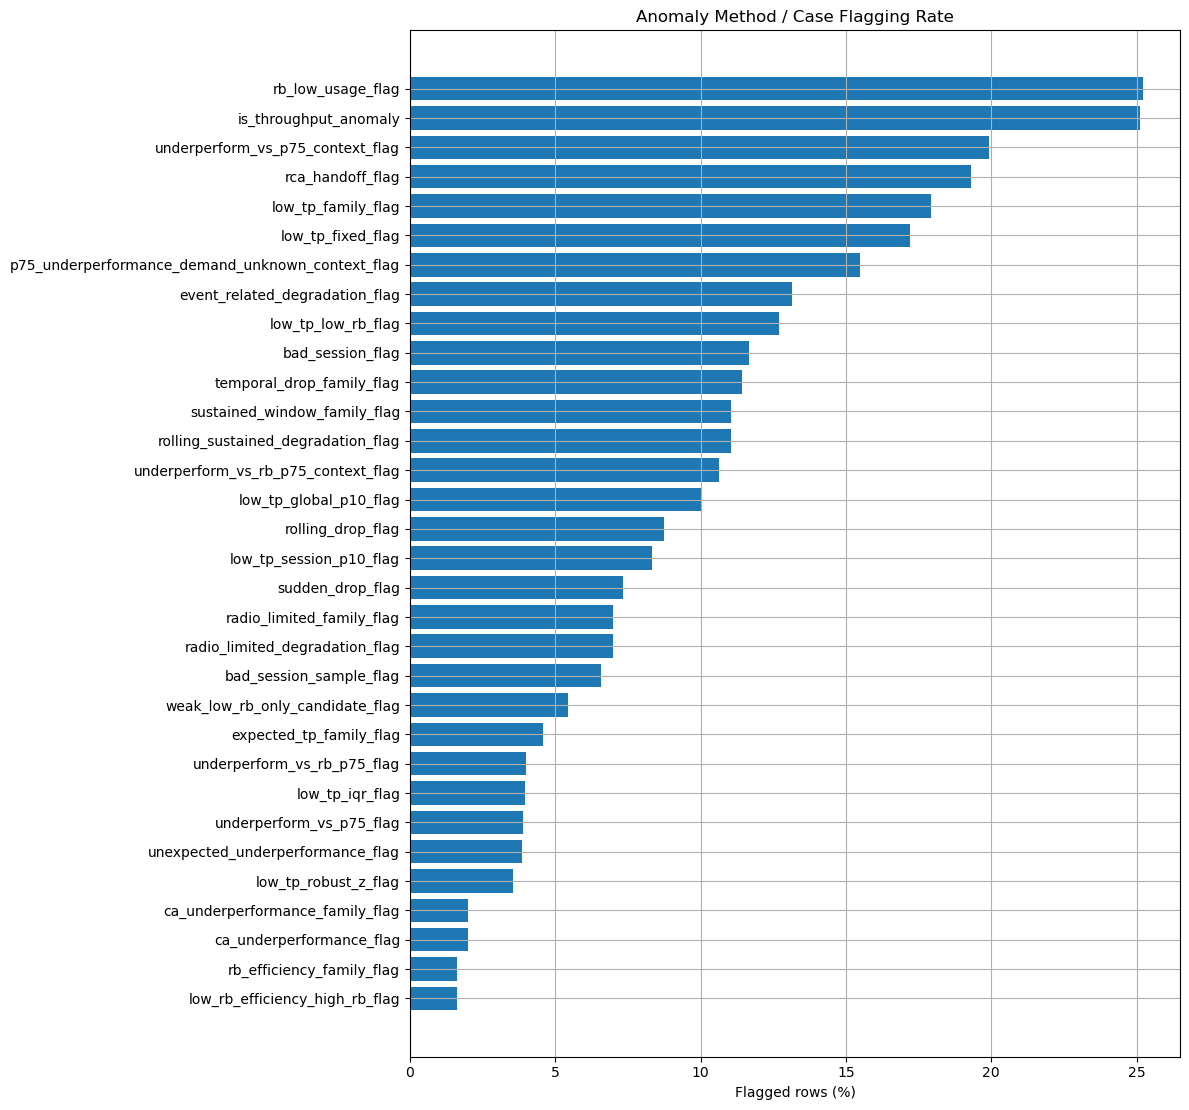

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\12_anomaly_count_by_type.png


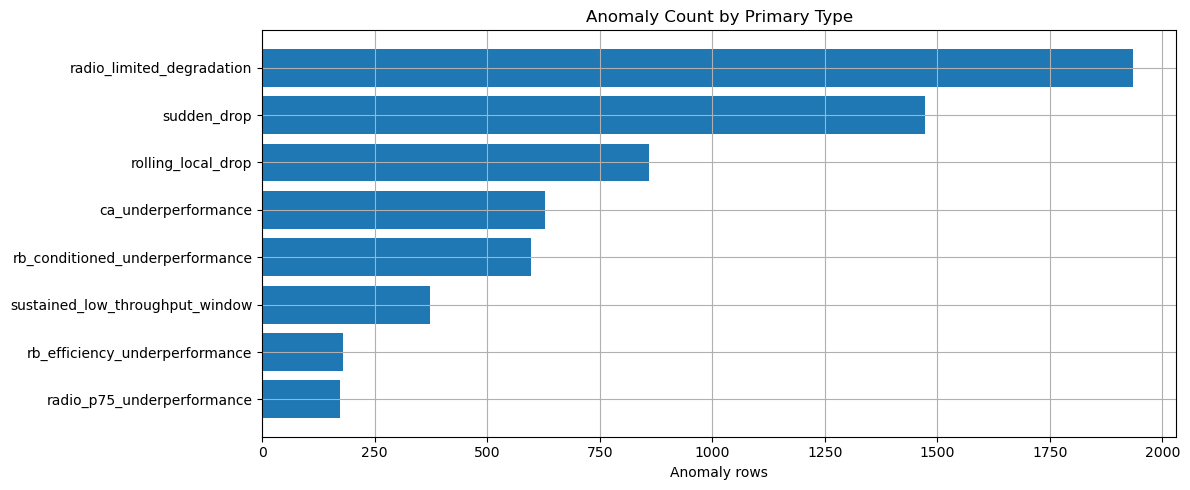

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\13_anomaly_count_by_severity.png


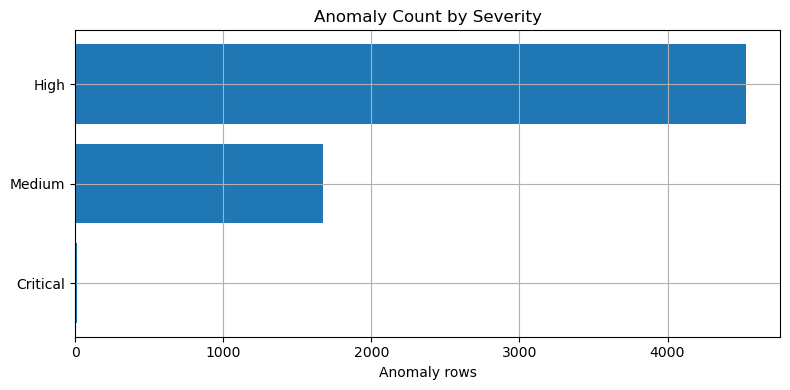

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\14_actual_vs_expected_with_anomalies.png


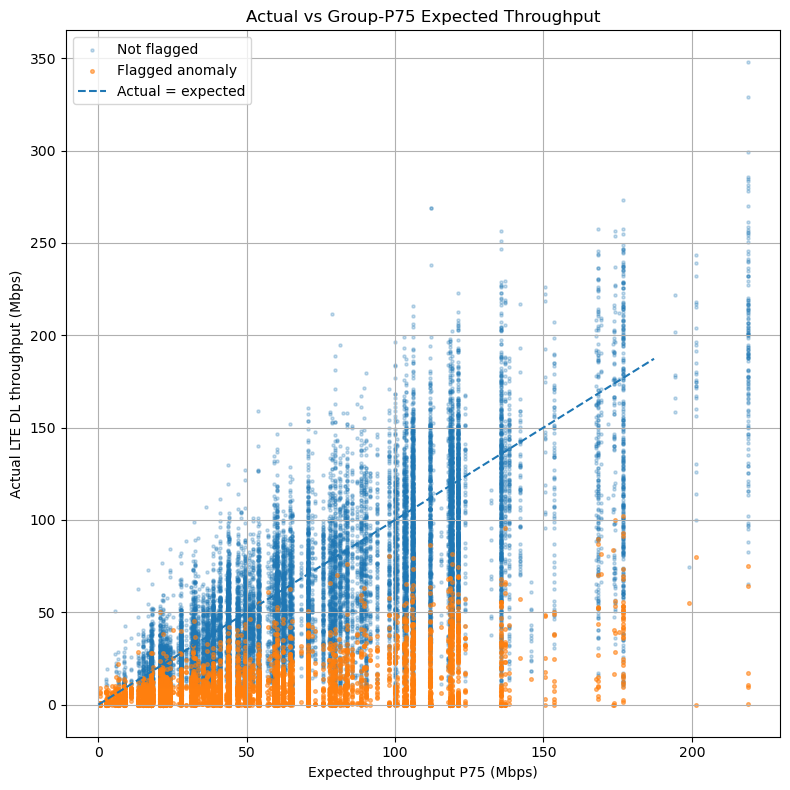

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\15_throughput_ratio_p75_distribution.png


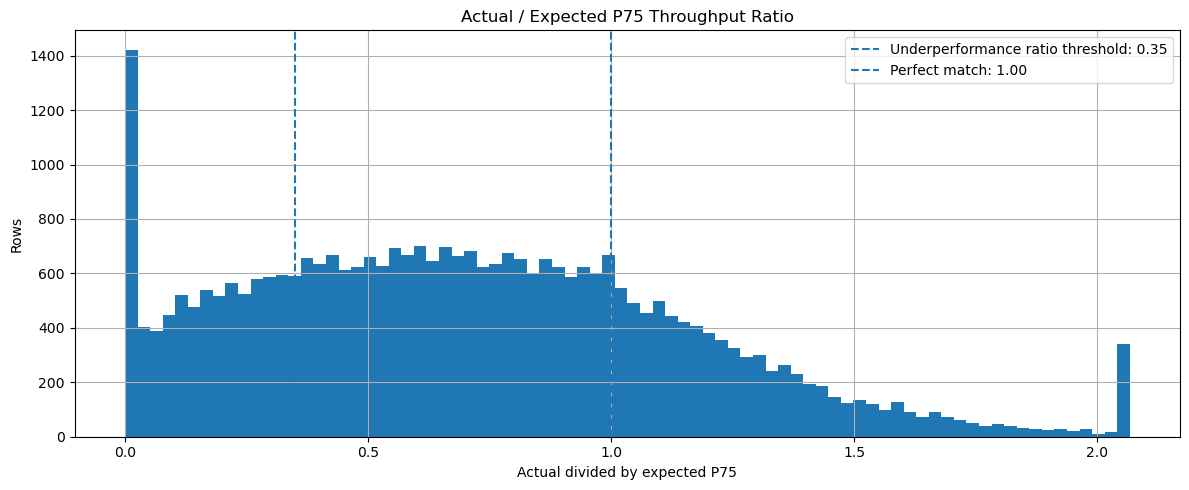

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\16_throughput_gap_p75_distribution.png


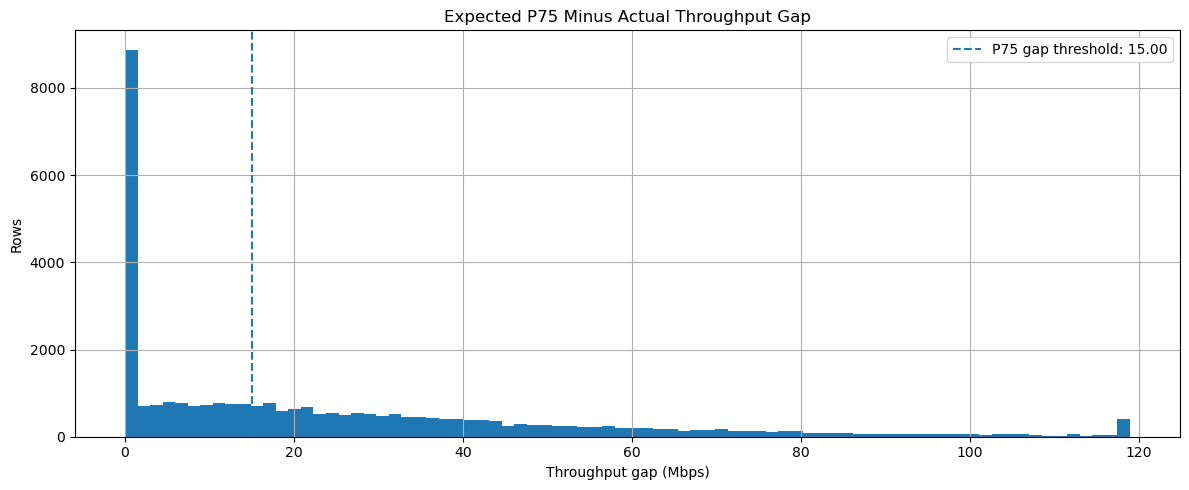

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\17_route_by_anomaly_score.png


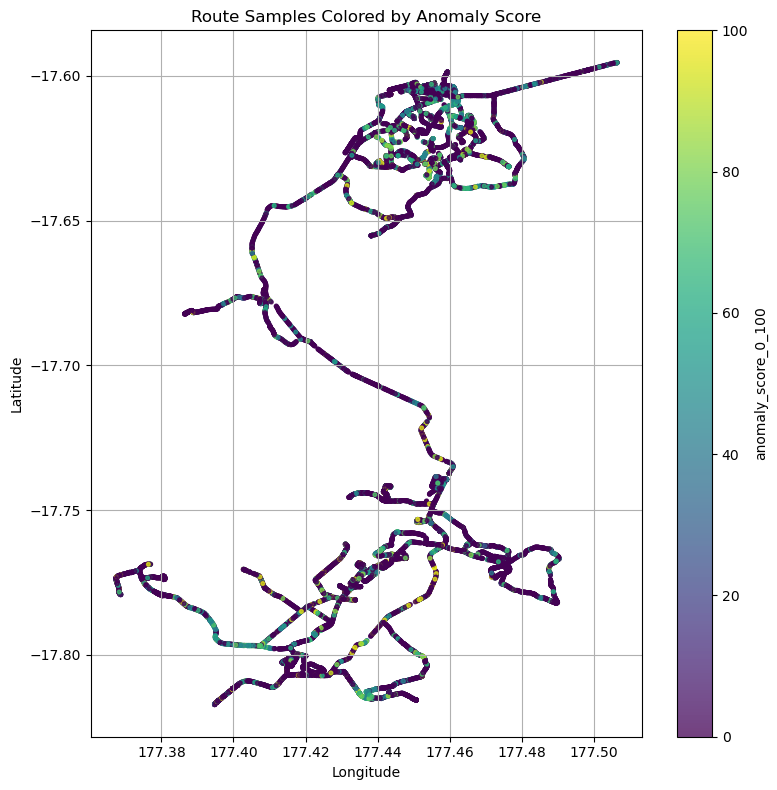

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\17c_route_with_anomaly_overlay.png


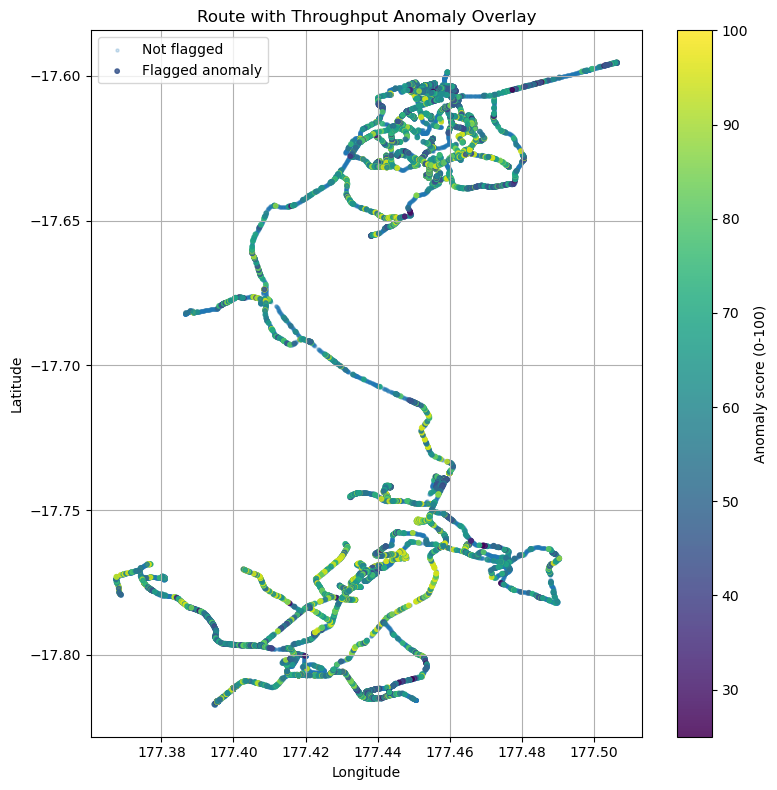

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\17b_route_by_download_analysis_window.png


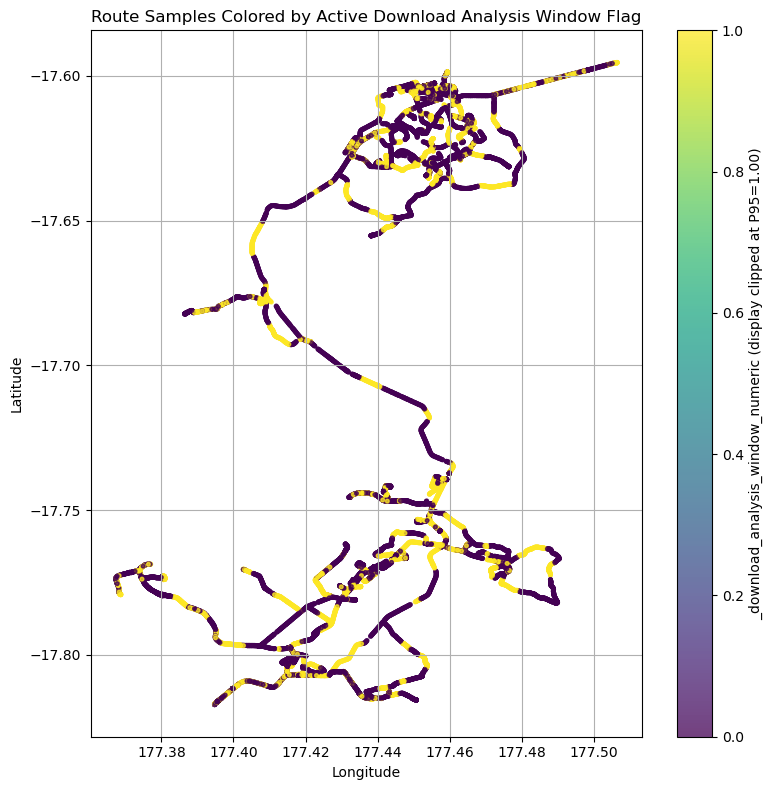

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-28 02:27:03+02:00,542020041221088+20250828123202+Fiji-Nadi-LTE-DL-D!20250828122853,rb_efficiency_underperformance,radio_limited_degradation;rb_efficiency_underperformance;rb_conditioned_underperformance;radio_p75_underperformance;rolling_local_drop;fixed_low_throughput;global_percentile_lo...,100.0,0.736984,62.203377,47.696416,0.011848,0.015452,138.0,medium_rb_usage,medium,0.00534,-96.81851,-13.428486,8.05699,2.0,active_download_analysis_window,True


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_1_throughput_context.png


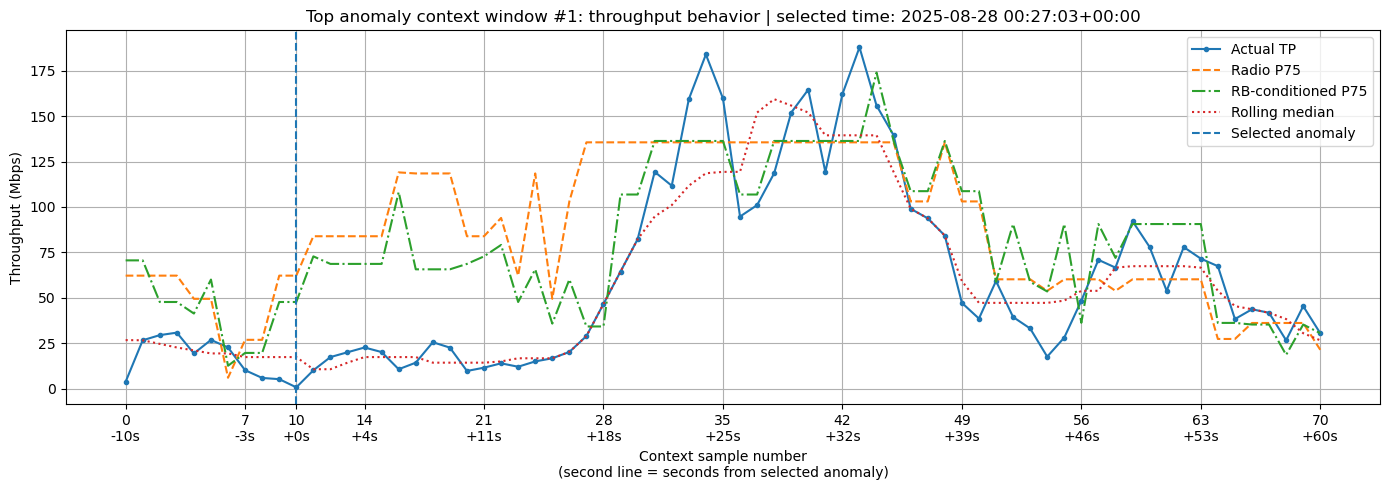

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_1_radio_context.png


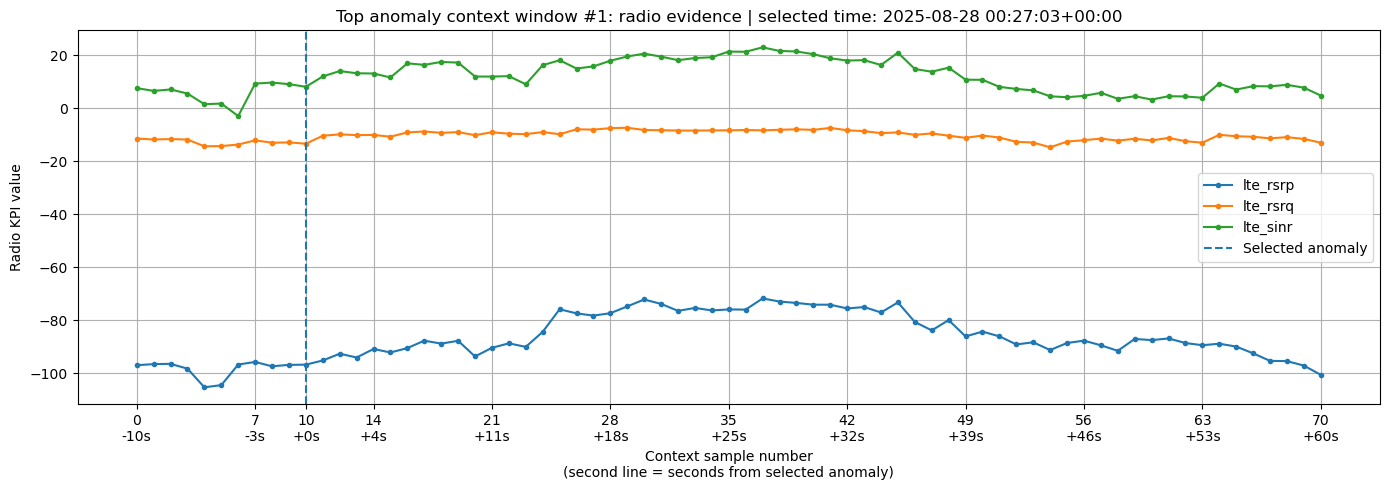

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 00:47:53+02:00,542020041221088+20250827105947+Fiji-Nadi-LTE-DL-D!20250827104944,sudden_drop,sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput;iqr_extreme_low_throughput,95.0,0.628464,88.404305,68.65446,0.007109,0.009154,81.0,below_median_rb_usage,unknown,0.007759,-84.02458,-8.129916,10.396427,2.0,active_download_analysis_window,True


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_2_throughput_context.png


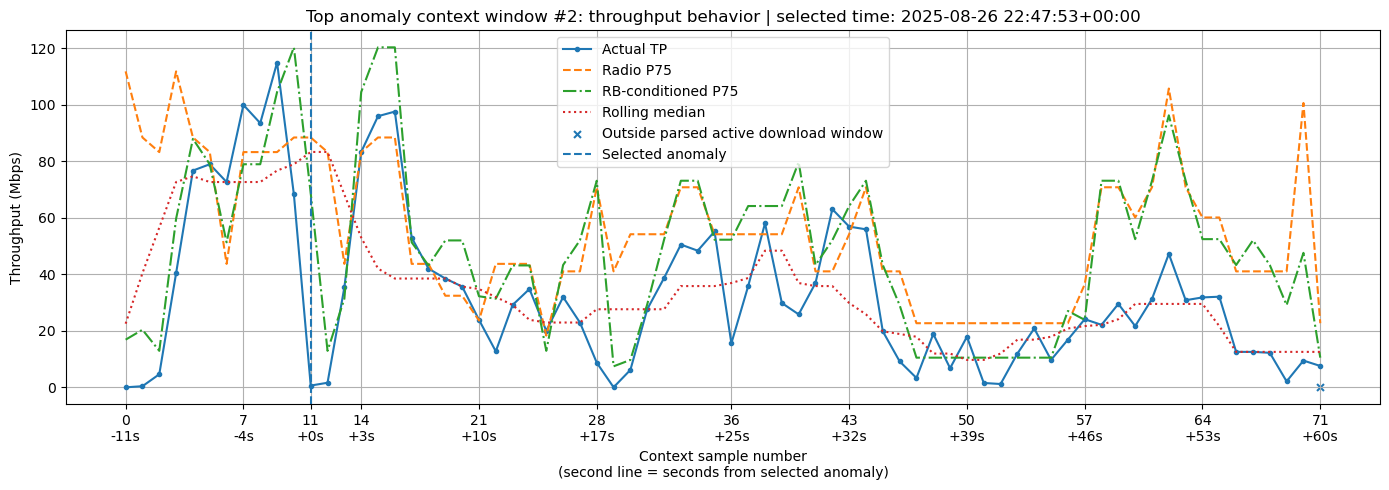

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_2_radio_context.png


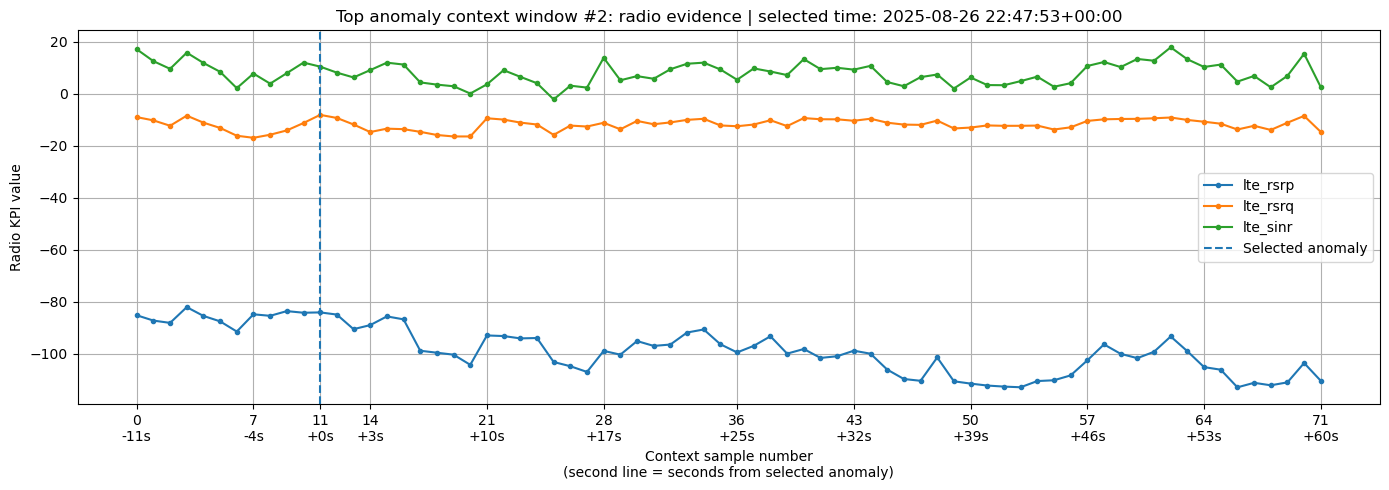

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 00:47:09+02:00,542020041221088+20250827105427+Fiji-Nadi-LTE-DL-D!20250827104733,sudden_drop,resource_limited_or_demand_uncertain_low_throughput;sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput;iqr_e...,95.0,0.069088,111.794821,16.868154,0.000618,0.004096,21.0,low_rb_usage,low_or_uncertain,0.00329,-87.09079,-7.857237,17.42222,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_3_throughput_context.png


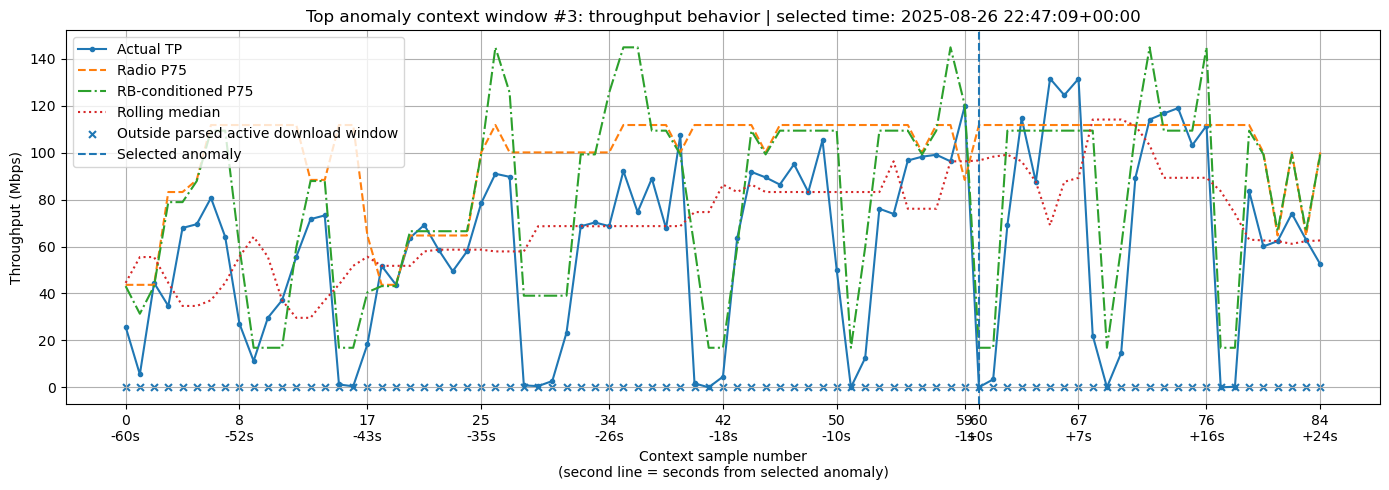

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_3_radio_context.png


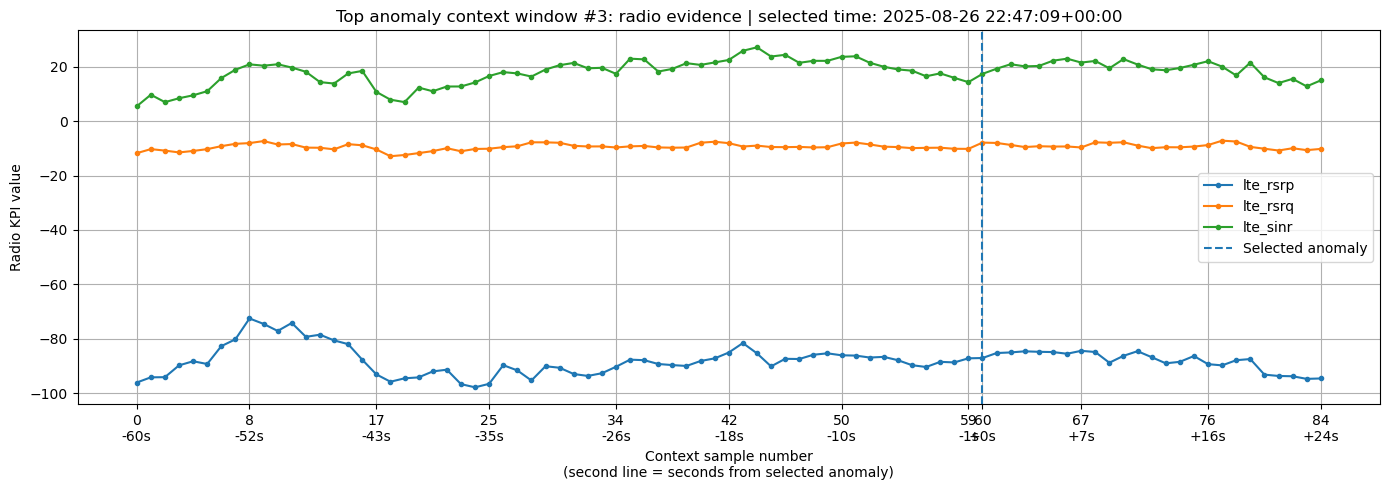

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 00:46:38+02:00,542020041221088+20250827105427+Fiji-Nadi-LTE-DL-D!20250827104733,rolling_local_drop,resource_limited_or_demand_uncertain_low_throughput;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput;iqr_extreme_low_t...,95.0,0.51792,100.1201,39.058921,0.005173,0.01326,6.0,low_rb_usage,low_or_uncertain,0.08632,-90.10815,-7.760534,19.01548,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_4_throughput_context.png


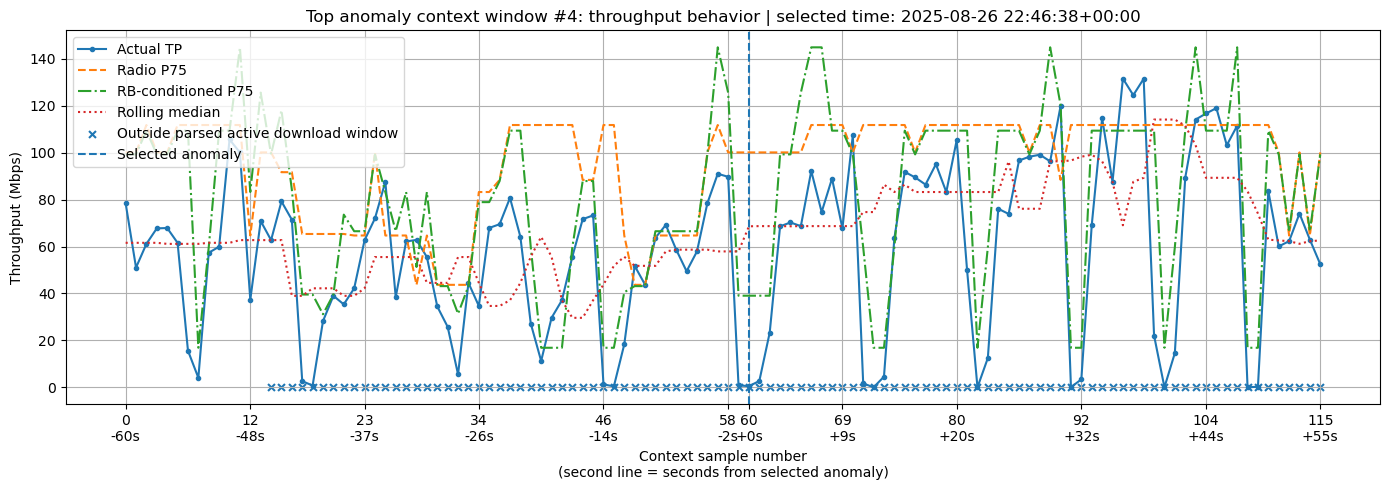

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_4_radio_context.png


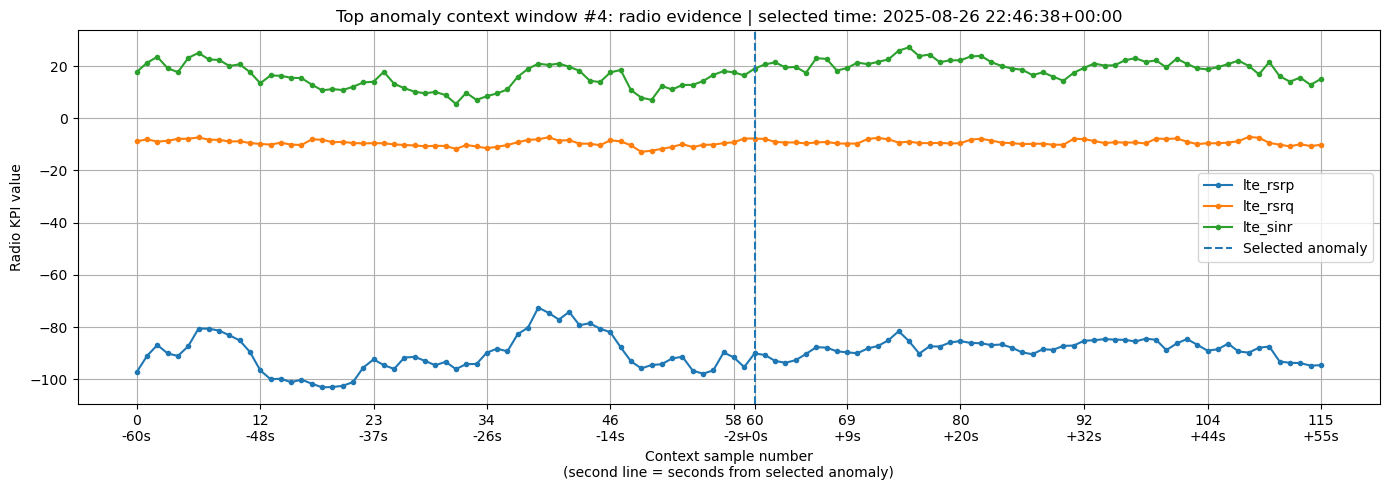

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 05:12:14+02:00,542020041221088+20250827151332+Fiji-Nadi-LTE-DL-D!20250827151309,sudden_drop,resource_limited_or_demand_uncertain_low_throughput;sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput;iqr_e...,95.0,0.363792,137.05949,30.167366,0.002654,0.012059,9.0,low_rb_usage,low_or_uncertain,0.040421,-72.69133,-9.365434,16.83077,3.0,active_download_analysis_window,True


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_5_throughput_context.png


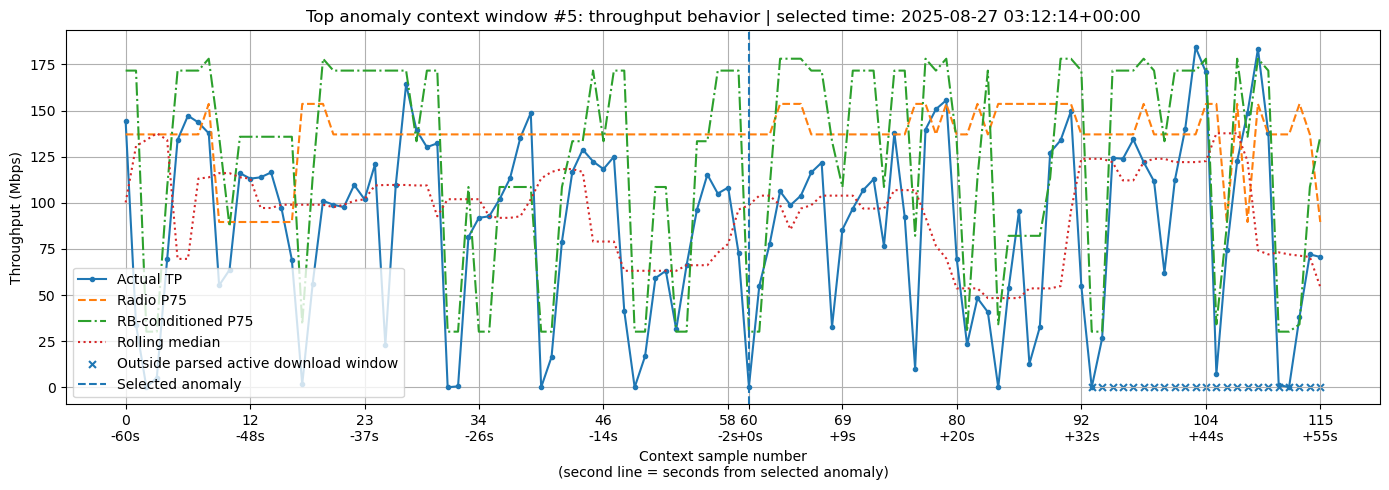

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_5_radio_context.png


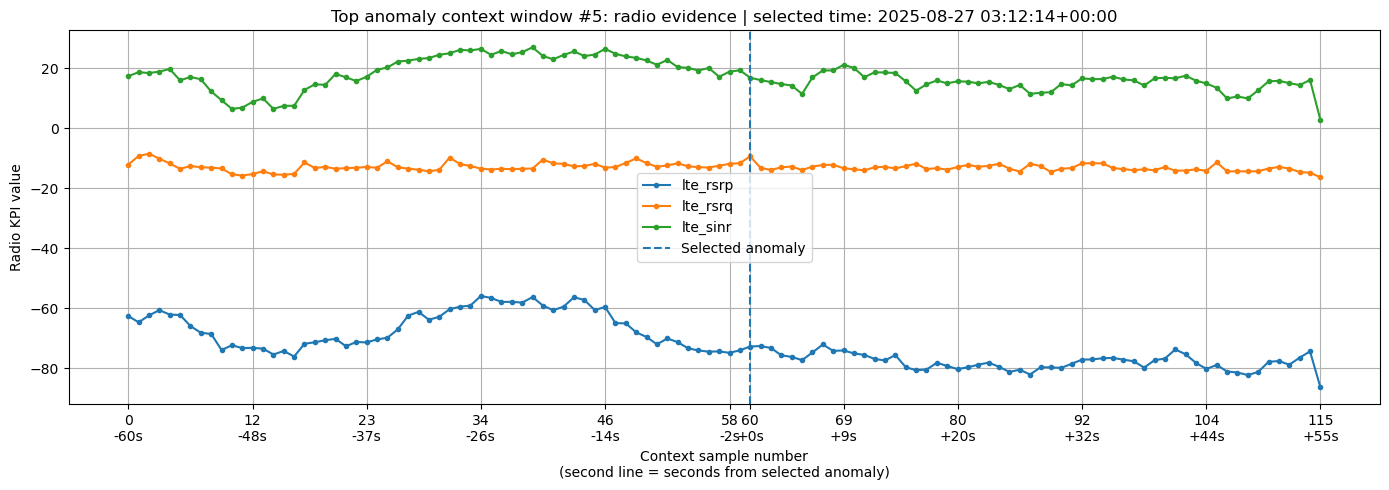

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 00:46:49+02:00,542020041221088+20250827105427+Fiji-Nadi-LTE-DL-D!20250827104733,sudden_drop,sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput,95.0,1.67832,111.794821,59.686957,0.015013,0.028119,91.0,below_median_rb_usage,unknown,0.018443,-88.1875,-7.910618,20.71477,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_6_throughput_context.png


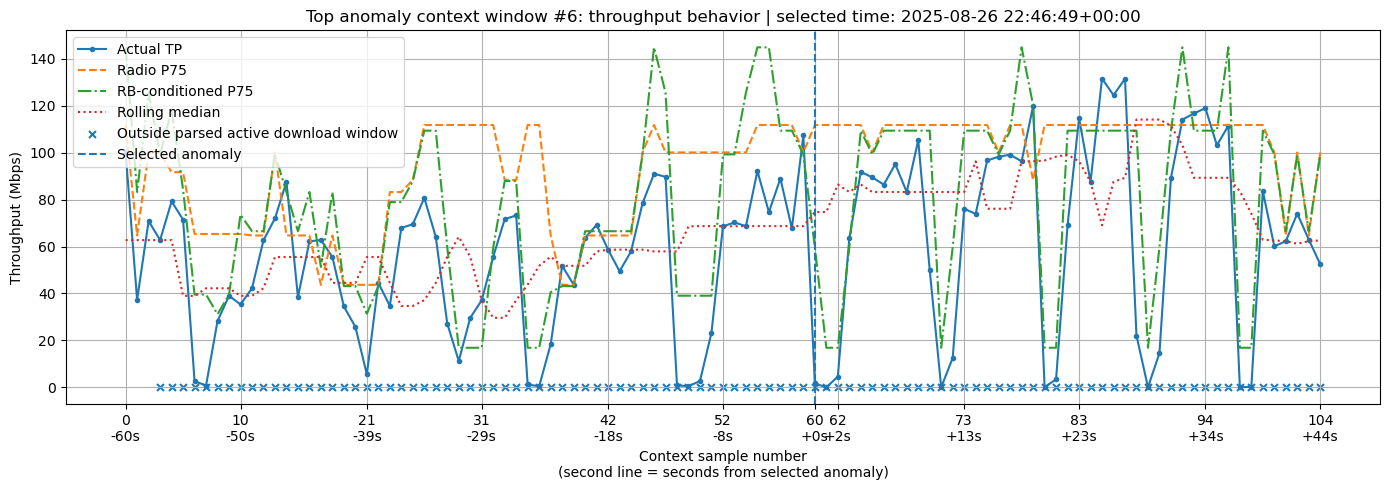

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_6_radio_context.png


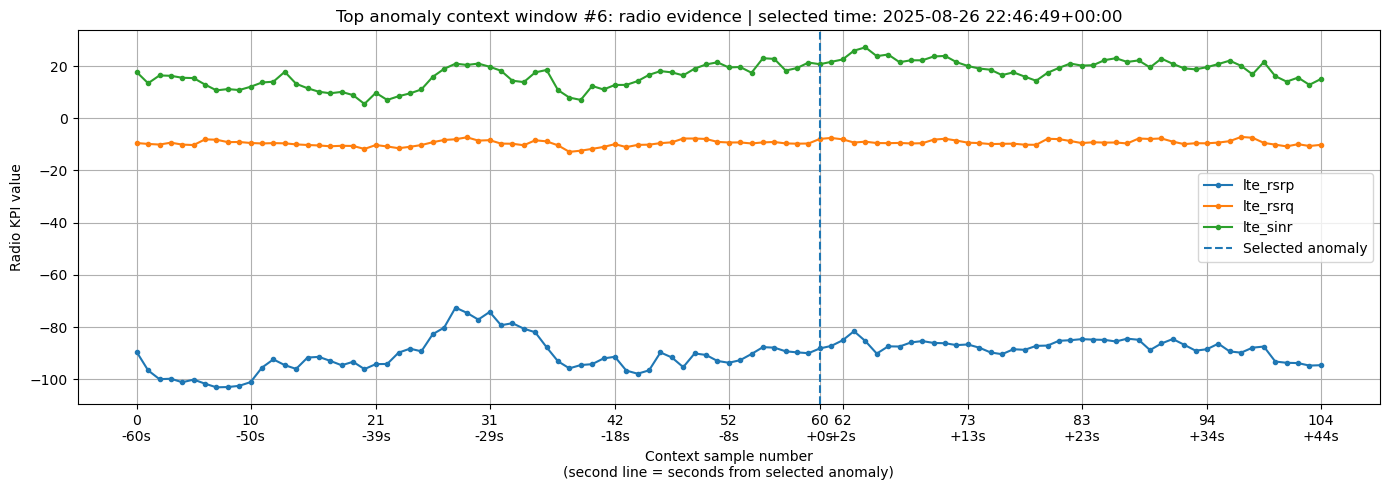

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 01:35:29+02:00,542020041221088+20250827122555+Fiji-Nadi-LTE-DL-D!20250827113546,ca_underperformance,unexpected_underperformance;ca_underperformance;rb_efficiency_underperformance;rb_conditioned_underperformance;radio_p75_underperformance;sudden_drop;rolling_local_drop;fixed_l...,95.0,2.915104,62.203377,70.60763,0.046864,0.041286,172.0,high_rb_usage,high,0.016948,-93.76806,-9.832639,8.375002,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_7_throughput_context.png


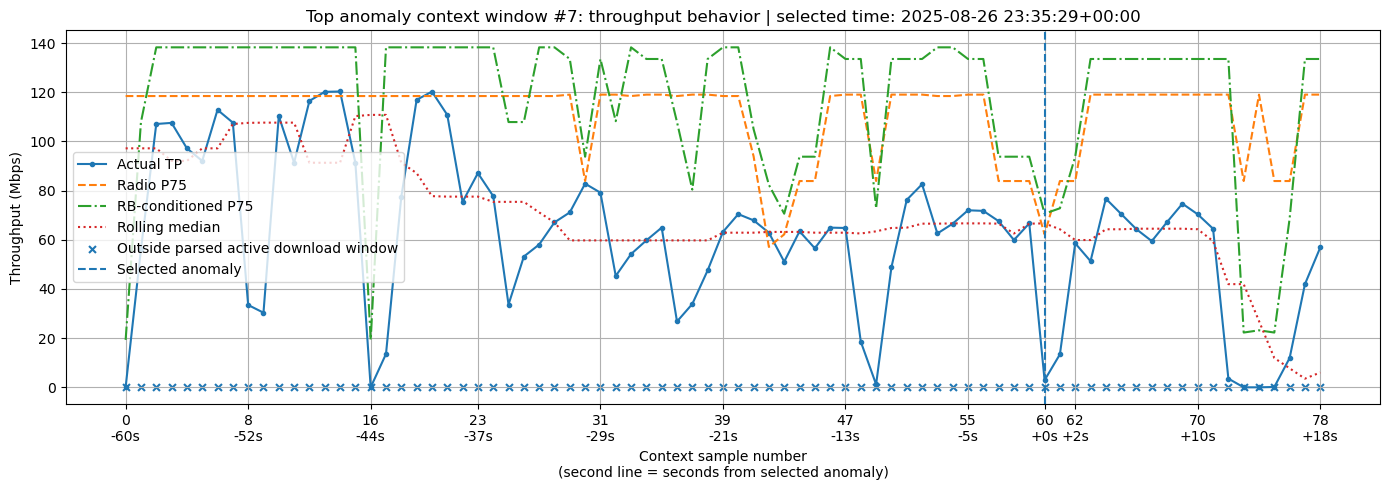

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_7_radio_context.png


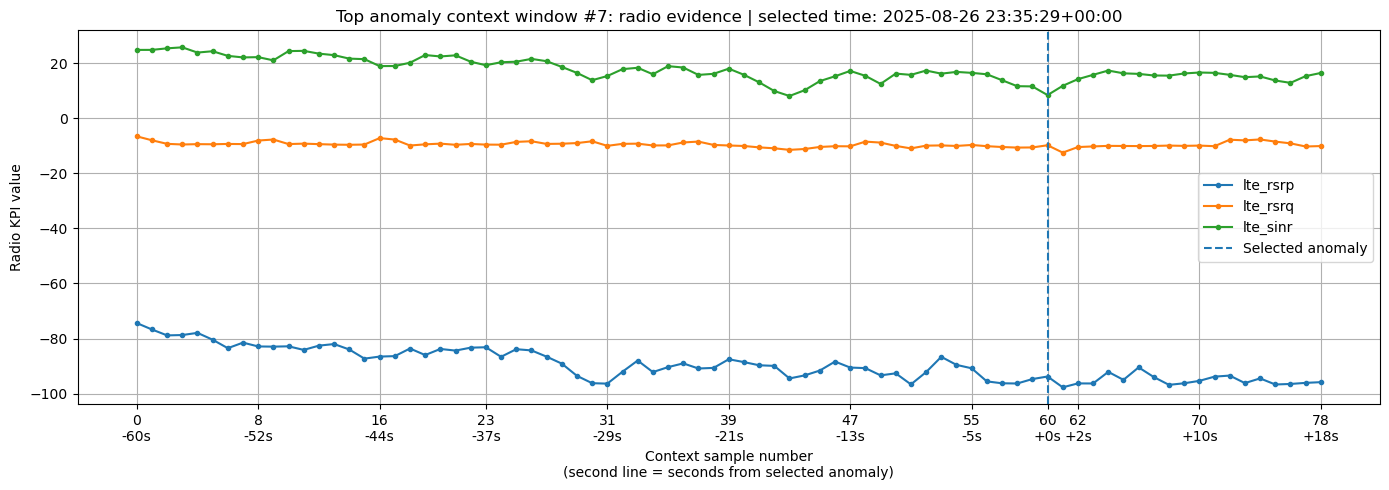

Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 00:47:00+02:00,542020041221088+20250827105427+Fiji-Nadi-LTE-DL-D!20250827104733,sudden_drop,resource_limited_or_demand_uncertain_low_throughput;sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput;iqr_e...,95.0,0.011568,111.794821,16.868154,0.000103,0.000686,4.0,low_rb_usage,low_or_uncertain,0.002892,-86.195786,-7.847891,23.885902,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_8_throughput_context.png


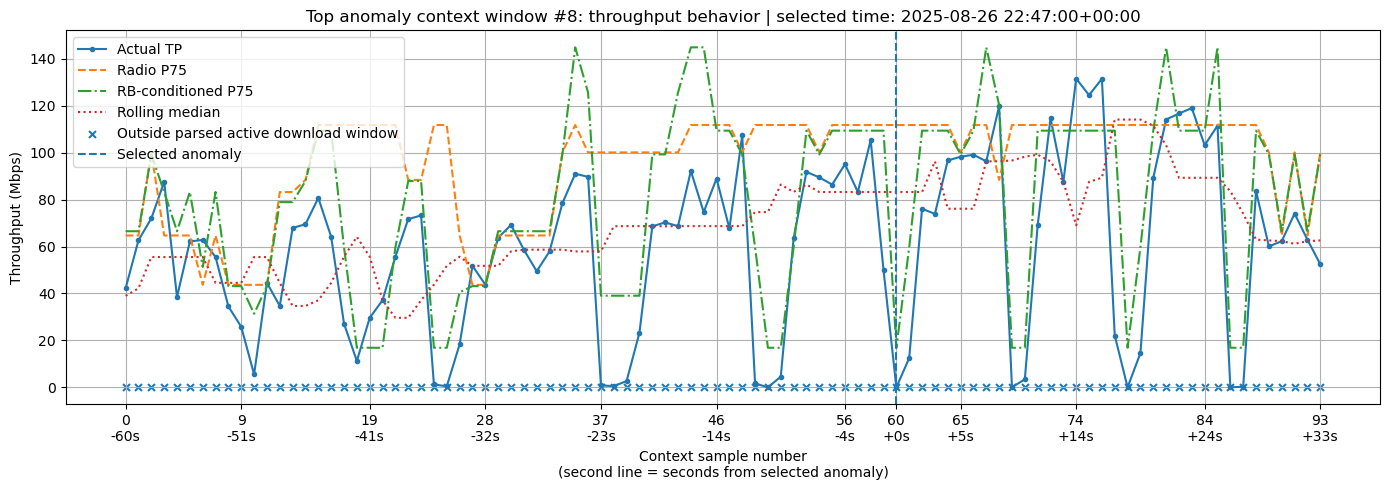

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\18_top_anomaly_episode_context_rank_8_radio_context.png


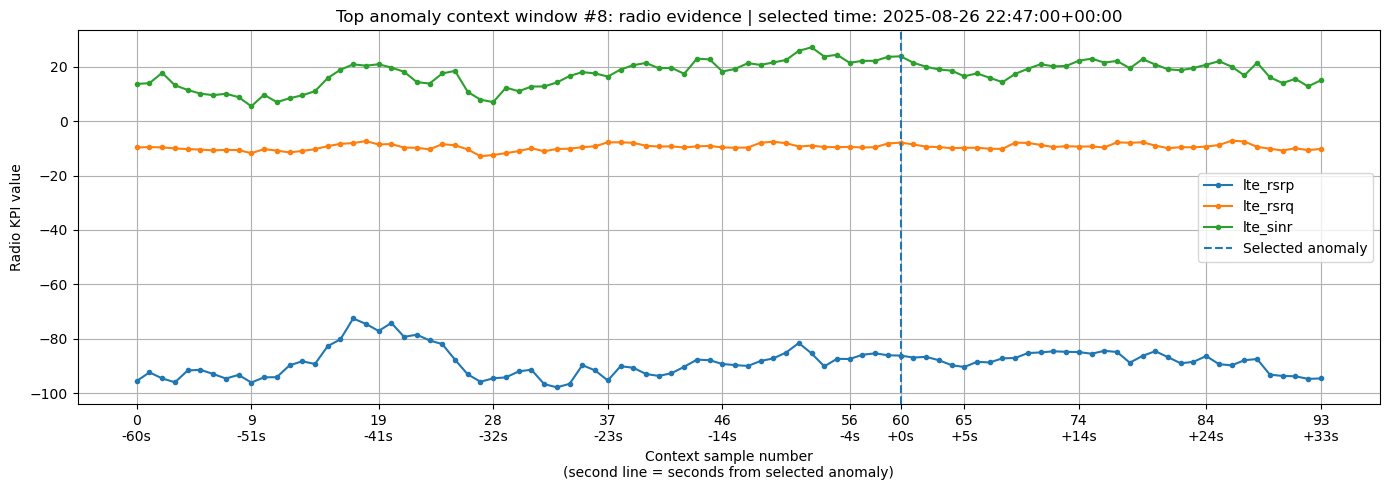


Representative anomaly type example: radio_limited_degradation
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 05:21:36+02:00,542020041221088+20250827152532+Fiji-Nadi-LTE-DL-D!20250827152209,radio_limited_degradation,radio_limited_degradation;resource_limited_or_demand_uncertain_low_throughput;sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_perce...,95.0,0.005424,83.886915,22.27708,0.000065,0.000243,3.0,low_rb_usage,low_or_uncertain,0.001808,-96.23542,-8.297916,14.233928,2.0,active_download_analysis_window,True


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_1_radio_limited_degradation_rank_1_throughput_context.png


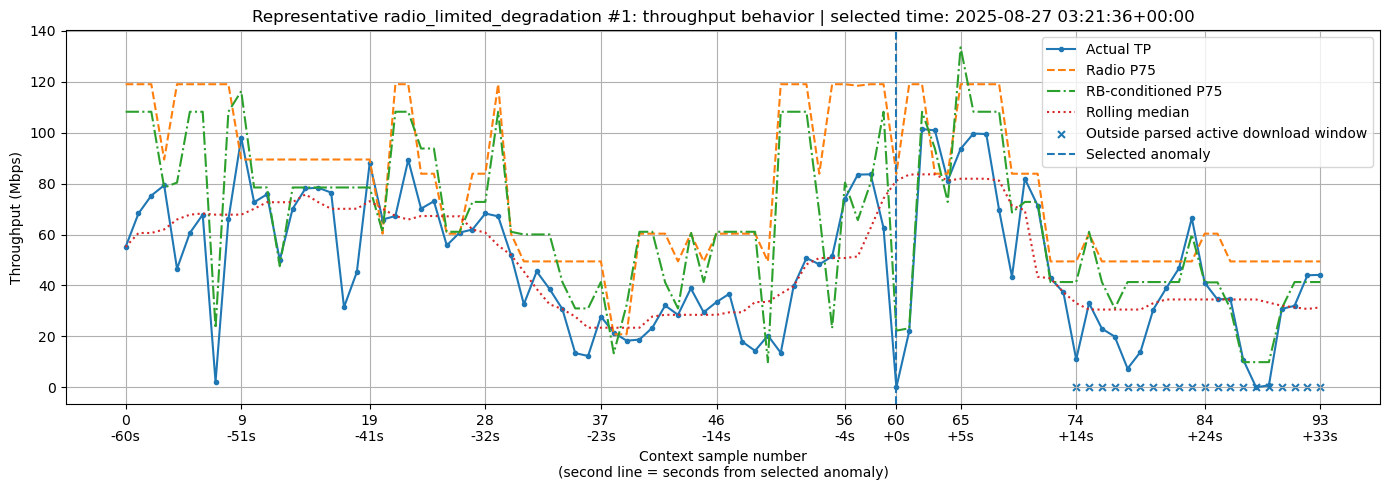

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_1_radio_limited_degradation_rank_1_radio_context.png


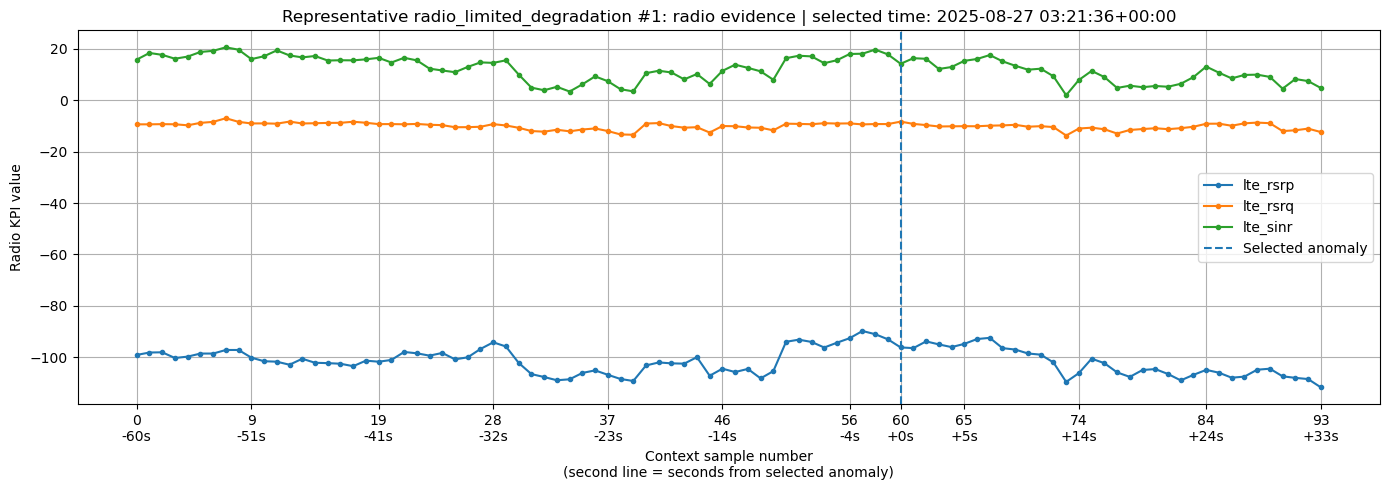


Representative anomaly type example: sudden_drop
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 01:57:00+02:00,542020041221088+20250827123938+Fiji-Nadi-LTE-DL-D!20250827115735,sudden_drop,resource_limited_or_demand_uncertain_low_throughput;sudden_drop;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput,95.0,4.437736,119.029043,23.190584,0.037283,0.191359,70.0,low_rb_usage,low_or_uncertain,0.063396,-94.52051,-7.349609,23.084906,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_2_sudden_drop_rank_1_throughput_context.png


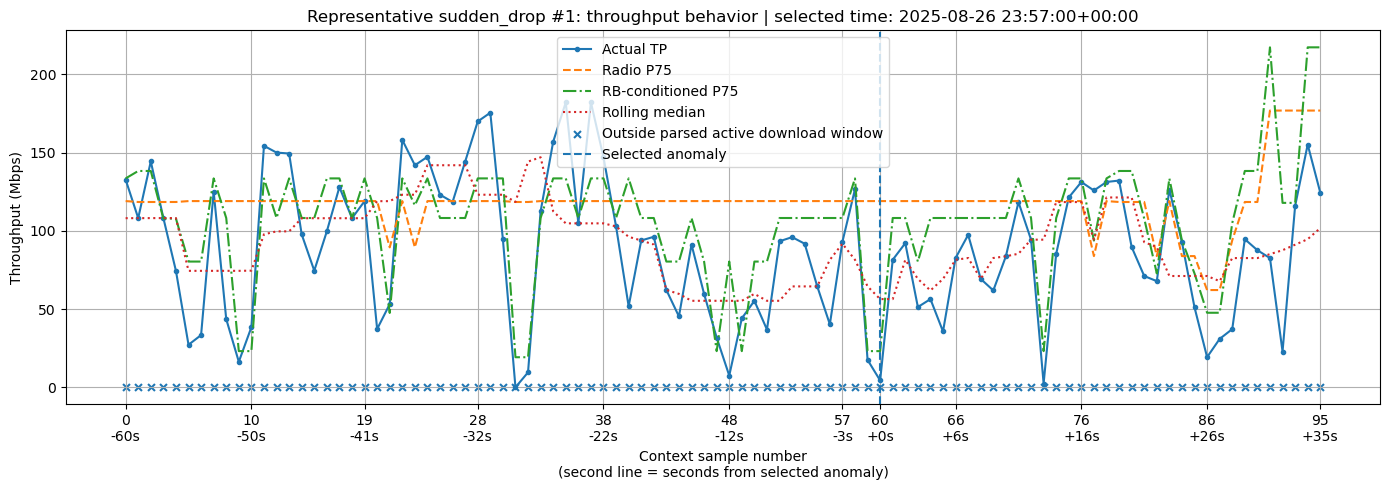

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_2_sudden_drop_rank_1_radio_context.png


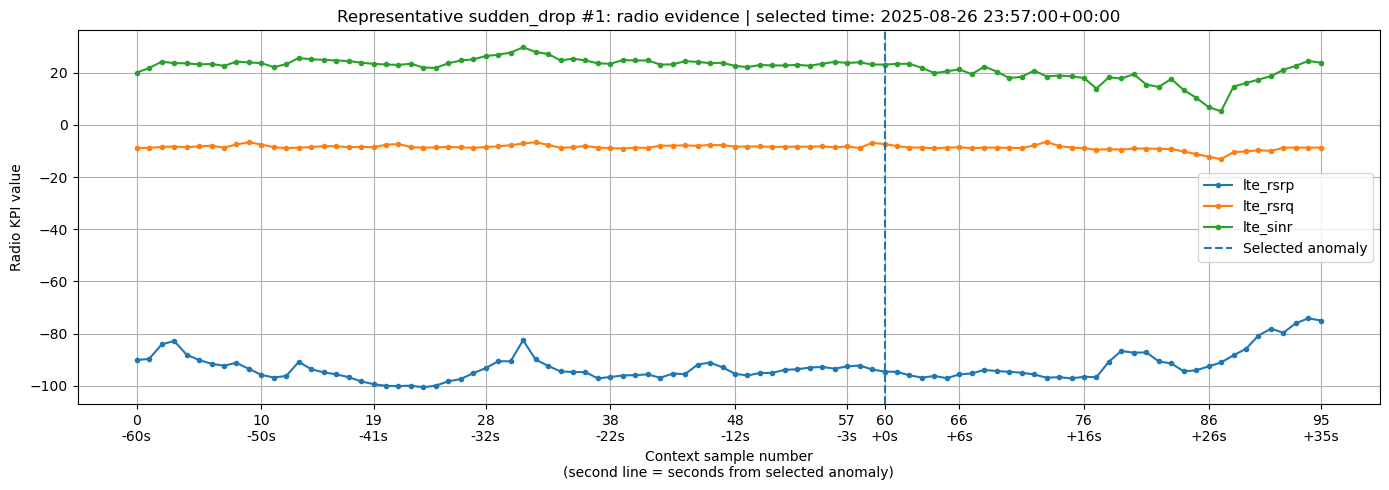


Representative anomaly type example: rolling_local_drop
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 03:04:24+02:00,542020041221088+20250827134107+Fiji-Nadi-LTE-DL-D!20250827130537,rolling_local_drop,resource_limited_or_demand_uncertain_low_throughput;rolling_local_drop;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput;iqr_extreme_low_t...,95.0,0.004448,111.794821,16.868154,0.00004,0.000264,1.0,low_rb_usage,low_or_uncertain,0.004448,-79.82523,-7.236111,23.389324,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_3_rolling_local_drop_rank_1_throughput_context.png


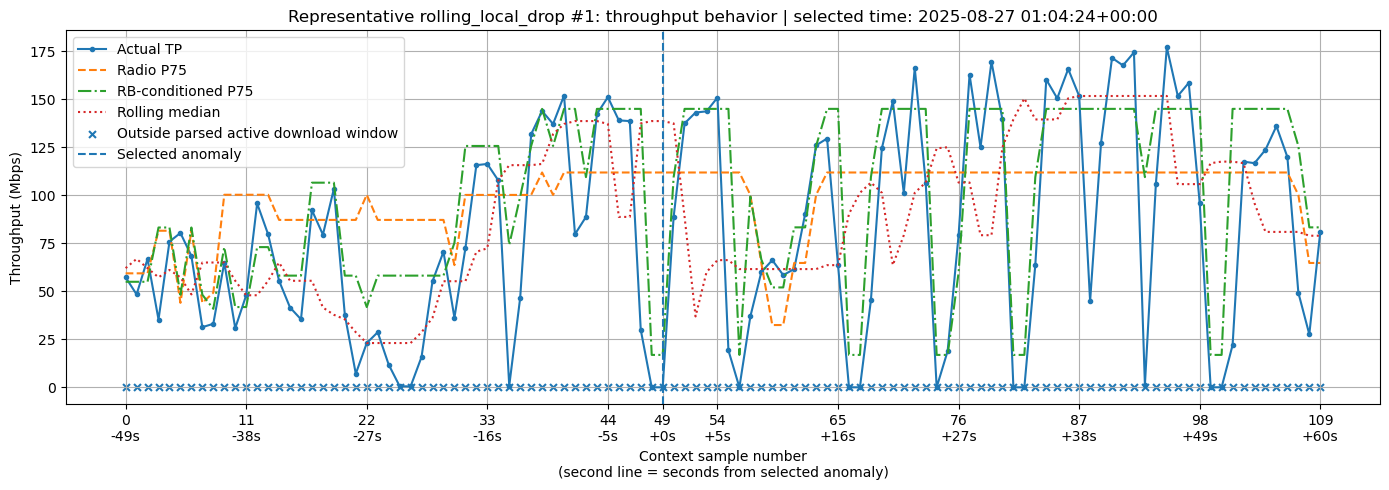

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_3_rolling_local_drop_rank_1_radio_context.png


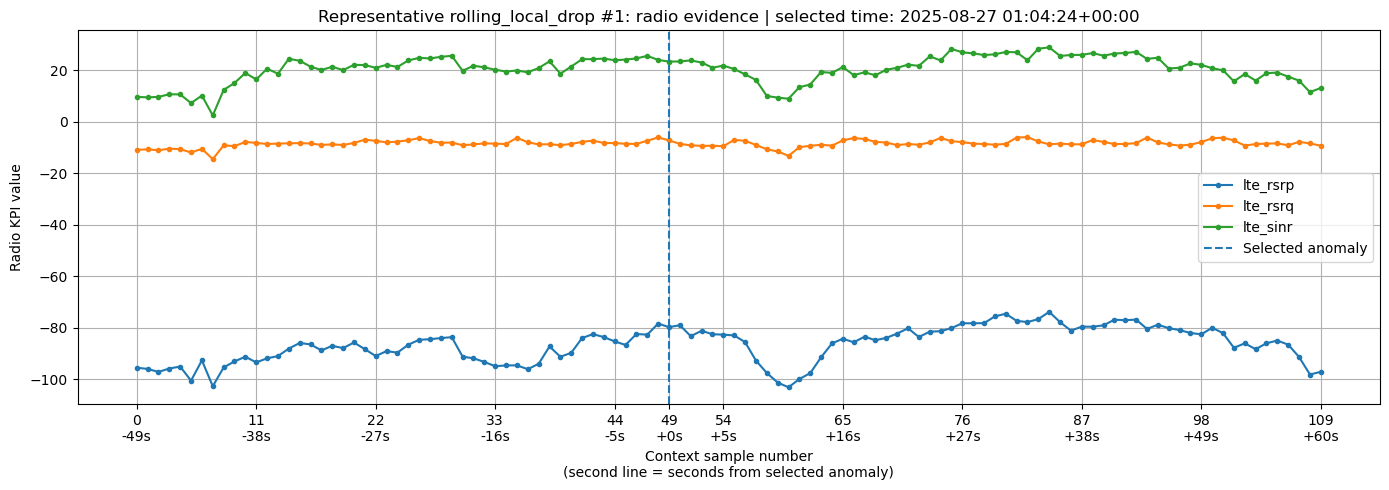


Representative anomaly type example: ca_underperformance
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 05:15:00+02:00,542020041221088+20250827151552+Fiji-Nadi-LTE-DL-D!20250827151524,ca_underperformance,unexpected_underperformance;ca_underperformance;rb_efficiency_underperformance;rb_conditioned_underperformance;radio_p75_underperformance;sudden_drop;rolling_local_drop;fixed_l...,95.0,3.987808,60.159914,55.064114,0.066287,0.072421,132.0,medium_rb_usage,medium,0.030211,-100.57062,-9.864448,11.965754,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_4_ca_underperformance_rank_1_throughput_context.png


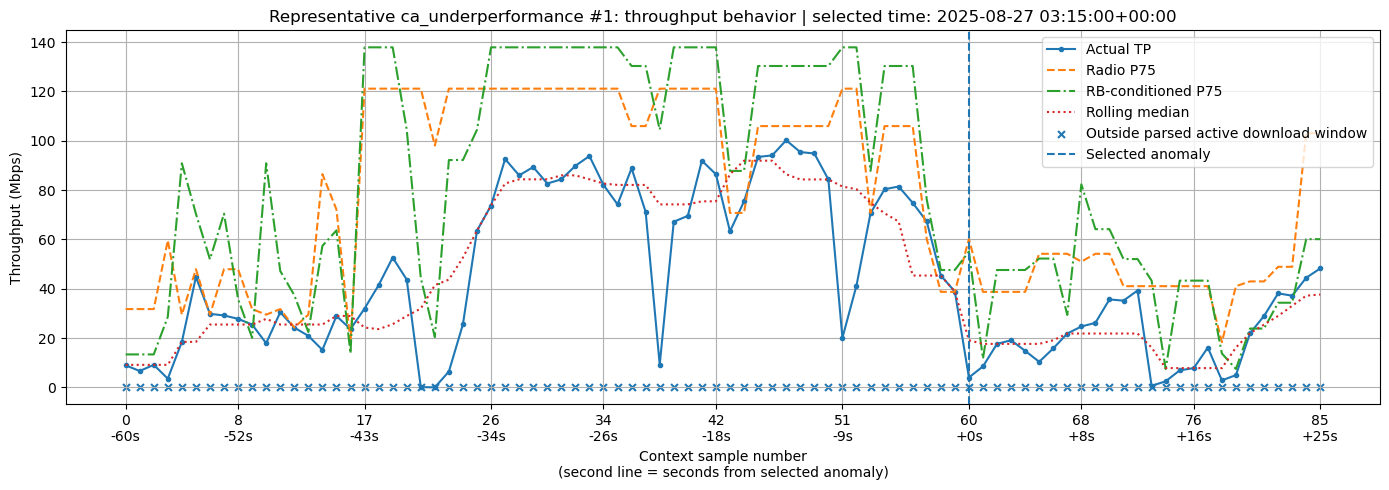

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_4_ca_underperformance_rank_1_radio_context.png


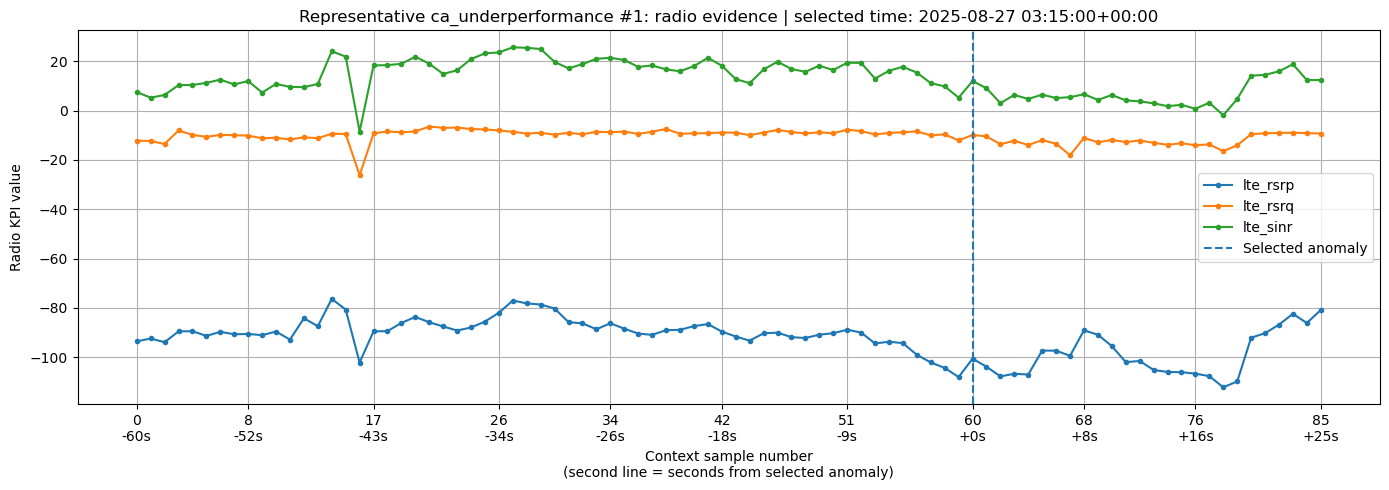


Representative anomaly type example: rb_conditioned_underperformance
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-28 02:49:39+02:00,542020041221088+20250828125203+Fiji-Nadi-LTE-DL-D!20250828125121,rb_conditioned_underperformance,radio_limited_degradation;rb_conditioned_underperformance;radio_p75_underperformance;sudden_drop;rolling_local_drop,95.0,10.097096,111.794821,109.39058,0.090318,0.092303,137.0,medium_rb_usage,medium,0.073701,-83.24787,-12.410511,15.805122,2.0,download_warmup_or_cooldown,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_5_rb_conditioned_underperformance_rank_1_throughput_context.png


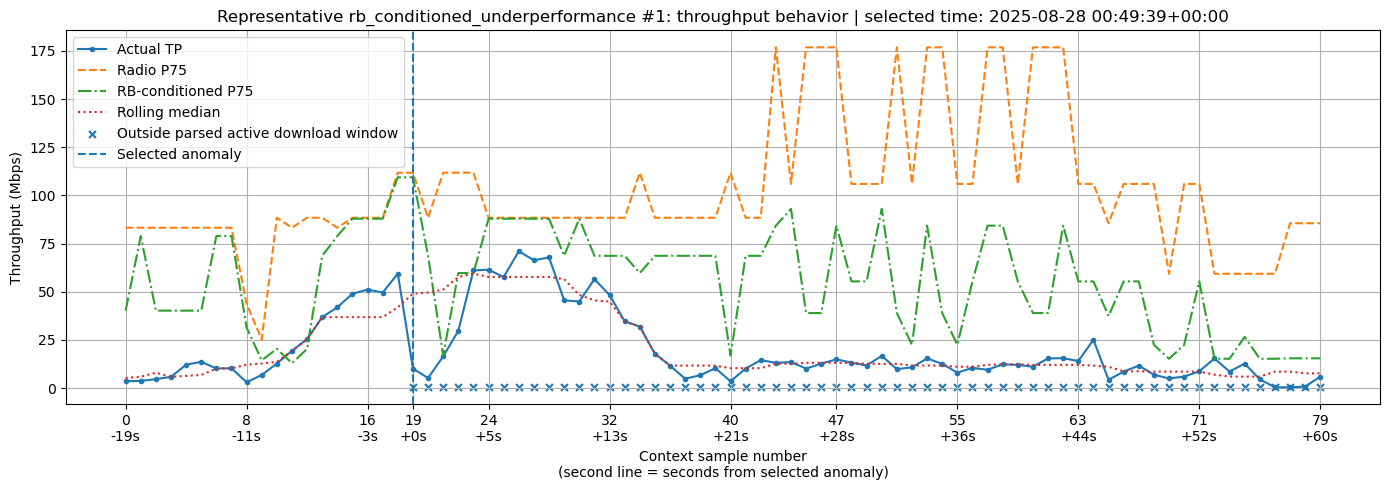

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_5_rb_conditioned_underperformance_rank_1_radio_context.png


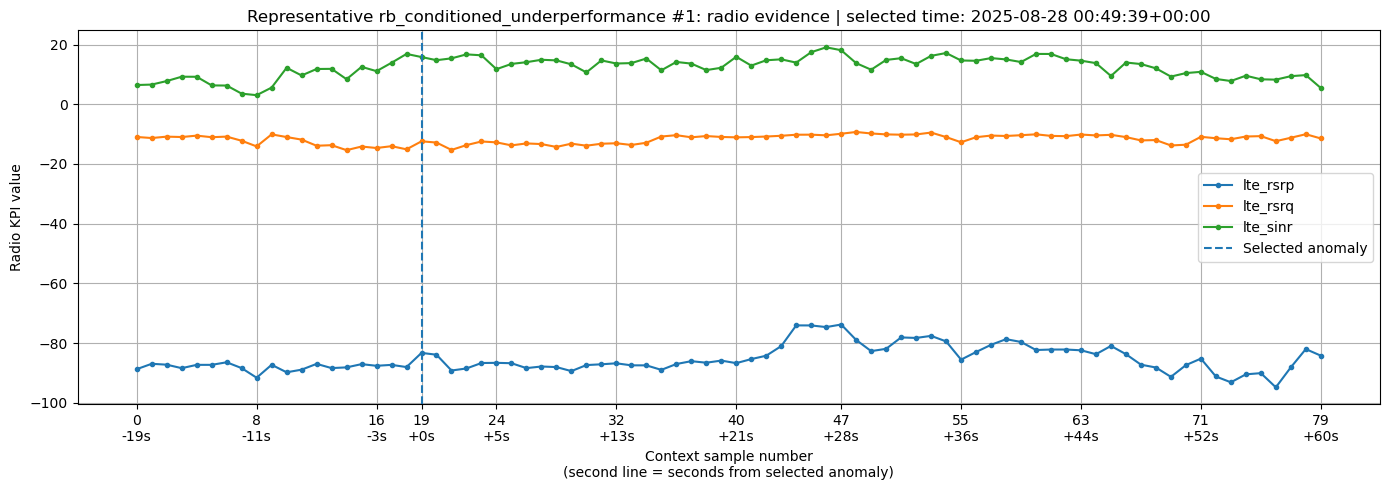


Representative anomaly type example: sustained_low_throughput_window
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-28 02:49:03+02:00,542020041221088+20250828124943+Fiji-Nadi-LTE-DL-D!20250828124907,sustained_low_throughput_window,sustained_low_throughput_window;fixed_low_throughput;global_percentile_low_throughput;session_percentile_low_throughput,95.0,0.971768,98.077295,55.897085,0.009908,0.017385,85.0,below_median_rb_usage,unknown,0.011433,-88.12234,-10.146276,11.168181,2.0,outside_download_activity,False


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_6_sustained_low_throughput_window_rank_1_throughput_context.png


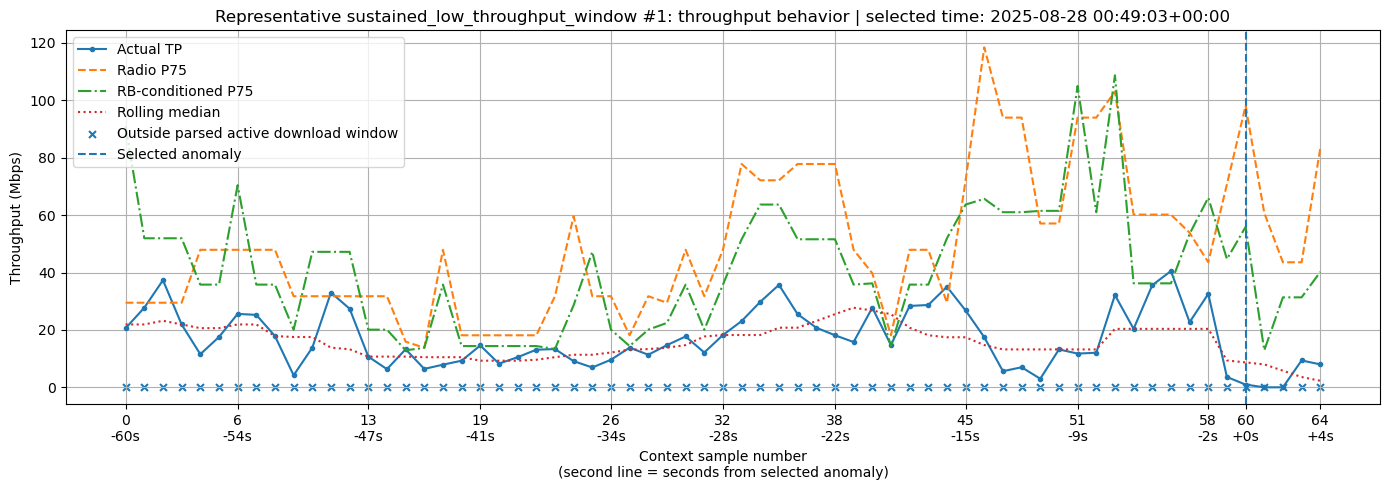

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_6_sustained_low_throughput_window_rank_1_radio_context.png


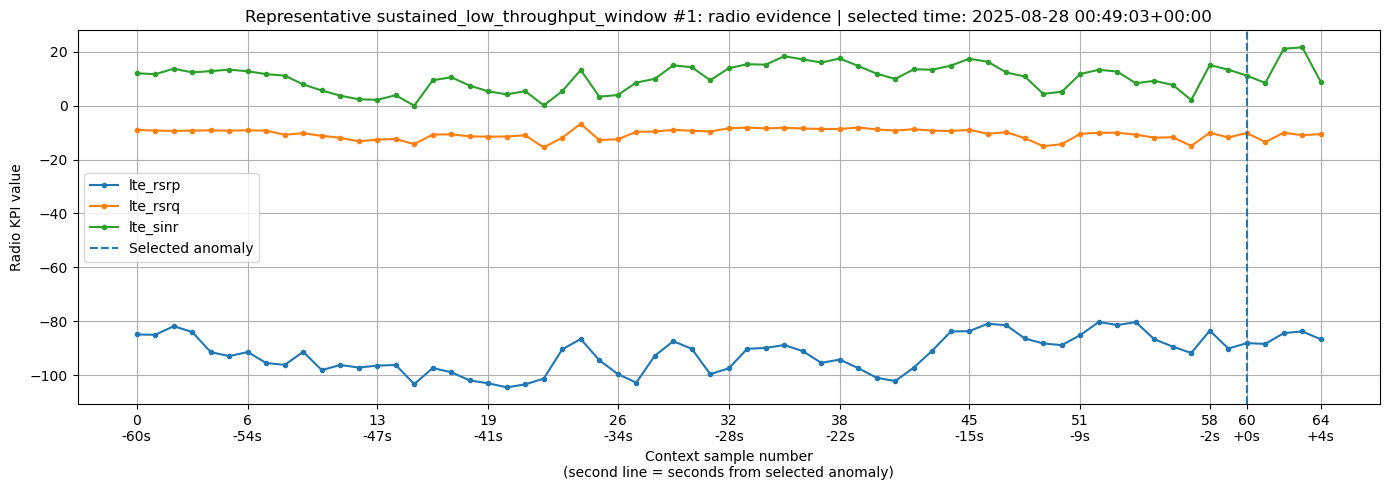


Representative anomaly type example: rb_efficiency_underperformance
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-28 02:27:03+02:00,542020041221088+20250828123202+Fiji-Nadi-LTE-DL-D!20250828122853,rb_efficiency_underperformance,radio_limited_degradation;rb_efficiency_underperformance;rb_conditioned_underperformance;radio_p75_underperformance;rolling_local_drop;fixed_low_throughput;global_percentile_lo...,100.0,0.736984,62.203377,47.696416,0.011848,0.015452,138.0,medium_rb_usage,medium,0.00534,-96.81851,-13.428486,8.05699,2.0,active_download_analysis_window,True


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_7_rb_efficiency_underperformance_rank_1_throughput_context.png


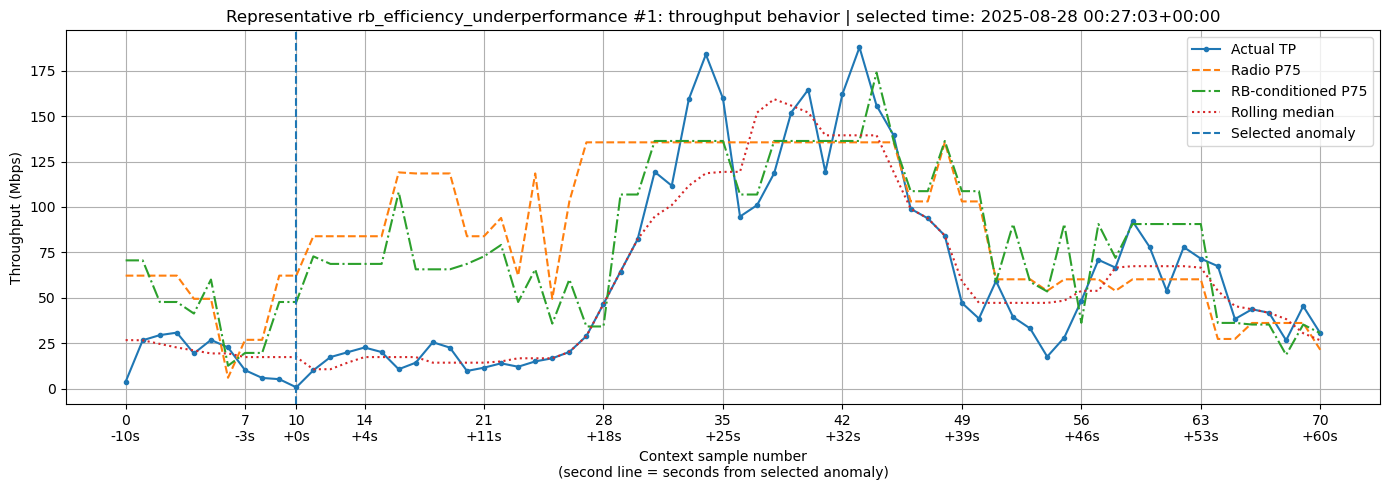

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_7_rb_efficiency_underperformance_rank_1_radio_context.png


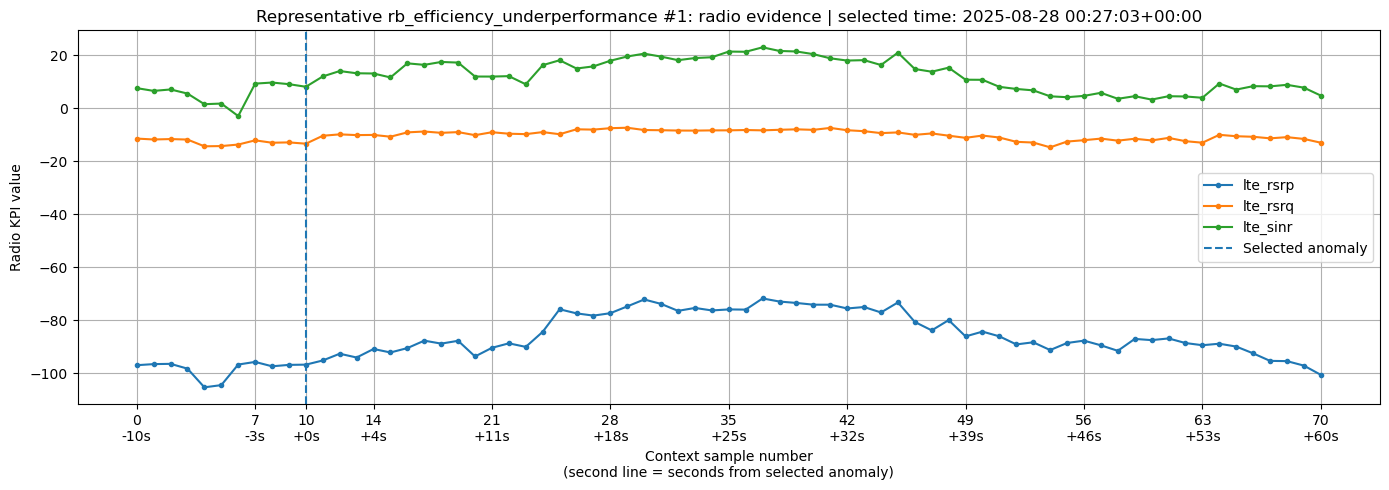


Representative anomaly type example: radio_p75_underperformance
Selected anomaly summary:


,timestamp,id,anomaly_type,anomaly_type_flags,anomaly_score_0_100,actual_lte_dl_throughput,expected_tp_p75,expected_tp_rb_conditioned_p75,throughput_ratio_p75,throughput_ratio_rb_p75,rb_usage_value,rb_usage_bucket,rb_demand_confidence,throughput_per_rb,lte_rsrp,lte_rsrq,lte_sinr,carrier_count,download_context_label,download_analysis_window_flag
0,2025-08-27 05:43:15+02:00,542020041221088+20250827155853+Fiji-Nadi-LTE-DL-D!20250827154409,radio_p75_underperformance,radio_limited_degradation;radio_p75_underperformance;rolling_local_drop,70.5,15.843544,62.203377,47.696416,0.254706,0.332175,142.0,medium_rb_usage,medium,0.111574,-98.355,-15.9575,0.478409,2.0,active_download_analysis_window,True


Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_8_radio_p75_underperformance_rank_1_throughput_context.png


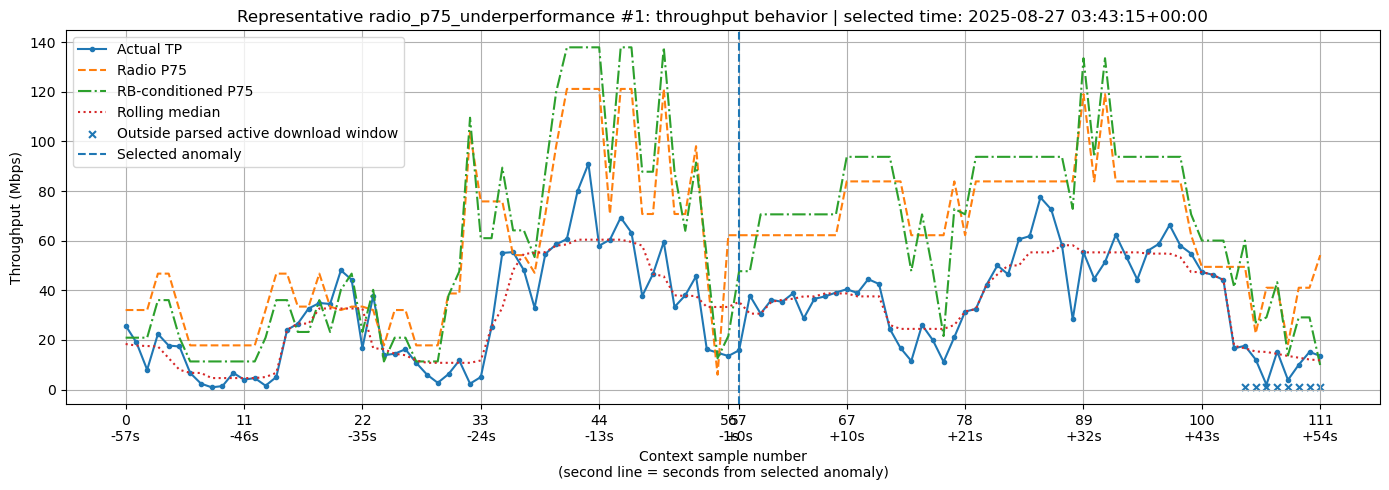

Saved plot: Throughput_Anomaly_Detection_Outputs\03_plots\19_type_example_context_8_radio_p75_underperformance_rank_1_radio_context.png


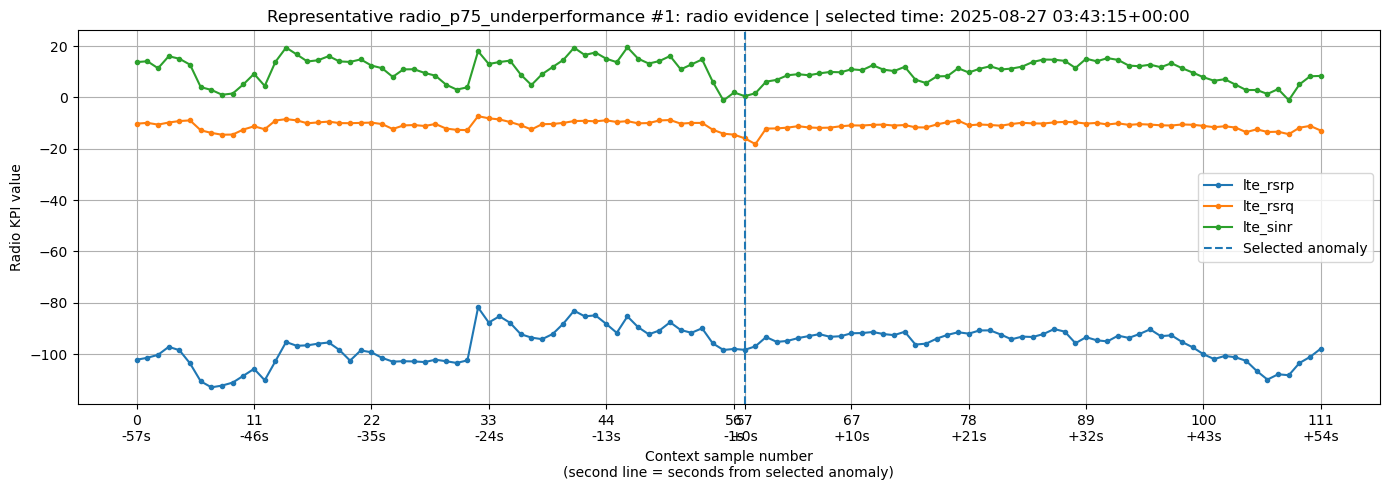

In [9]:
# =========================
# 16. Post-anomaly visual QC
# =========================

# These plots help confirm whether flagged samples look abnormal in their surrounding context.
# They also make it easier to explain why some method percentages are high or low.

if not lte_dl.empty:
    plot_distribution_with_lines(
        lte_dl,
        "anomaly_score_0_100",
        "Combined Statistical Anomaly Score Distribution",
        "Anomaly score (0-100)",
        thresholds={"Low": 15, "Medium": 35, "High": 60, "Critical": 80},
        bins=60,
        filename="10_anomaly_score_distribution.png",
        clip_upper_q=None,
    )



    # The full score distribution is usually dominated by normal zero-score rows. This zoom
    # shows only flagged anomalies so score calibration can be reviewed more clearly.
    plot_distribution_with_lines(
        lte_dl[lte_dl["is_throughput_anomaly"].fillna(False).astype(bool)],
        "anomaly_score_0_100",
        "Anomaly Score Distribution for Flagged Samples Only",
        "Anomaly score (0-100)",
        thresholds={"Medium": 35, "High": 60, "Critical": 80},
        bins=50,
        filename="10b_anomaly_score_distribution_flagged_only.png",
        clip_upper_q=None,
    )

    if "anomaly_method_count" in lte_dl.columns:
        method_count_summary = lte_dl["anomaly_method_count"].value_counts().sort_index()
        plt.figure(figsize=(8, 4))
        plt.bar(method_count_summary.index.astype(str), method_count_summary.values)
        plt.xlabel("Number of trigger flags active on the row")
        plt.ylabel("Rows")
        plt.title("Anomaly Trigger-Flag Overlap Distribution")
        save_current_plot("10c_anomaly_trigger_overlap_distribution.png")
        plt.show()

    if "method_summary" in globals():
        plot_flag_percentage_bars(method_summary, "11_anomaly_method_percentages.png")

    if "summary_by_type_sev" in globals() and not summary_by_type_sev.empty:
        type_counts = anomaly_handoff["anomaly_type"].value_counts().sort_values(ascending=True)
        plt.figure(figsize=(12, max(5, 0.35 * len(type_counts))))
        plt.barh(type_counts.index.astype(str), type_counts.values)
        plt.xlabel("Anomaly rows")
        plt.title("Anomaly Count by Primary Type")
        save_current_plot("12_anomaly_count_by_type.png")
        plt.show()

        sev_counts = anomaly_handoff["anomaly_severity"].value_counts().sort_values(ascending=True)
        plt.figure(figsize=(8, 4))
        plt.barh(sev_counts.index.astype(str), sev_counts.values)
        plt.xlabel("Anomaly rows")
        plt.title("Anomaly Count by Severity")
        save_current_plot("13_anomaly_count_by_severity.png")
        plt.show()

    plot_actual_vs_expected(lte_dl, "14_actual_vs_expected_with_anomalies.png")

    plot_distribution_with_lines(
        lte_dl,
        "throughput_ratio_p75",
        "Actual / Expected P75 Throughput Ratio",
        "Actual divided by expected P75",
        thresholds={"Underperformance ratio threshold": UNDERPERFORMANCE_RATIO_THRESHOLD, "Perfect match": 1.0},
        bins=80,
        filename="15_throughput_ratio_p75_distribution.png",
        clip_upper_q=0.99,
    )

    plot_distribution_with_lines(
        lte_dl,
        "throughput_gap_p75",
        "Expected P75 Minus Actual Throughput Gap",
        "Throughput gap (Mbps)",
        thresholds={"P75 gap threshold": UNDERPERFORMANCE_GAP_MBPS},
        bins=80,
        filename="16_throughput_gap_p75_distribution.png",
        clip_upper_q=0.99,
    )

    plot_route_metric(lte_dl, "anomaly_score_0_100", "Route Samples Colored by Anomaly Score", "17_route_by_anomaly_score.png", clip_upper_q=None)
    plot_route_anomaly_overlay(lte_dl, "17c_route_with_anomaly_overlay.png")

    if "download_analysis_window_flag" in lte_dl.columns:
        lte_dl["_download_analysis_window_numeric"] = lte_dl["download_analysis_window_flag"].fillna(True).astype(int)
        plot_route_metric(
            lte_dl,
            "_download_analysis_window_numeric",
            "Route Samples Colored by Active Download Analysis Window Flag",
            "17b_route_by_download_analysis_window.png",
        )

    if "anomaly_handoff" in globals() and not anomaly_handoff.empty:
        # Plot top anomaly EPISODES, not repeated neighboring rows from the same episode.
        # This directly fixes the visual issue where several top context windows showed the
        # same sustained low-throughput period instead of independent anomaly cases.
        if "anomaly_episode_id" in anomaly_handoff.columns:
            context_examples = (
                anomaly_handoff.sort_values("anomaly_score_0_100", ascending=False)
                .drop_duplicates("anomaly_episode_id", keep="first")
                .sort_values("anomaly_score_0_100", ascending=False)
                .reset_index(drop=True)
            )
        else:
            context_examples = anomaly_handoff.sort_values("anomaly_score_0_100", ascending=False).reset_index(drop=True)

        for rank in range(min(MAX_TOP_CONTEXT_WINDOWS, len(context_examples))):
            plot_anomaly_context(
                lte_dl,
                anomaly_df=context_examples,
                rank=rank,
                samples_before=ANOMALY_CONTEXT_SAMPLES_BEFORE,
                samples_after=ANOMALY_CONTEXT_SAMPLES_AFTER,
                filename_prefix="18_top_anomaly_episode_context",
            )

        # Add representative examples by anomaly type so review is not biased toward
        # only the highest-score edge cases.
        plot_context_examples_by_type(
            lte_dl,
            anomaly_handoff,
            max_types=MAX_CONTEXT_WINDOWS_BY_TYPE,
            samples_before=ANOMALY_CONTEXT_SAMPLES_BEFORE,
            samples_after=ANOMALY_CONTEXT_SAMPLES_AFTER,
            filename_prefix="19_type_example_context",
        )


In [10]:
# =========================
# 17. Final output index
# =========================

output_index = []
for path in sorted(OUTPUT_ROOT.rglob("*")):
    if path.is_file():
        output_index.append({
            "file": path.name,
            "folder": str(path.parent.relative_to(OUTPUT_ROOT)),
            "size": human_bytes(path.stat().st_size),
            "path": str(path),
        })
output_index_df = pd.DataFrame(output_index)
save_table(output_index_df, "output_index.csv", category="anomaly")
display(output_index_df)

print("Done. Broad candidate file:", ANOMALY_DIR / "lte_throughput_anomaly_candidates_all.csv")
print("Done. Main stricter RCA handoff file:", ANOMALY_DIR / "lte_throughput_anomalies_baseline.csv")
print("Preprocessing/cleaning outputs:", PREPROCESSING_DIR.resolve())
print("Anomaly-detection outputs:", ANOMALY_DIR.resolve())
print("Plots:", PLOTS_DIR.resolve())
print("No final RCA causes were assigned. Columns rca_status and rca_decision_placeholder are only placeholders for the next module.")


Saved CSV: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\output_index.csv  shape=(134, 4)


,file,folder,size,path
0,activity_table.csv,01_preprocessing_cleaning,235.32 KB,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\activity_table.csv
1,activity_type_summary.csv,01_preprocessing_cleaning,56.00 B,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\activity_type_summary.csv
2,canonical_column_mapping.csv,01_preprocessing_cleaning,1.62 KB,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\canonical_column_mapping.csv
3,cleaned_throughput_data_dictionary.csv,01_preprocessing_cleaning,57.26 KB,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\cleaned_throughput_data_dictionary.csv
4,cleaning_summary.csv,01_preprocessing_cleaning,180.00 B,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\cleaning_summary.csv
5,column_family_summary_after_cleaning.csv,01_preprocessing_cleaning,1.14 KB,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\column_family_summary_after_cleaning.csv
6,column_family_summary_before_cleaning.csv,01_preprocessing_cleaning,738.00 B,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\column_family_summary_before_cleaning.csv
7,download_activity_intervals_used.csv,01_preprocessing_cleaning,46.55 KB,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\download_activity_intervals_used.csv
8,download_activity_window_summary.csv,01_preprocessing_cleaning,176.00 B,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\download_activity_window_summary.csv
9,drive_clean_throughput_base.csv.gz,01_preprocessing_cleaning,13.21 MB,Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning\drive_clean_throughput_base.csv.gz


Done. Broad candidate file: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_throughput_anomaly_candidates_all.csv
Done. Main stricter RCA handoff file: Throughput_Anomaly_Detection_Outputs\02_anomaly_detection\lte_throughput_anomalies_baseline.csv
Preprocessing/cleaning outputs: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs\01_preprocessing_cleaning
Anomaly-detection outputs: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs\02_anomaly_detection
Plots: D:\ITI 9 Months\Graduation Project\Throughput_Anomaly_Detection_Outputs\03_plots
No final RCA causes were assigned. Columns rca_status and rca_decision_placeholder are only placeholders for the next module.


# Notebook 02 handoff notes

Main outputs:

- `lte_throughput_anomaly_candidates_all.csv`: broad statistical candidates.
- `lte_throughput_anomalies_baseline.csv`: stricter RCA-handoff subset.
- `throughput_anomaly_episode_summary.csv`: episode-level handoff for practical review.
- `lte_dl_anomaly_audit_table_post_scoring.parquet`: full post-scoring audit table.

No machine-learning model is trained here. The ML step should start from Notebook 01's clean pre-anomaly table and explicitly exclude target-derived, rolling, residual, P75, score, and anomaly-label columns.